# __Multi-domain Time Series Forecasting__

---

This notebook focuses on the understanding of time series data related to 2 different domains, and then to use the analysis to effectively model an accurate predictive system for each. The domains are:
1. Energy Forecasting
3. City-specific Daily Climate

---

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

## __1. Energy Forecasting__

---

### __A. Exploratory Data Analysis and Data Preprocessing__

---

In [135]:
# Loading the dataset
energy_df = pd.read_csv("/kaggle/input/energy-forecasting-data/TimeSeries_TotalSolarGen_and_Load_IT_2016.csv")
energy_df.head()

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0


In [136]:
# Printing the statistical summary of energy_df
energy_df.describe()

,IT_load_new,IT_solar_generation
count,8712.000000,8784.000000
mean,32262.212236,2049.831853
std,7288.629858,2845.846870
min,16716.000000,0.000000
25%,25909.500000,0.000000
50%,31654.500000,68.000000
75%,38685.750000,3923.500000
max,48986.000000,15824.000000


In [137]:
# Converting the timestamp column into datetime format
energy_df['utc_timestamp'] = pd.to_datetime(energy_df['utc_timestamp'])

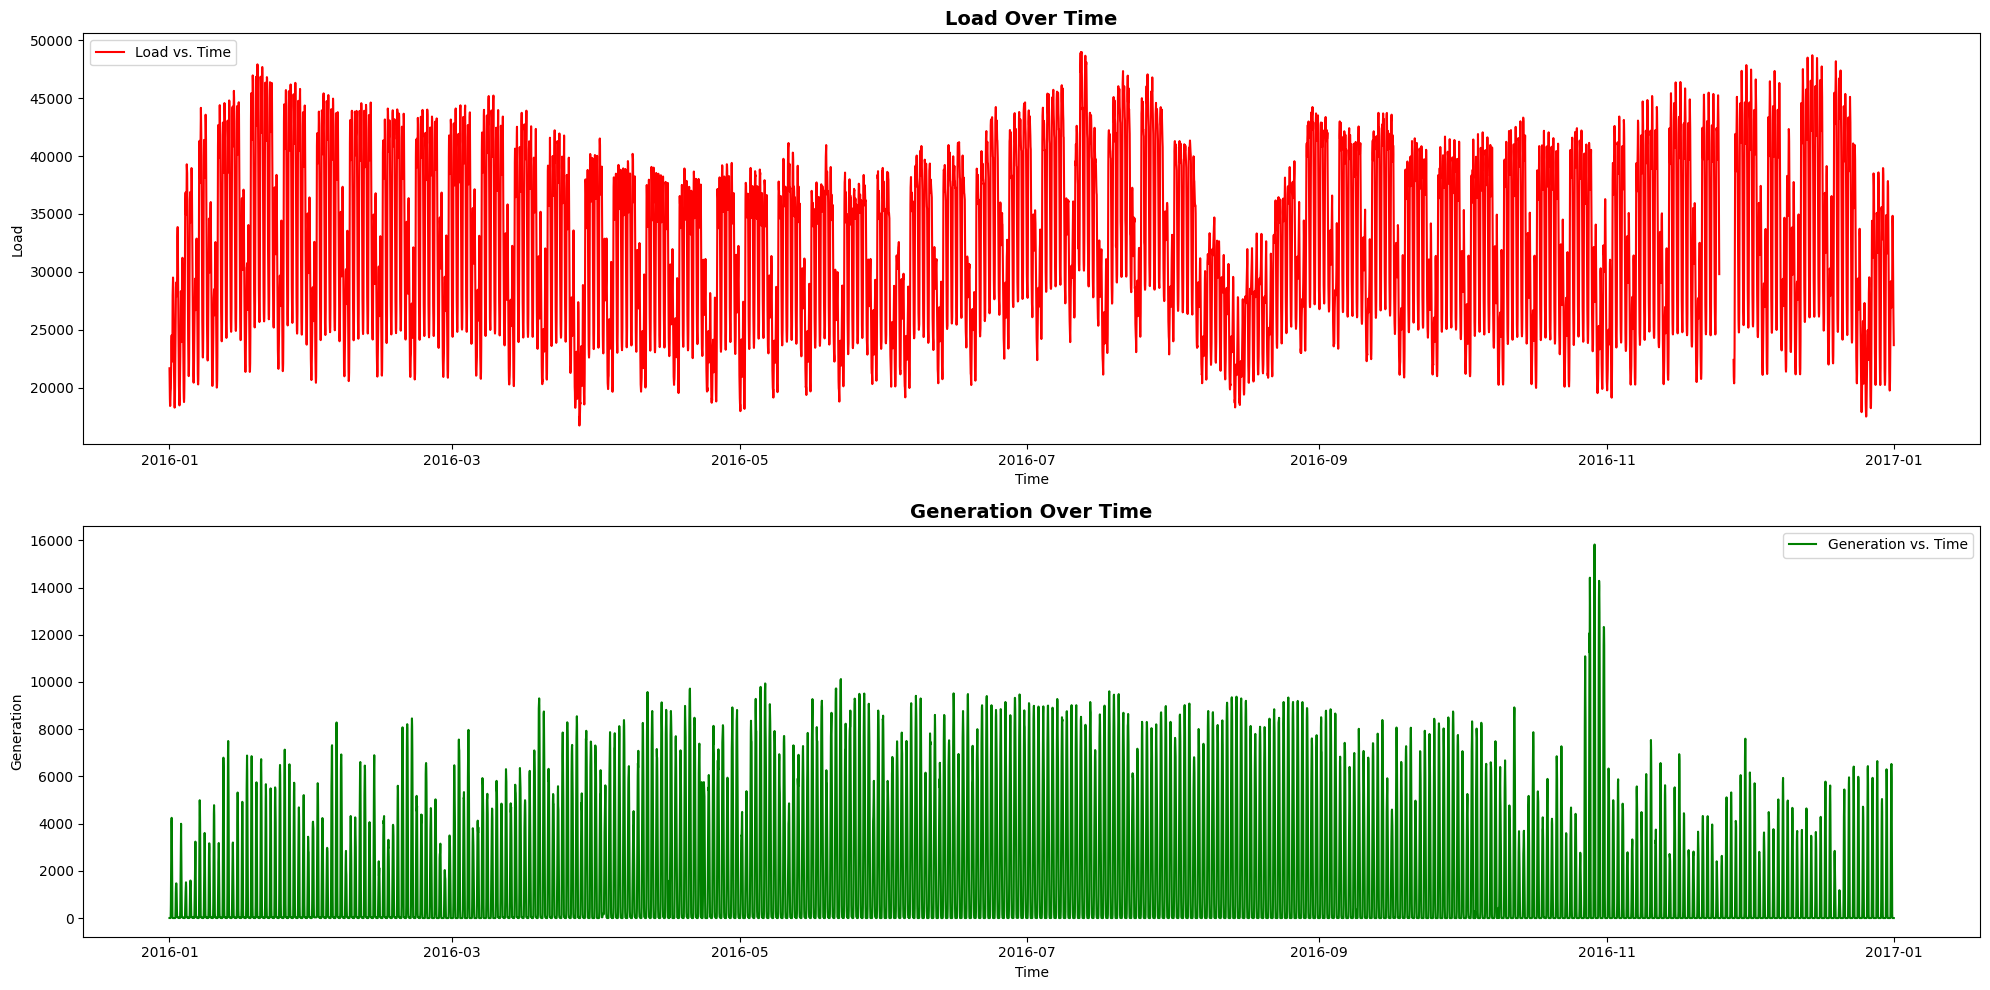

In [138]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))

ax[0].plot(energy_df['utc_timestamp'], energy_df['IT_load_new'], label="Load vs. Time", color='r')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Load')
ax[0].set_title('Load Over Time', fontsize=14, fontweight='bold')
ax[0].legend()

ax[1].plot(energy_df['utc_timestamp'], energy_df['IT_solar_generation'], label='Generation vs. Time', color='g')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Generation')
ax[1].set_title('Generation Over Time', fontsize=14, fontweight='bold')
ax[1].legend()

plt.tight_layout()
plt.show()

In [139]:
# Handling missing values
print(f"In 'utc_timestamp' - {energy_df['utc_timestamp'].isnull().sum()} null values.")
print(f"In 'IT_load_new' - {energy_df['IT_load_new'].isnull().sum()} null values.")
print(f"In 'IT_solar_generation' - {energy_df['IT_solar_generation'].isnull().sum()} null values.")

energy_df['IT_load_new'] = energy_df['IT_load_new'].ffill()
print(f"\nAfter handling, in 'IT_load_new' - {energy_df['IT_load_new'].isnull().sum()} null values.")

In 'utc_timestamp' - 0 null values.
In 'IT_load_new' - 72 null values.
In 'IT_solar_generation' - 0 null values.

After handling, in 'IT_load_new' - 0 null values.


---

The plot for load shows seasonality, with peaks and valleys occurring supposedly on a daily basis. This most likely follows from the fact that load reduces during the day and peaks around night. There's also a broader wave in the plot where the ampltitude shifts up and down over months, indicating another seasonality, possibly reflecting some other demand or economic cycle.

The plot of generation is mostly noisy, even though peaks and valleys occur at a supposed daily basis. The swings in amplitude aren't regular and seem to be random instead. However, there's a spike around the end of October which can suggest some seasonality over a longer interval. More tests would be required to ascertain this.

Before performing any analysis or forecasting, it has to be ensured that the series are stationary, i. e., their statistical properties are consistent over time and independent of any seasonal components. Stationarity leads to easier modelling and proper forecasting, and it can be tested using the Dickey-Fuller test. The null hypothesis of the test is that the series is non-stationary when the p-value is greater than 0.05, and the alternate hypothesis is that the series is stationary when the p-value is less than or equal to 0.05.

---

In [140]:
def adf_test(series: pd.Series):
    """
    Tests the stationarity of a time series, plots the rolling mean and standard deviation.

    Args:
        series (pd.Series): Time series to check for stationarity.
    """
    adf_results = adfuller(series, autolag='AIC')
    adf_output = pd.Series(adf_results[0:4], index=['test_statistic', 'p_value', '#_lags_used', '#_obsvs_used'])

    for key, value in adf_results[4].items():
        adf_output[f'critical_value_{key}'] = value

    plt.figure(figsize=(15, 10))
    plt.plot(series, color='green', label='Original Series')
    plt.plot(series.rolling(52).mean(), color='yellow', label='Rolling Mean')
    plt.plot(series.rolling(52).std(), color='red', label = 'Rolling Standard Deviation')
    plt.legend(loc='best')
    plt.title("Rolling Mean and Standard Deviation")
    
    plt.tight_layout()
    plt.show()

    print('\nResults:')
    print('-'*40)
    print(adf_output)
    print("\n", "="*80, "\n")

Augmented Dickey-Fuller test on 'IT_load_new':



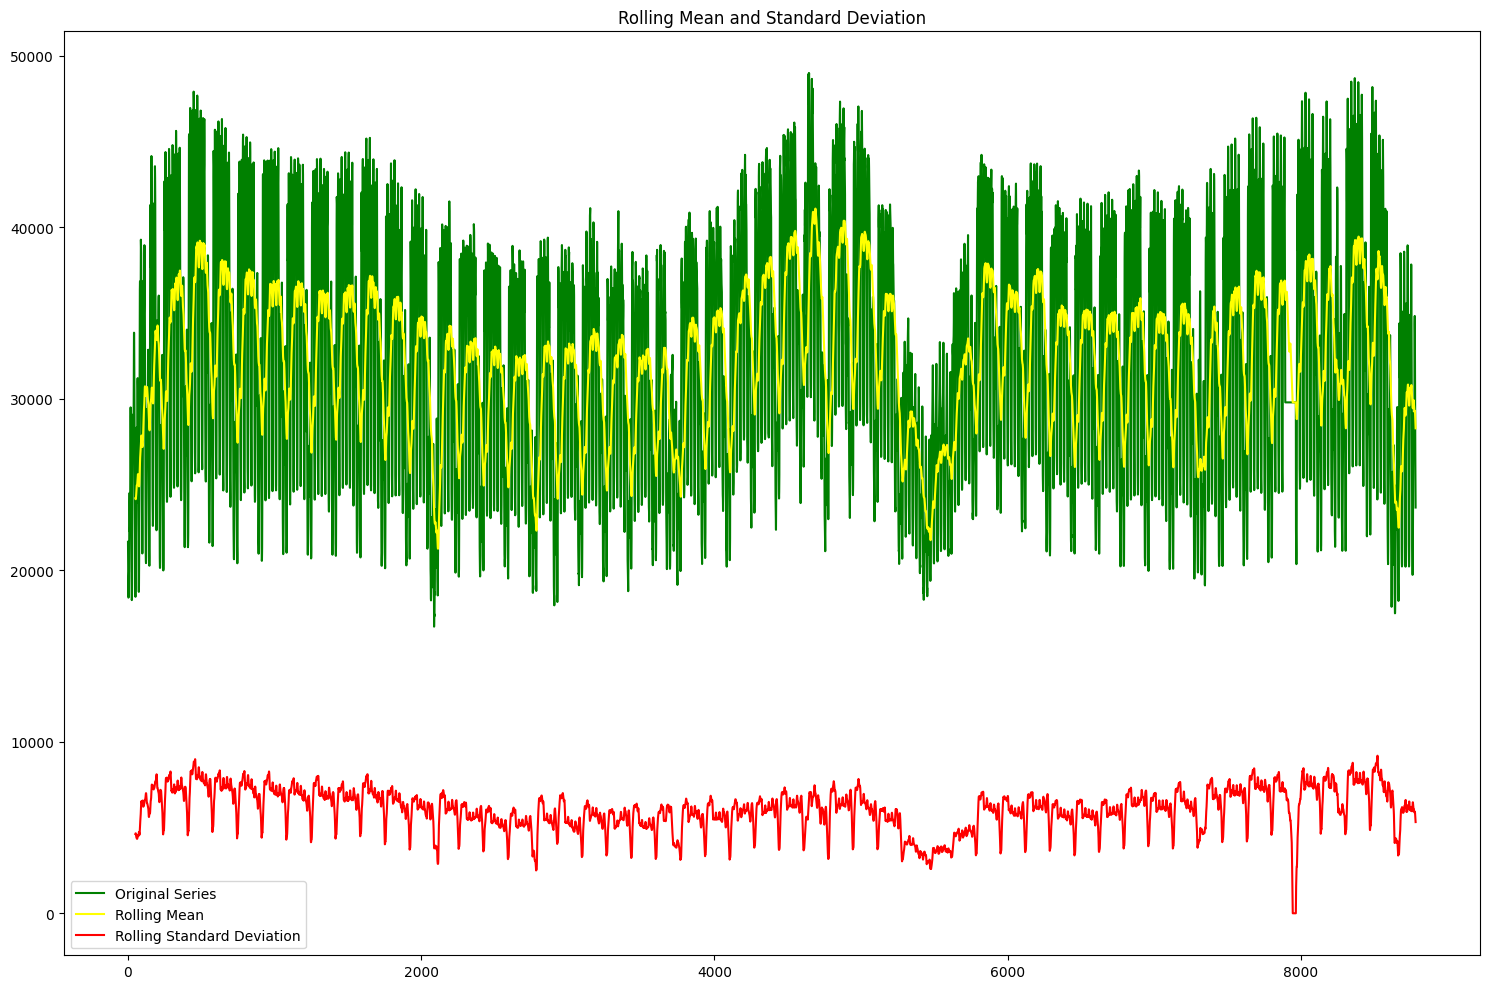


Results:
----------------------------------------
test_statistic       -1.197390e+01
p_value               3.841445e-22
#_lags_used           3.700000e+01
#_obsvs_used          8.746000e+03
critical_value_1%    -3.431098e+00
critical_value_5%    -2.861871e+00
critical_value_10%   -2.566946e+00
dtype: float64



Augmented Dickey-Fuller test on 'IT_solar_generation':



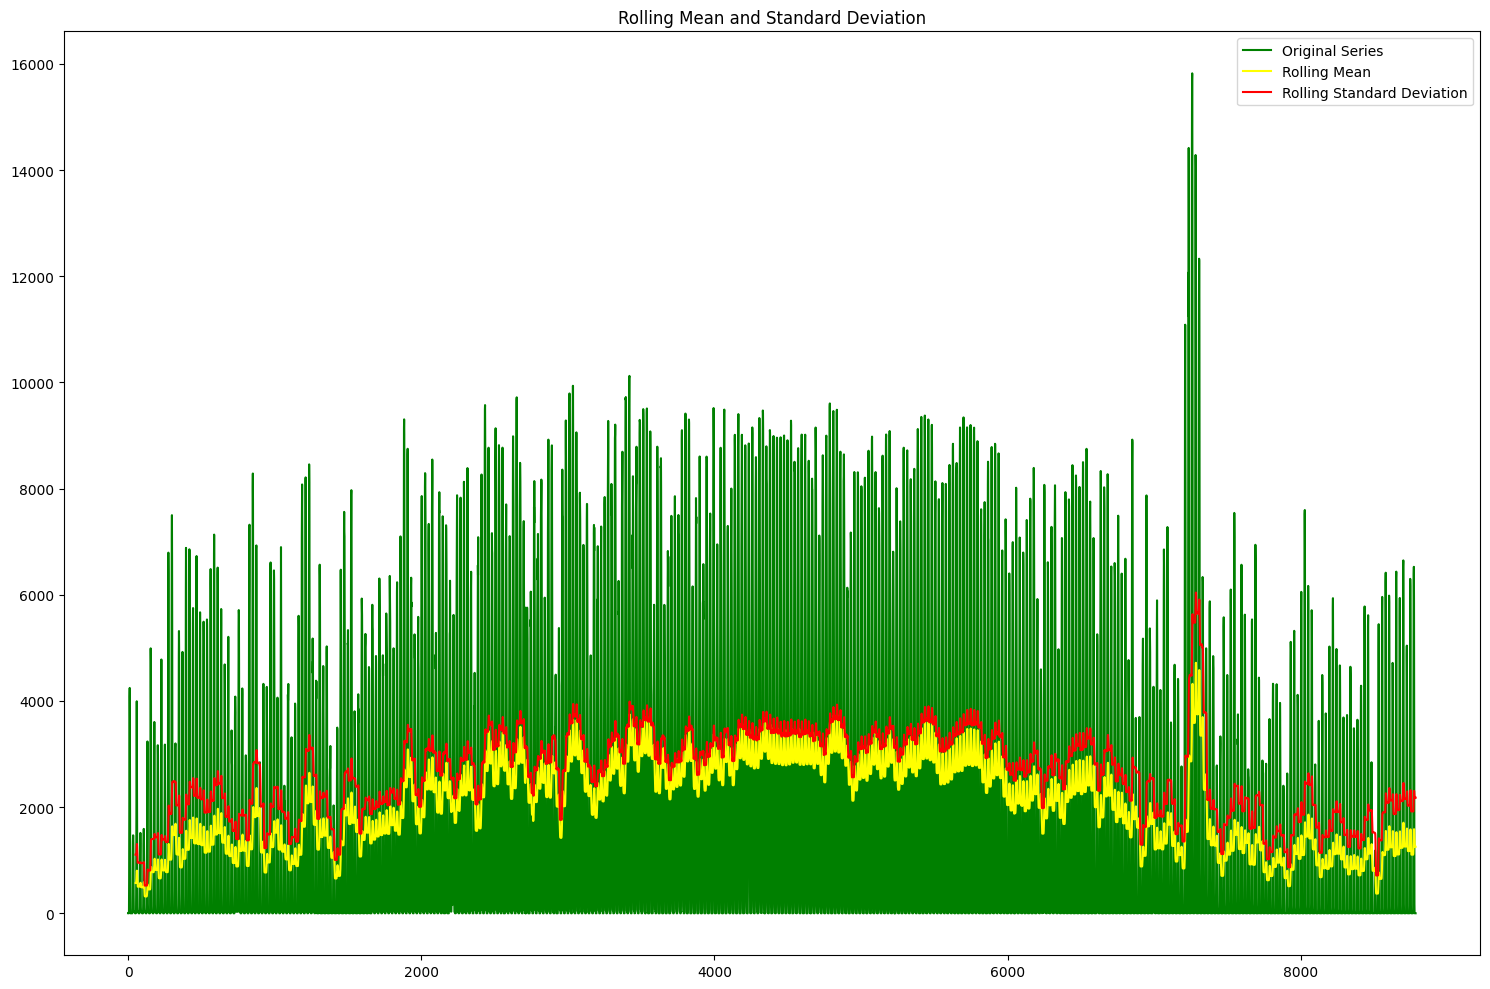


Results:
----------------------------------------
test_statistic       -5.741335e+00
p_value               6.265438e-07
#_lags_used           3.600000e+01
#_obsvs_used          8.747000e+03
critical_value_1%    -3.431098e+00
critical_value_5%    -2.861870e+00
critical_value_10%   -2.566946e+00
dtype: float64




In [141]:
print("Augmented Dickey-Fuller test on 'IT_load_new':\n")
adf_test(energy_df['IT_load_new'])

print("\nAugmented Dickey-Fuller test on 'IT_solar_generation':\n")
adf_test(energy_df['IT_solar_generation'])

---

For both `IT_load_new` and `IT_solar_generation`, the test statistic is negative and the p-value is far smaller than 0.05. Thus, the null hypothesis of the series being non-stationary is strongly rejected, implying that both the series are stationary. Now, a predictive system can be built for each of them using multiple algorithms.

---

In [142]:
def iqr_outliers(series: pd.Series):
    """
    Prints the inter-quartile range
    for a numeric series and a count
    of outliers, if any.

    Args:
        series: pandas Series
    """
    s = pd.to_numeric(series, errors='coerce').dropna()
    s_stats = s.describe()
    q1, q3 = s_stats.loc['25%'], s_stats.loc['75%']
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = s[(s < lower) | (s > upper)]

    print('='*50)
    print(f'First quartile: {q1}')
    print(f'Third quartile: {q3}')
    print(f'Interquartile range: {iqr}')
    print(f'Lower bound: {lower}')
    print(f'Upper bound: {upper}')
    print(f'Outlier count: {len(outliers)}')    
    print('='*50, '\n')

def generate_boxplot(series: pd.Series, name: str):
    """
    Generates a boxplot for
    a numeric series.

    Args:
        series: pandas Series
        name: name of the series
    """
    s = pd.to_numeric(series, errors='coerce').dropna()
    plt.figure(figsize=(10, 5))
    plt.boxplot([s], labels=[name])
    plt.title(f'Box-plot for {name}', fontsize=14, fontweight='bold')
    plt.ylabel('Values', fontsize=12, fontweight='bold')
    plt.savefig(f'{name}_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print('='*80, '\n')

Interquartile range, outlier count, and boxplot for IT_load_new:
First quartile: 25944.5
Third quartile: 38637.25
Interquartile range: 12692.75
Lower bound: 6905.375
Upper bound: 57676.375
Outlier count: 0



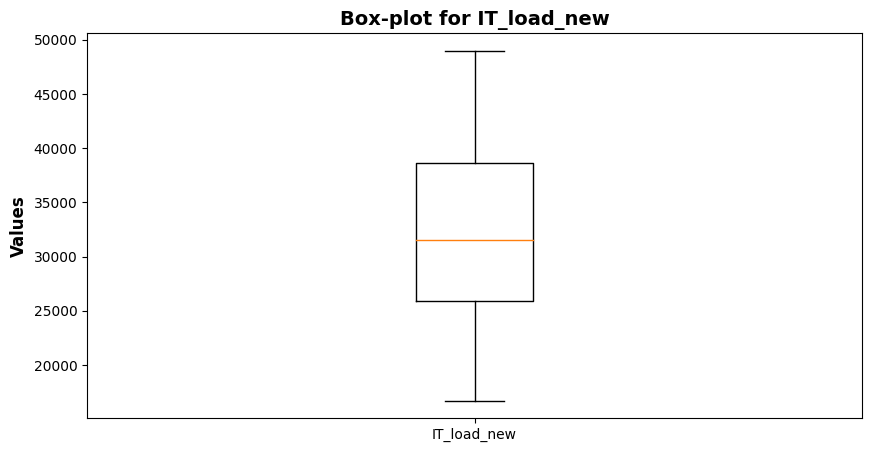


Interquartile range, outlier count, and boxplot for IT_solar_generation:
First quartile: 0.0
Third quartile: 3923.5
Interquartile range: 3923.5
Lower bound: -5885.25
Upper bound: 9808.75
Outlier count: 29



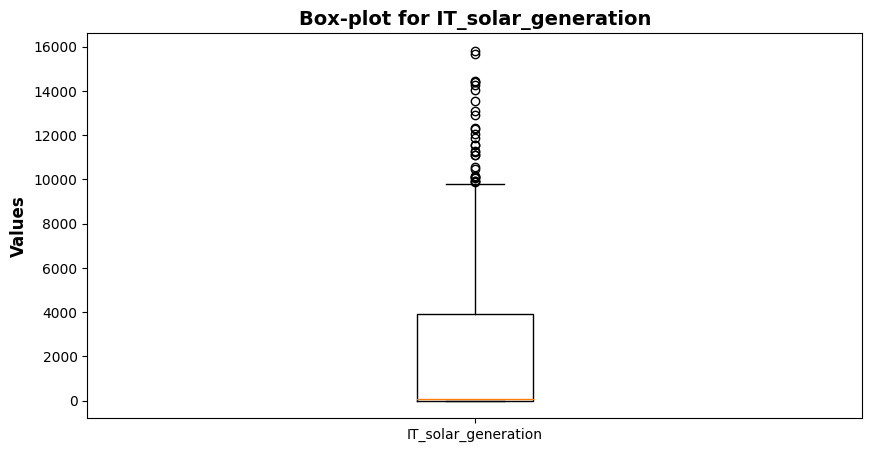

In [143]:
print('Interquartile range, outlier count, and boxplot for IT_load_new:')
iqr_outliers(energy_df['IT_load_new'])
generate_boxplot(energy_df['IT_load_new'], 'IT_load_new')

print('Interquartile range, outlier count, and boxplot for IT_solar_generation:')
iqr_outliers(energy_df['IT_solar_generation'])
generate_boxplot(energy_df['IT_solar_generation'], 'IT_solar_generation')

---

For `IT_load_new`:
1. The boxplot shows a central spread with no extreme values flagged by the IQR rule.
2. This suggests that the load series is relatively stable around its range, with no outliers under the standard `1.5*IQR` criterion.

For `IT_solar_generation`:
1. The boxplot shows a large concentration of values near zero and a longer upper spread.
2. 29 outliers have been flagged under the standard `1.5*IQR` criterion above the upper whisker.
3. This is consistent with the fact that solar generation is influenced by partial-shading conditions, night time, and daytime spikes.

---

In [144]:
import seaborn as sns
from scipy.stats import norm

# Boxplots isolate outliers, this function reveals the underlying
# probability distributions, skewness, and modality of each feature
def plot_with_normal_fit(series: pd.Series, name: str):
    """
    Plots histogram with a kernel
    density estimate for a numeric
    series and overlays a fitted
    Gaussian curve for comparison.

    Args:
        series: pandas Series
        name: name of the Series
    """
    s = pd.to_numeric(series, errors='coerce').dropna()
    s_stats = s.describe()
    mu = s_stats.loc['mean']
    sigma = s_stats.loc['std']
    
    plt.figure(figsize=(8, 5))
    ax = sns.histplot(
        s, kde=True, stat='density',
        bins=40, color='skyblue',
        label='Data Proportion %age\n(Bar Height * Width)'
    )

    x = np.linspace(s.min(), s.max(), 500)
    plt.plot(x, norm.pdf(x, mu, sigma), color='red', label='Normal Fit')

    plt.title(f'{name} Histogram with Gaussian fit', fontweight='bold', fontsize=14)
    plt.xlabel('Value', fontweight='bold', fontsize=12)
    plt.ylabel('Density', fontweight='bold', fontsize=12)
    plt.legend()
    plt.savefig(f'{name}_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()

    # densities = [patch.get_height() for patch in ax.patches]
    # bin_starts = [patch.get_x() for patch in ax.patches]
    # bin_width = ax.patches[0].get_width()

    # print('\nHistogram details:')
    # print('-'*40)
    # print(f'Densities: {densities}')
    # print(f'Bin starting points: {bin_starts}')
    # print(f'Bin width: {bin_width}')
    print('='*80, '\n')

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


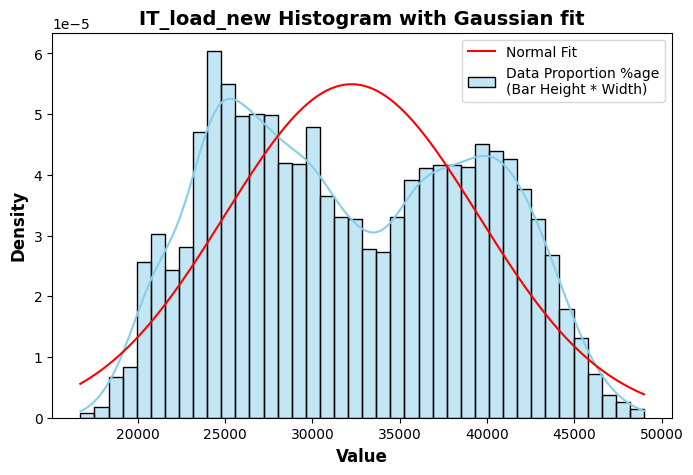

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


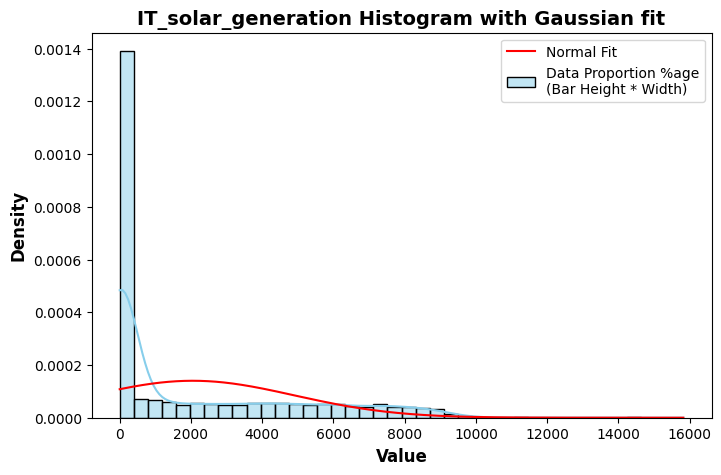

In [145]:
plot_with_normal_fit(energy_df['IT_load_new'], 'IT_load_new')

plot_with_normal_fit(energy_df['IT_solar_generation'], 'IT_solar_generation')

---

For `IT_load_new`:
1. The histogram shows a broad, fairly smooth distribution centered around its range.
2. The empirical distribution is not perfectly normal when compared to the Gaussian overlay.

For `IT_solar_generation`:
1. The histogram shows a high concentration of low values around 0 with a long and thin right tail.
2. Like `IT_load_new`, the empirical distribution is clearly non-normal as the Gaussian overlay fits poorly but it is strongly skewed.

---

Overall, `IT_load_new` appears more balanced with no IQR-defined outliers whereas `IT_solar_generation` is heavily right-skewed, concentrated near 0, and has a small number of high values. This should be kept in mind during preprocessing and modeling.

---

### __B. Fitting ARIMA__

---

ARIMA (AutoRegressive Integrated Moving Average) requires 3 arguments:
1. _a_ or _p_ - the number of autoregressive terms.
2. _d_ - the number of differences.
3. _m_ or _q_ - the number of moving average terms.

Differencing is done to make the series stationary. Since both our series are stationary differencing won't be required, making _d_ equals 0. To determine the optimal values of _a_ and _m_, we need to look at the auto-correlation function and partial auto-correlation function plots.

Previously we noted that `IT_solar_generation` is strongly right-skewed, which is consistent with the nature of solar output. Thus, the non-normal nature of the solar output isn't automatically a problem, so no transformation is applied on the scale of the distribution of `IT_solar_generation` at this stage, and it's used as it originally is for model fitting.

ARIMA/SARIMA primarily relies on:
1. Differencing.
2. Seasonality.
3. Residual diagnostics.

Residual diagnostics primarily include 3 statistical tests:
1. **Ljung-Box Test**: Checks if the residuals are independent and behave like white noise.
    - _Null Hypothesis_: The residuals are independently distributed (no autocorrelation / they are white noise).
    - _Passing criterion_: **High p-value (>= 0.05).** This means that the null hypothesis is accepted, proving that the fitted model successfully extracted all the patterns.
    - _Necessity_: **Critical.**

2. **Heteroscedasticity Test**: Checks if the variance of the residuals remains constant over time (homoscedasticity).
    - _Null Hypothesis_: The residuals show homoscedasticity (constant variance over time).
    - _Passing criterion_: **High p-value (>= 0.05).** This means that the null hypothesis is accepted, proving the error size is stable and confidence intervals are trustworthy.
    - _Necessity_: **High.**

3. **Jarque-Bera Test**: Checks if the residuals follow a normal distribution by testing skewness and kurtosis.
    - _Null Hypothesis_: The residuals are normally distributed (skewness is 0, kurtosis is 3).
    - _Passing criterion_: **High p-value (>= 0.05).** This means that the null hypothesis is accepted. If it fails (low p-value), the residuals are skewed or have fat tails, usually caused by sudden spikes or outliers in your data.
    - _Necessity_: **Low.**

---

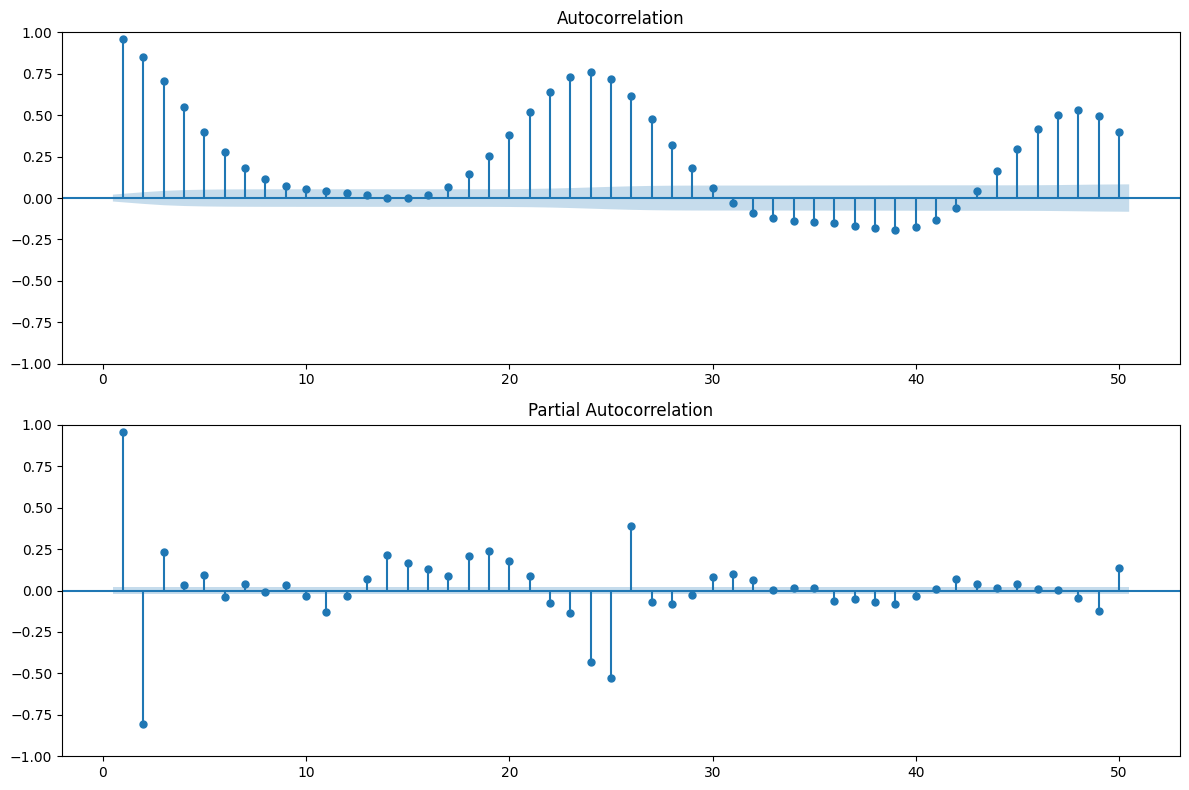

In [146]:
# For IT_load_new

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

plot_acf(energy_df['IT_load_new'], lags=50, zero=False, ax=ax[0])
plot_pacf(energy_df['IT_load_new'], lags=50, zero=False, ax=ax[1])
plt.tight_layout()

plt.show()

---

From the ACF plot, we can observe a gradual decay which reflects lingering influence of the lags instead of a direct one. This is characteristic of a pure AR process where MA is not primary. __Thus, _m_ or _q_ is 0.__

From the PACF plot, we can observe a sharp descent after 2 lags, which means that the series is well described by an AR model of order 2. __Thus, _a_ or _p_ is 2.__

Now that we have all the 3 parameters for an ARIMA model appropriate for our time series, we can proceed to building one.

---

In [147]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Splitting the series into training and test sets in 80/20 ratio
load_training_size = int(len(energy_df['IT_load_new'])*0.8)
load_training_set, load_test_set = energy_df['IT_load_new'][:load_training_size], energy_df['IT_load_new'][load_training_size:]

# Fit an ARIMA model
load_arima_1 = ARIMA(load_training_set, order=(2, 0, 0))
load_arima_1_results = load_arima_1.fit()

# Display the fitting summary
print(load_arima_1_results.summary())

                               SARIMAX Results                                
Dep. Variable:            IT_load_new   No. Observations:                 7027
Model:                 ARIMA(2, 0, 0)   Log Likelihood              -59891.529
Date:                Sat, 15 Aug 2026   AIC                         119791.057
Time:                        02:09:42   BIC                         119818.488
Sample:                             0   HQIC                        119800.508
                               - 7027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.214e+04    223.761    143.644      0.000    3.17e+04    3.26e+04
ar.L1          1.7277      0.008    220.205      0.000       1.712       1.743
ar.L2         -0.8029      0.007   -113.596      0.0

In [148]:
# Make predictions on the test set
load_preds_arima_1 = load_arima_1_results.predict(start=len(load_training_set), end=len(load_training_set)+len(load_test_set)-1)

# Calculate RMSE error
load_rmse_arima_1 = np.sqrt(mean_squared_error(load_test_set, load_preds_arima_1))
print(f"\nThe RMSE of the AR model for IT_load_gen is: {load_rmse_arima_1:.2f}.")


The RMSE of the AR model for IT_load_gen is: 7712.04.


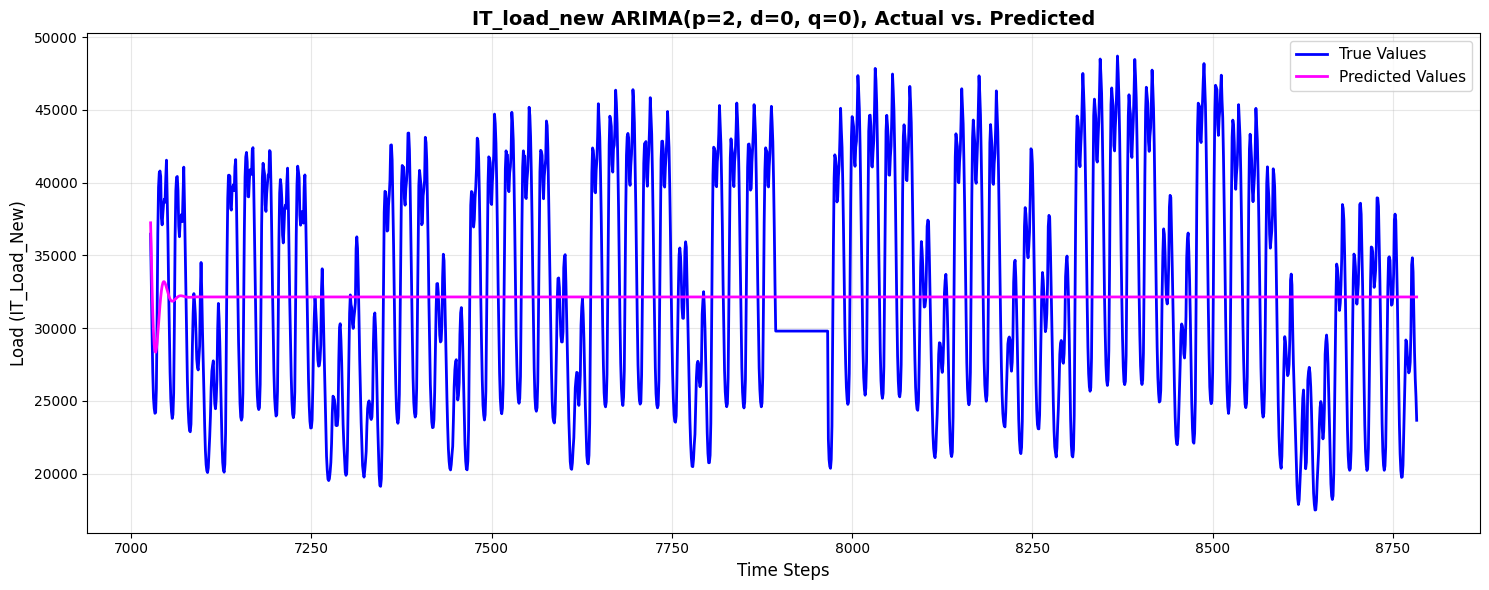

In [149]:
# Plotting the predictions against the true values
plt.figure(figsize=(15, 6))
plt.plot(load_test_set.index, load_test_set.values, label="True Values", linewidth=2, color="blue")
plt.plot(load_preds_arima_1.index, load_preds_arima_1.values, label="Predicted Values", linewidth=2, color="magenta")
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Load (IT_Load_New)", fontsize=12)
plt.title("IT_load_new ARIMA(p=2, d=0, q=0), Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

Following observations can be made from the summary of `load_arima_1`:
1. `const`, `ar.L1`, `ar.L2`, and `sigma2` are all significant since their respective p-values are all 0.000.
2. For LB test, the p-value is 0.000, implying that _the residuals still contains patterns that the model didn't capture._
3. For JB test, the p-value is 0.000, implying that _the residuals aren't normally distributed._ ARIMA assumes residuals are normally distributed.
4. For Heteroscedasticity, the p-value is 0.000, implying that _the variance is not constant over time_. ARIMA assumes constant error variance.

Both of the lag coefficients are significant but this model isn't capturing all the patterns in the data as evident from the diagnostic tests. More complex ARIMA combinations would be needed to better fit the series.

---

In [150]:
# Fitting a second ARIMA model
load_arima_2 = ARIMA(load_training_set, order=(4, 0, 0))
load_arima_2_results = load_arima_2.fit()

# Display the fitting summary
print(load_arima_2_results.summary())

                               SARIMAX Results                                
Dep. Variable:            IT_load_new   No. Observations:                 7027
Model:                 ARIMA(4, 0, 0)   Log Likelihood              -59663.150
Date:                Sat, 15 Aug 2026   AIC                         119338.300
Time:                        02:09:44   BIC                         119379.445
Sample:                             0   HQIC                        119352.475
                               - 7027                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.214e+04    287.078    111.962      0.000    3.16e+04    3.27e+04
ar.L1          1.9261      0.011    177.048      0.000       1.905       1.947
ar.L2         -1.2217      0.023    -53.728      0.0

In [151]:
# Make predictions on the test set
load_preds_arima_2 = load_arima_2_results.predict(start=len(load_training_set), end=len(load_training_set)+len(load_test_set)-1)

# Calculate RMSE error
load_rmse_arima_2 = np.sqrt(mean_squared_error(load_test_set, load_preds_arima_2))
print("\n", "*"*20, f"\nThe RMSE of the 2nd AR model for IT_load_gen is: {load_rmse_arima_2:.2f}.")


 ******************** 
The RMSE of the 2nd AR model for IT_load_gen is: 7715.45.


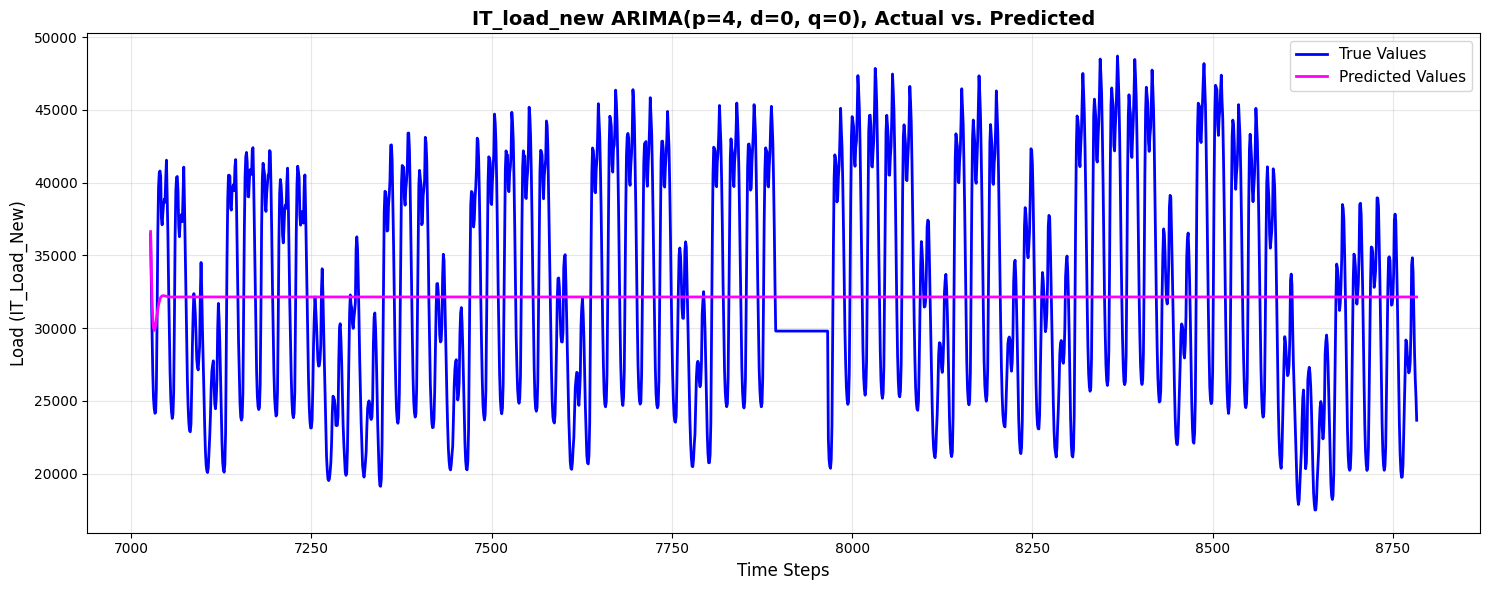

In [152]:
# Plotting the predictions against the true values
plt.figure(figsize=(15, 6))
plt.plot(load_test_set.index, load_test_set.values, label="True Values", linewidth=2, color="blue")
plt.plot(load_preds_arima_2.index, load_preds_arima_2.values, label="Predicted Values", linewidth=2, color="magenta")
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Load (IT_Load_New)", fontsize=12)
plt.title("IT_load_new ARIMA(p=4, d=0, q=0), Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

Following observations can be made from the summary of `load_arima_2`:
1. `const`, `ar.L1`, `ar.L2`, `ar.L3` and `sigma2` are also all significant since their respective p-values are all 0.000. However, `ar.L4` is insignificant as it's much larger than 0.05 (0.427).
2. For LB test, the p-value is 0.94, implying that _the model has captured majority of the patterns in the data._
3. For JB test, the p-value is 0.000, implying that _the residuals aren't normally distributed._ ARIMA assumes residuals are normally distributed.
4. For Heteroscedasticity, the p-value is 0.000, implying that _the variance is not constant over time_. ARIMA assumes constant error variance.
5. The AIC value for `load_arima_2` (119338.3) is lower than that of `load_arima_1` (119761.057), but the RMSE of former (7715.45) is slightly greater than than the latter (7712.04).


Therefore, the following conclusions can be made for `load_arima_2`:
1. Since the 4th order coefficient is insignificant, we can stop at ARIMA(3, 0, 0).
2. AIC decreased while RMSE increased whereas ideally both should improve. This divergence suggests overfitting i. e., the model is generalizing well on the training set but is too complex for the test set.
3. From the plot of predictions vs. true values, it's evident that the model is reverting to the series mean. This is because ARIMA is a linear model that can't capture cyclicity and our series has strong cyclicity.
4. Adding more lags won't help ARIMA to better fit the series as it fails to capture the cyclicity. Experimenting with MA terms won't help either since the ACF plot made it clear that the series is purely AR.
5. Since the series for `IT_solar_generation` also has strong cyclicity, trying to fit an ARIMA model on it won't be useful either.

---

### __C. Fitting SARIMA__

---

Seasonal ARIMA (or simply SARIMA) explicitly models seasonality with __a separate seasonal component along with the non-seasonal components (p, d, and q)__, and can provide a much better fit. Observing the ACF and PACF plots at the seasonal period __'s'__ (which is 24 here) similar to how we did previously for ARIMA, would give us __the seasonal terms P, D, and Q.__

---

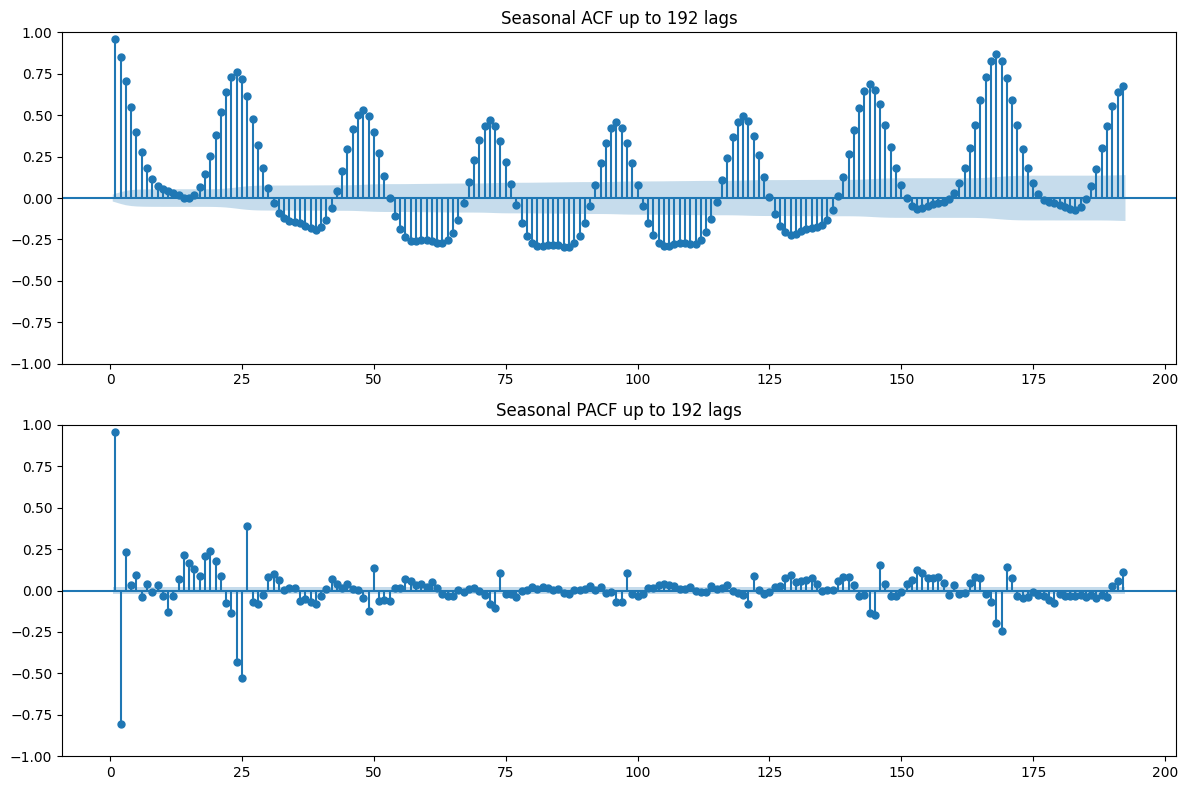

In [153]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

seasonal_period = 24

plot_acf(energy_df['IT_load_new'], lags=seasonal_period*8, zero=False, ax=ax[0])
ax[0].set_title(f"Seasonal ACF up to {seasonal_period*8} lags")

plot_pacf(energy_df['IT_load_new'], lags=seasonal_period*8, zero=False, ax=ax[1])
ax[1].set_title(f"Seasonal PACF up to {seasonal_period*8} lags")

plt.tight_layout()

plt.show()

---

From the plots above we can observe that:
1. In the ACF plot, there are clear peaks at lags occuring every 24 hours which implies a strong autocorrelation every 24 hours. This indicates that the _value at each hour is highly correlated with the same hour the previous day, the day before that, and so on._
2. In the PACF plot, the first big spike is at lag 24 and the spikes after this are significantly smaller.

Therefore the following conclusions can be made:
1. P = 1 as the PACF plot shows a sharp drop after lag 24 (the first cycle).
2. Q = 1 as the ACF plot repeats the pattern at every 24 lags (a single cycle).
3. D = 0 as the series is stationary (confirmed by the ADF test done previously).
4. The non-seasonal terms (p, d, and q) calculated in ARIMA modelling can be carried forward.

---

In [154]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fitting a SARIMA model
load_sarima_1 = SARIMAX(load_training_set, order=(2, 0, 0), seasonal_order=(1, 0, 1, 24))
load_sarima_1_results = load_sarima_1.fit()

# Displaying the fitting summary
print(load_sarima_1_results.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                      SARIMAX Results                                       
Dep. Variable:                          IT_load_new   No. Observations:                 7027
Model:             SARIMAX(2, 0, 0)x(1, 0, [1], 24)   Log Likelihood              -55431.929
Date:                              Sat, 15 Aug 2026   AIC                         110873.858
Time:                                      02:10:13   BIC                         110908.146
Sample:                                           0   HQIC                        110885.671
                                             - 7027                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5963      0.006    273.451      0.000       1.585       1.608
ar.L2         -0.61

In [155]:
# Make predictions on the test set
load_preds_sarima_1 = load_sarima_1_results.predict(start=len(load_training_set), end=len(load_training_set)+len(load_test_set)-1)

# Calculate RMSE error
load_rmse_sarima_1 = np.sqrt(mean_squared_error(load_test_set, load_preds_sarima_1))
print(f"\nThe RMSE of the SARIMA model for IT_load_new is: {load_rmse_sarima_1:.2f}.")


The RMSE of the SARIMA model for IT_load_new is: 8127.67.


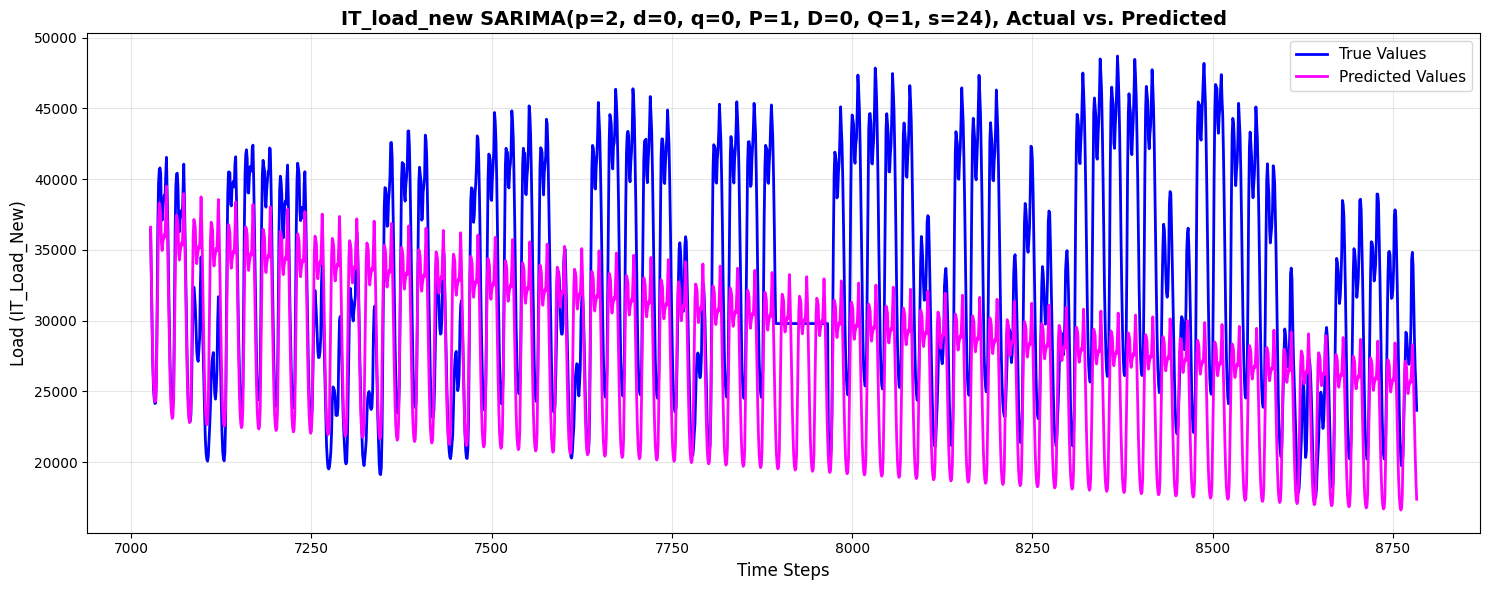

In [156]:
# Plotting the predictions against the true values
plt.figure(figsize=(15, 6))
plt.plot(load_test_set.index, load_test_set.values, label="True Values", linewidth=2, color="blue")
plt.plot(load_preds_sarima_1.index, load_preds_sarima_1.values, label="Predicted Values", linewidth=2, color="magenta")
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Load (IT_Load_New)", fontsize=12)
plt.title("IT_load_new SARIMA(p=2, d=0, q=0, P=1, D=0, Q=1, s=24), Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

From the summary above, the following observations can be made about `load_sarima_1` model:
1. All the AR and MA (both seasonal and non-seasonal) terms are significant as the p-value is 0.000 for each of them.
2. LB test failed as the p-value is 0.00, indicating that _the model couldn't capture all the patterns in the data._
3. JB test failed as the p-value is 0.00, indicating that _the residuals aren't normally distributed._
4. Test for heteroscedasticity failed, as p-value is 0.00, indicating that _residual variance is not constant._
5. Even though the AIC value of `load_sarima_1` (110873.925) is much lower than that of `load_arima_2` (119338.3), the RMSE of `load_sarima_1` (8029.21) is much higher than that of `load_arima_1` (7715.45).
6. From the plot of predictions vs. true values, it can be inferred that SARIMA has effectively captured the 24 hour cyclicity in the data, which ARIMA could't. However, the SARIMA predictions are gradually trending downwards i. e., becoming _non-stationary_.

So, next we have to implement seasonal differencing to stabilize the predictions even if the ADF test implied that the series is stationary overall in the bedginning. To do this __'D'__ has to be set to 1.

---

In [157]:
# Fitting another SARIMA model, this time with seasonal differencing
load_sarima_2 = SARIMAX(load_training_set, order=(2, 0, 0), seasonal_order=(1, 1, 1, 24))
load_sarima_2_results = load_sarima_2.fit()

# Displaying the fitting summary
print(load_sarima_2_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                          IT_load_new   No. Observations:                 7027
Model:             SARIMAX(2, 0, 0)x(1, 1, [1], 24)   Log Likelihood              -55272.457
Date:                              Sat, 15 Aug 2026   AIC                         110554.914
Time:                                      02:10:56   BIC                         110589.185
Sample:                                           0   HQIC                        110566.723
                                             - 7027                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5890      0.004    365.500      0.000       1.580       1.597
ar.L2         -0.61

In [158]:
# Make predictions on the test set
load_preds_sarima_2 = load_sarima_2_results.predict(start=len(load_training_set), end=len(load_training_set)+len(load_test_set)-1)

# Calculate RMSE error
load_rmse_sarima_2 = np.sqrt(mean_squared_error(load_test_set, load_preds_sarima_2))
print(f"\nThe RMSE of the 2nd SARIMA model for IT_load_new is: {load_rmse_sarima_2:.2f}.")


The RMSE of the 2nd SARIMA model for IT_load_new is: 5486.63.


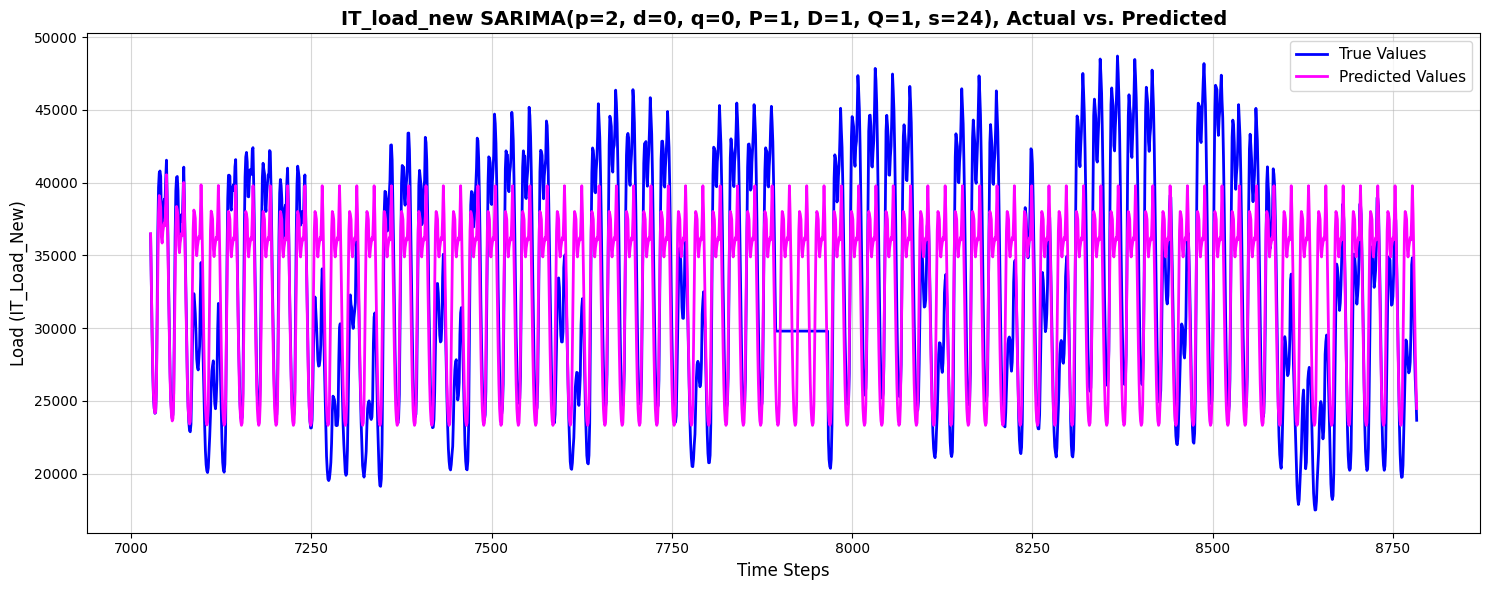

In [159]:
plt.figure(figsize=(15, 6))
plt.plot(load_test_set.index, load_test_set.values, label="True Values", linewidth=2, color="blue")
plt.plot(load_preds_sarima_2.index, load_preds_sarima_2.values, label="Predicted Values", linewidth=2, color="magenta")
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Load (IT_Load_New)", fontsize=12)
plt.title("IT_load_new SARIMA(p=2, d=0, q=0, P=1, D=1, Q=1, s=24), Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

From the summary of `load_sarima_2` it can be concluded that:
1. All the seasonal and non-seasonal coefficients (p, d, q, P, D, and Q) are significant.
2. Seasonal differencing worked and now _there's no downward trend in the predictions. The mean is stable._
3. The RMSE and AIC values are lowest so far, at 5486.63 and 110554.914 respectively.
4. There's still significant autocorrelation in the residuals, which is why the LB test failed (p-value = 0.00). This implies that _the model couldn't capture all the underlying patterns and the residuals aren't just white noise (random)._
5. JB test and test for heteroscedasticity also failed, implying respectively that _residuals aren't distributed Gaussian and also don't have a fixed variance._

There's structure in the residuals, which is what the failed LB test suggests. Since MA terms model dependence on past residuals, adding a non-seasonal MA term would capture that. Therefore, __q changes to 1.__

---

In [160]:
# Fitting another SARIMA model, this time with seasonal differencing
load_sarima_3 = SARIMAX(load_training_set, order=(2, 0, 1), seasonal_order=(1, 1, 1, 24))
load_sarima_3_results = load_sarima_3.fit()

# Displaying the fitting summary
print(load_sarima_3_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        IT_load_new   No. Observations:                 7027
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -55237.142
Date:                            Sat, 15 Aug 2026   AIC                         110486.284
Time:                                    02:12:06   BIC                         110527.409
Sample:                                         0   HQIC                        110500.455
                                           - 7027                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4983      0.011    141.777      0.000       1.478       1.519
ar.L2         -0.5263      0.010   

In [161]:
# Make predictions on the test set
load_preds_sarima_3 = load_sarima_3_results.predict(start=len(load_training_set), end=len(load_training_set)+len(load_test_set)-1)

# Calculate RMSE error
load_rmse_sarima_3 = np.sqrt(mean_squared_error(load_test_set, load_preds_sarima_3))
print(f"\nThe RMSE of the 3rd SARIMA model for IT_load_new is: {load_rmse_sarima_3:.2f}.")


The RMSE of the 3rd SARIMA model for IT_load_new is: 5488.78.


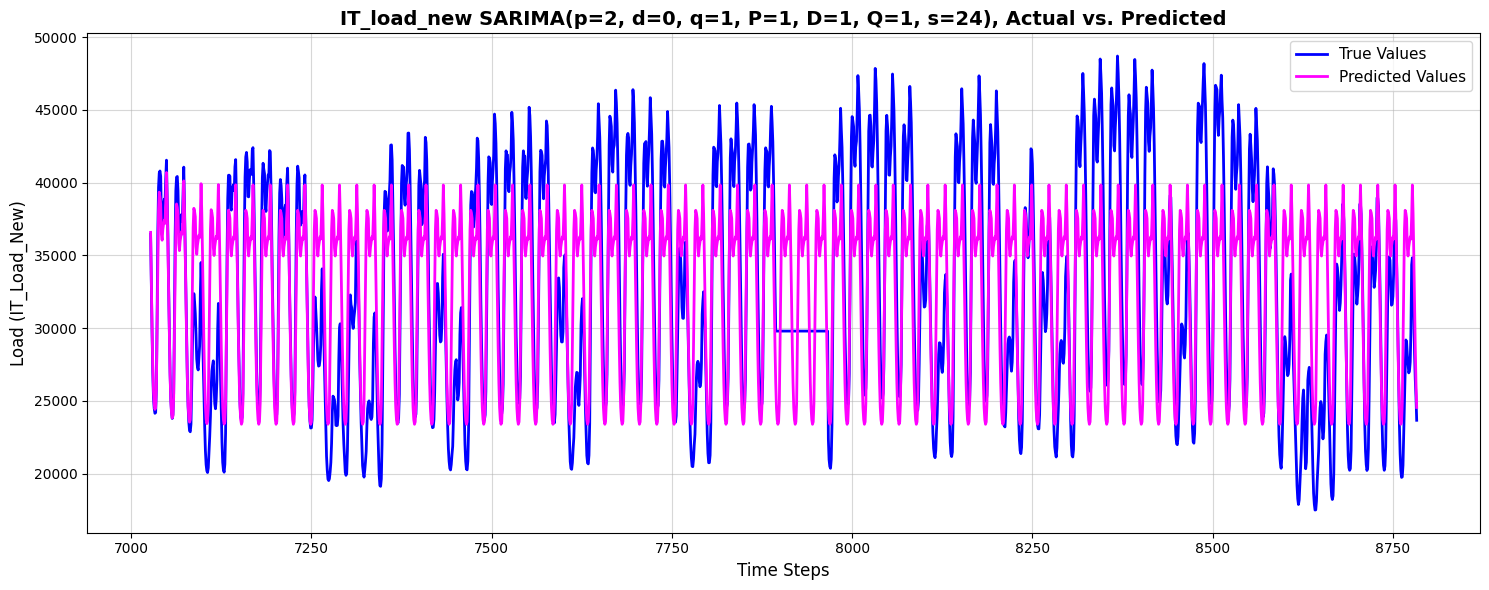

In [162]:
plt.figure(figsize=(15, 6))
plt.plot(load_test_set.index, load_test_set.values, label="True Values", linewidth=2, color="blue")
plt.plot(load_preds_sarima_3.index, load_preds_sarima_3.values, label="Predicted Values", linewidth=2, color="magenta")
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Load (IT_Load_New)", fontsize=12)
plt.title("IT_load_new SARIMA(p=2, d=0, q=1, P=1, D=1, Q=1, s=24), Actual vs. Predicted", fontsize=14, fontweight="bold")
plt.legend(loc="best", fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

Similar to `load_sarima_2`:
1. All the coefficients are significant and there's no downward trend.
2. `load_sarima_3` has passed the LB test, meaning that the residuals are now just white noise.
3. The RMSE of `load_sarima_3` is slightly greater (5488.78) but the AIC value is lowest yet (110486.284).
4. JB test and heteroscedasticity test still rejected the null hypothesis, but they're less critical than LB test for forecasting.

It can be observed that, despite being the best SARIMA model so far, `load_sarima_3` can't match the true values closely beyond a short horizon. After a few steps, the forecasts tend to repeat a learned average daily pattern. This loss of information about variability is a fundamental limit of SARIMA being a linear model, and is also what causes a relatively high RMSE. A similar thing can be observed for ARIMA, where forecasts many steps ahead revert back to the mean.

To fit our time series better, we need a model that can learn the non-linear and complex relationships. __ML models are apt options to explore subsequently.__

---

Before trying ML models on `IT_load_new`, a SARIMA model needs to be fitted on `IT_solar_generation` following all the steps taken so far to establish a benchmark against which other models can be evaluated:

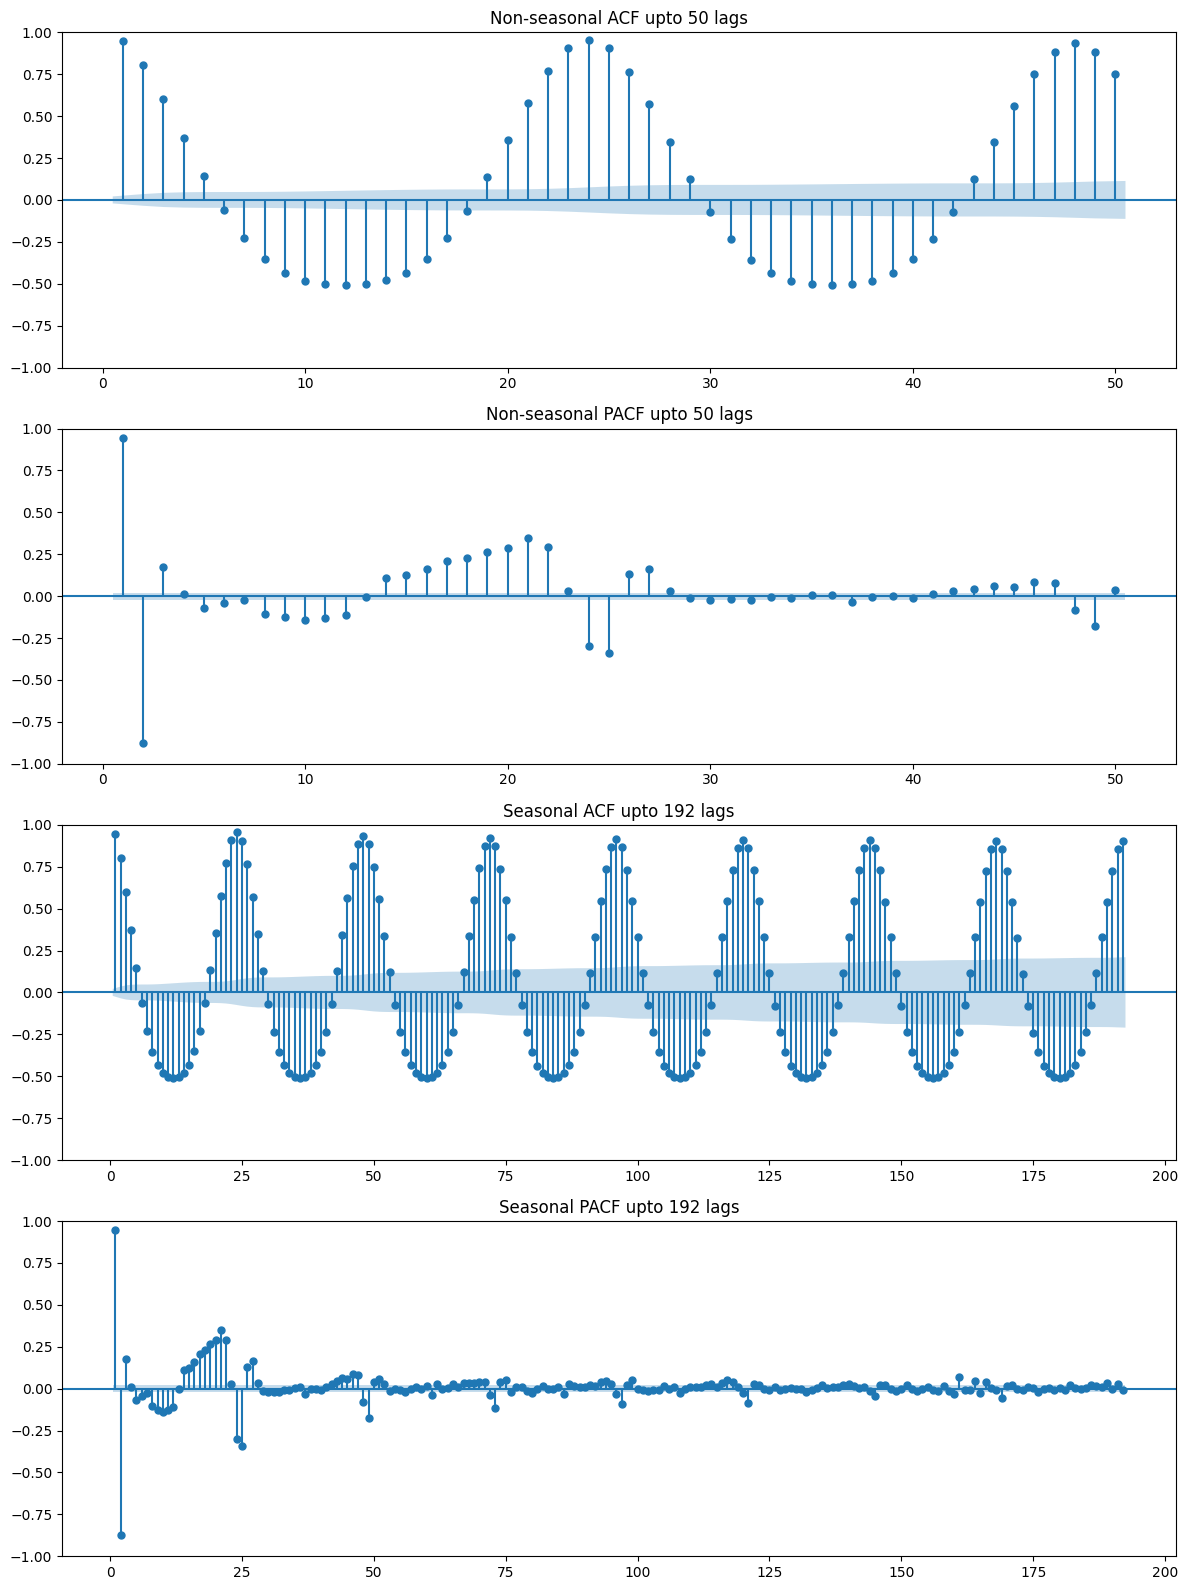

In [163]:
# For IT_solar_generation

# Splitting the series into training and test sets in 80/20 ratio
gen_training_size = int(len(energy_df['IT_solar_generation'])*0.8)
gen_training_set, gen_test_set = energy_df['IT_solar_generation'][:gen_training_size], energy_df['IT_solar_generation'][gen_training_size:]

# Plotting the ACF and PACF plots for IT_solar_generation
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12, 16))

seasonal_period = 24

plot_acf(energy_df['IT_solar_generation'], lags=50, zero=False, ax=ax[0])
ax[0].set_title(f"Non-seasonal ACF upto 50 lags")

plot_pacf(energy_df['IT_solar_generation'], lags=50, zero=False, ax=ax[1])
ax[1].set_title(f"Non-seasonal PACF upto 50 lags")

plot_acf(energy_df['IT_solar_generation'], lags=seasonal_period*8, zero=False, ax=ax[2])
ax[2].set_title(f"Seasonal ACF upto {seasonal_period*8} lags")

plot_pacf(energy_df['IT_solar_generation'], lags=seasonal_period*8, zero=False, ax=ax[3])
ax[3].set_title(f"Seasonal PACF upto {seasonal_period*8} lags")

plt.tight_layout()

plt.show()

---

_For IT_solar_generation, it can be inferred that:_ <br>
From the non-seasonal ACF plot, __q = 0__ <br>
From ADF test in the beginning, __d = 0__ <br>
From the non-seasonal PACF plot, __p = 2__ <br>
From the seasonal ACF plot, __Q = 1__ <br>
From ADF test in the beginning, __D = 0__ <br>
From the seasonal PACF plot, __P = 1__ <br>
Plotting IT_solar_generation against the time stamps gives __s = 24__

---

In [164]:
# Fitting a SARIMA model
gen_sarima_1 = SARIMAX(gen_training_set, order = (2, 0, 1), seasonal_order=(1, 1, 1, 24))
gen_sarima_1_results = gen_sarima_1.fit()

# Displaying the fitting summary
print(gen_sarima_1_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                IT_solar_generation   No. Observations:                 7027
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -48871.364
Date:                            Sat, 15 Aug 2026   AIC                          97754.728
Time:                                    02:12:43   BIC                          97795.853
Sample:                                         0   HQIC                         97768.899
                                           - 7027                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.5760      0.019     84.428      0.000       1.539       1.613
ar.L2         -0.6588      0.018   

In [165]:
# Make predictions on the test set
gen_preds_sarima_1 = gen_sarima_1_results.predict(start=len(gen_training_set), end=len(gen_training_set)+len(gen_test_set)-1)

# Calculate the RMSE error
gen_rmse_sarima_1 = np.sqrt(mean_squared_error(gen_test_set, gen_preds_sarima_1))
print(f"\nThe RMSE of the first SARIMA model for IT_solar_generation is: {gen_rmse_sarima_1:.2f}")


The RMSE of the first SARIMA model for IT_solar_generation is: 1353.80


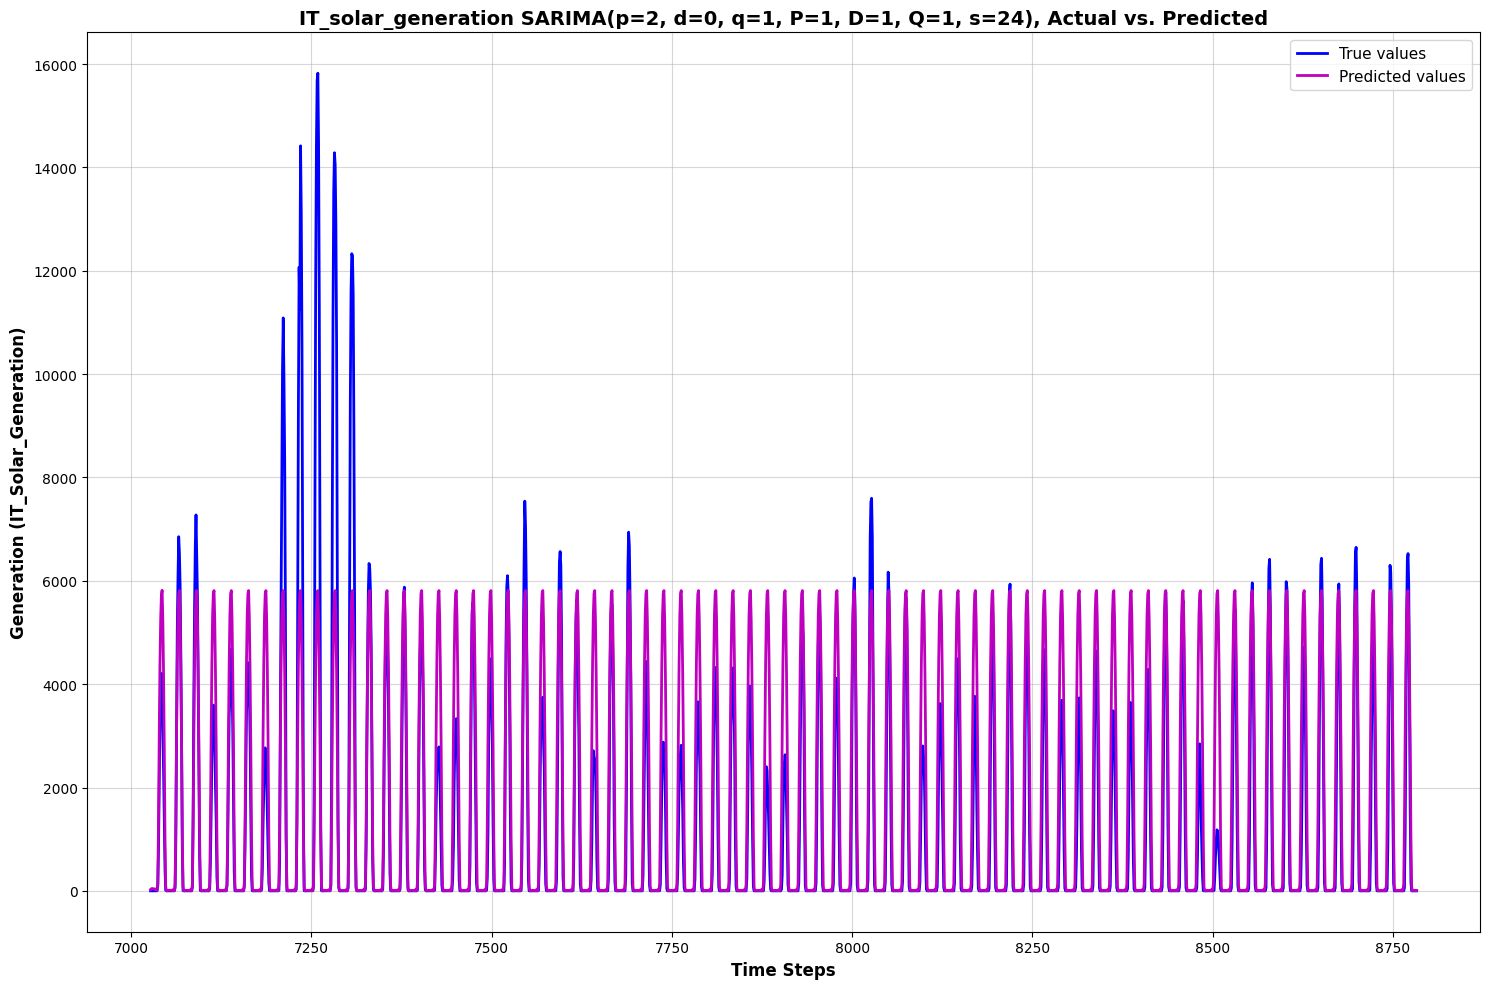

In [166]:
# Plot the predictions against the true values
plt.figure(figsize=(15, 10))
plt.plot(gen_test_set.index, gen_test_set.values, label='True values', color='b', linewidth=2)
plt.plot(gen_preds_sarima_1.index, gen_preds_sarima_1.values, label='Predicted values', color='m', linewidth=2)
plt.xlabel('Time Steps', fontsize=12, fontweight='bold')
plt.ylabel('Generation (IT_Solar_Generation)', fontsize=12, fontweight='bold')
plt.title('IT_solar_generation SARIMA(p=2, d=0, q=1, P=1, D=1, Q=1, s=24), Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

Similar to the case of `IT_load_new`, 3 different SARIMA models were fitted on `IT_solar_generation`: `SARIMA(2, 0, 0)(1, 0, 1, 24)`, `SARIMA(2, 0, 0)(1, 1, 1, 24)`, and `SARIMA(2, 0, 1)(1, 1, 1, 24)` out of which the last one cleared all the requirements.

SARIMA for `IT_solar_generation` also has the same shortcomings as that for `IT_load_new` because of which ML models have to be tested next for a better fit.

---

<table style="margin-left:auto; margin-right:auto; margin-collapse:collapse;">
    <thead>
        <tr>
            <th colspan="6" style="text-align:center; color:orange; font-weight:bold; font-size:20px;">Summary of all Statistical Models</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">Model</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">p-value (LB test)</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">p-value (JB test)</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">p-value (Heteroscedasticity)</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">RMSE</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">AIC</td>
        </tr>
        <tr>
            <td colspan="6" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_load_new</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">ARIMA(2, 0, 0)</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">7712.04</td>
            <td style="text-align:center; color:green; font-size:14;">119791.057</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">ARIMA(4, 0, 0)</td>
            <td style="text-align:center; color:green; font-size:14;">0.94</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">7715.45</td>
            <td style="text-align:center; color:green; font-size:14;">119338.300</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 0)(1, 0, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">8029.21</td>
            <td style="text-align:center; color:green; font-size:14;">110873.925</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 0)(1, 1, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">5486.63</td>
            <td style="text-align:center; color:green; font-size:14;">110554.914</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 1)(1, 1, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.07</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">5488.78</td>
            <td style="text-align:center; color:green; font-size:14;">110486.284</td>
        </tr>
        <tr>
            <td colspan="6" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_solar_generation</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 0)(1, 0, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">1340.60</td>
            <td style="text-align:center; color:green; font-size:14;">98723.801</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 0)(1, 1, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">1360.19</td>
            <td style="text-align:center; color:green; font-size:14;">97922.074</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-weight:bold; font-size:14;">SARIMA(2, 0, 1)(1, 1, 1, 24)</td>
            <td style="text-align:center; color:green; font-size:14;">0.56</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">0.00</td>
            <td style="text-align:center; color:green; font-size:14;">1353.80</td>
            <td style="text-align:center; color:green; font-size:14;">97754.728</td>
        </tr>
    </tbody>
</table>

### __D. Fitting XGBoost__

---

ARIMA and SARIMA couldn't capture the day-to-day variability as it's essentially a linear model. Tree-based ML models can learn context-dependent patterns as a tree can make a split at any continuous threshold. This gives a piecewise approximation for any non-linear function, like the graphs of `IT_load_new` and `IT_solar_generation`.

Now, `IT_load_new` and `IT_solar_generation` are both continuous variables, so it's a regression problem. Also, `utc_timestamp` can't be readily used, it needs to be split into hour, day, month, and day of week that can be used as features for training. Lagged values can be also used as features to capture temporal dependencies. After doing the required changes we'll have a usable and tabular time series dataset, and fitting an __XGBoost Regressor on it would be the next appropriate step.__ XGBoost has a great empirical track record on tabular data, is quick to train, is more tunable, and is industry-standard. Care has to be taken while splitting the dataset since temporal data can't be shuffled randomly.

The heavily right-skewed nature of the distribution of `IT_solar_generation` won't be an issue for XGBoost Regressors as tree-based models are generally robust to skewness and don't rely on conditions for normality. So no transformation of `IT_solar_generation` is necessary.

---

In [167]:
# Creating new columns for hour, day, month, day of week, and lagged features
energy_df['hour'] = energy_df['utc_timestamp'].dt.hour
energy_df['day'] = energy_df['utc_timestamp'].dt.day
energy_df['month'] = energy_df['utc_timestamp'].dt.month
energy_df['dayofweek'] = energy_df['utc_timestamp'].dt.dayofweek
energy_df['load_lag_1'] = energy_df['IT_load_new'].shift(1)
energy_df['load_lag_24'] = energy_df['IT_load_new'].shift(24)
energy_df['gen_lag_1'] = energy_df['IT_solar_generation'].shift(1)
energy_df['gen_lag_24'] = energy_df['IT_solar_generation'].shift(24)

# Rows with indices less than the lag amount will have NaN values, they need to be dropped
energy_df.dropna(subset=['load_lag_1', 'load_lag_24', 'gen_lag_1', 'gen_lag_24'], inplace=True)

# Creating the features and target
X_load = energy_df[['hour', 'day', 'month', 'dayofweek', 'load_lag_1', 'load_lag_24']]
y_load = energy_df['IT_load_new']
X_gen = energy_df[['hour', 'day', 'month', 'dayofweek', 'gen_lag_1', 'gen_lag_24']]
y_gen = energy_df['IT_solar_generation']

In [168]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


# Splitting the features and target of IT_load_new into training and test sets
X_load_train, X_load_test, y_load_train, y_load_test = train_test_split(X_load, y_load, test_size=0.2, shuffle=False)

# Fitting a XGBoost Regressor with 100 trees, each with 6 splits max
load_xgbr_1 = XGBRegressor(
    n_estimators=100, # Sufficient estimators for baseline
    max_depth=6, # Moderate depth for baseline
    learning_rate=0.1, # Moderate learning rate for baseline
    random_state=42
)
load_xgbr_1.fit(X_load_train, y_load_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [169]:
# Making predictions on test set and evaluating the same
load_preds_xgbr_1 = load_xgbr_1.predict(X_load_test)
load_rmse_xgbr_1 = np.sqrt(mean_squared_error(y_load_test, load_preds_xgbr_1))
print(f"The RMSE of the first XGBoost Regressor on IT_load_new test set is: {load_rmse_xgbr_1:.2f}")

The RMSE of the first XGBoost Regressor on IT_load_new test set is: 1016.11


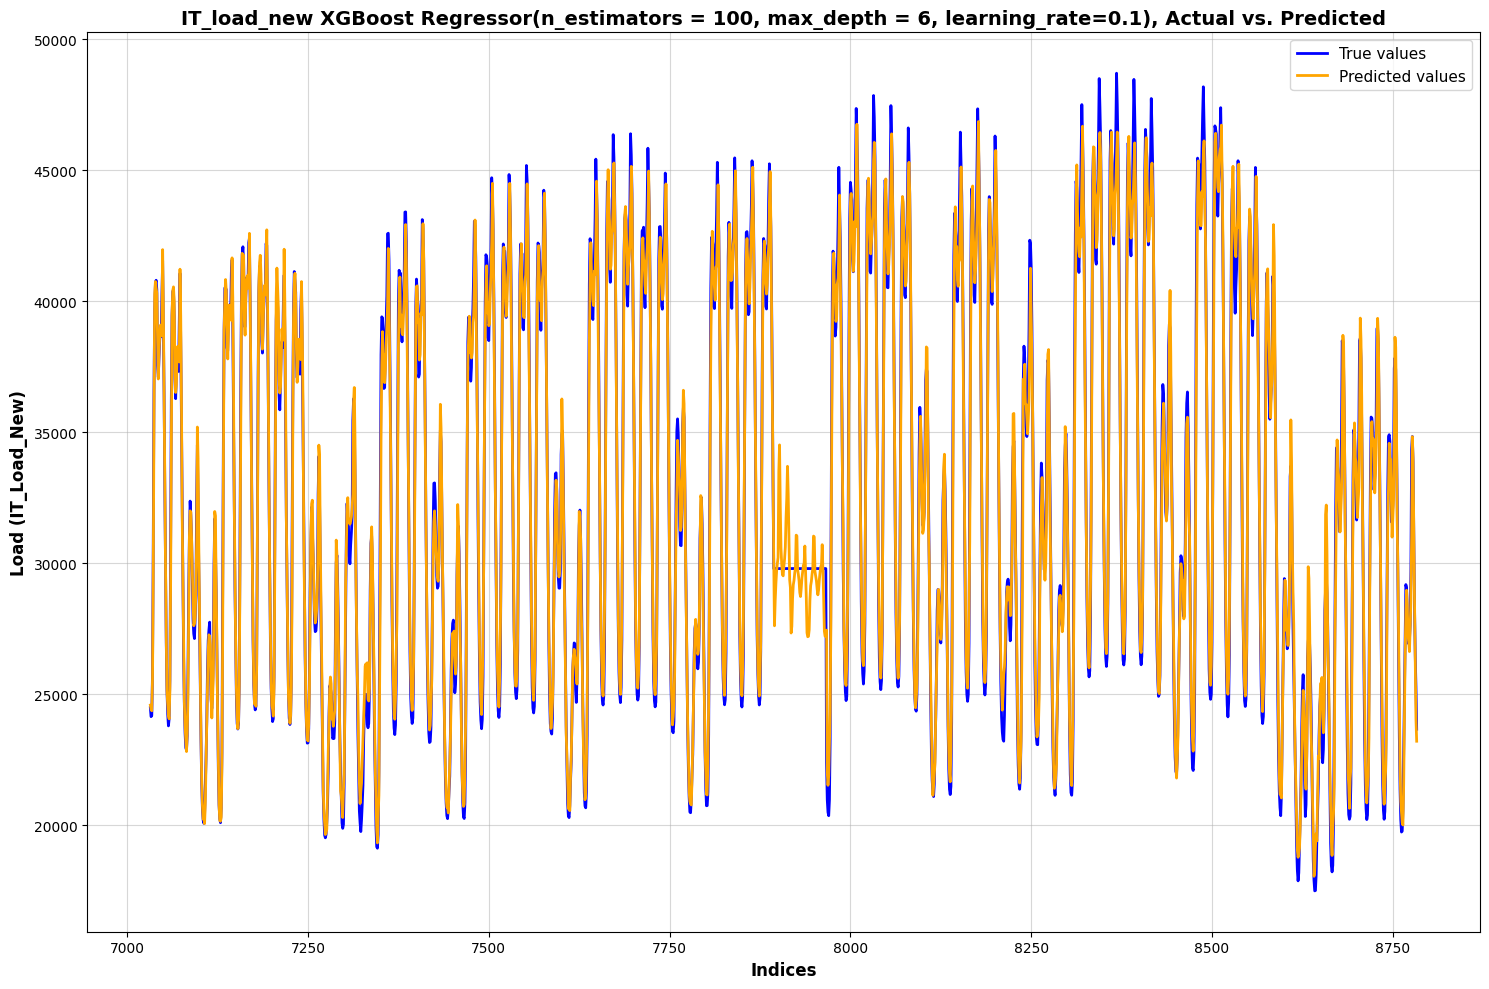

In [170]:
# Plot the predictions against the true values
plt.figure(figsize=(15, 10))
plt.plot(y_load_test.index, y_load_test.values, label='True values', color='b', linewidth=2)
plt.plot(y_load_test.index, load_preds_xgbr_1, label='Predicted values', color='orange', linewidth=2)
plt.xlabel('Indices', fontsize=12, fontweight='bold')
plt.ylabel('Load (IT_Load_New)', fontsize=12, fontweight='bold')
plt.title('IT_load_new XGBoost Regressor(n_estimators = 100, max_depth = 6, learning_rate=0.1), Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

The XGBoost Regressor predicts the `IT_load_new` test set significantly better than the SARIMA model. So much that the RMSE has dropped 5.5 times, and from the plot of predictions vs. true values it is evident that the XGBoost was able to capture the everyday variability decently. A shallow grid search can possibly give a better set of hyperparameters for XGBoost:

---

In [171]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer

# Creating a parameter grid for XGBoost Regressor
xgbr_param_grid_1 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

# Creating a RMSE scorer to evaluate the grid search on
rmse_scorer_1 = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

# Time series data can't be split randomly so we use TimeSeriesSplit to keep temporal integrity
tscv = TimeSeriesSplit(n_splits=3)

# Instantiating a XGBoost Regressor to perform grid search
load_xgbr_2 = XGBRegressor(random_state=42)

# Creating and fitting a grid search instance
load_xgbr_grid_search = GridSearchCV(
    load_xgbr_2,
    xgbr_param_grid_1,
    scoring=rmse_scorer_1,
    cv=tscv,
    n_jobs=-1
)
load_xgbr_grid_search.fit(X_load_train, y_load_train)

# Printing the best parameters from grid search
print(f'Best results from grid search with XGBoost for IT_load_new:', end="")
print(f'\nBest parameters: {load_xgbr_grid_search.best_params_}', end="")
print(f'\nBest RMSE with on training set: {-1*load_xgbr_grid_search.best_score_:.2f}')
# scikit-learn uses a maximization metric convention
# for all its internal scoring systems which means
# higher scores are always better, which is why
# scikit-learn multiplies the original error metrics
# with -1. To get the original error metric, it needs
# to multiplied with -1 again.

Best results from grid search with XGBoost for IT_load_new:
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300}
Best RMSE with on training set: 1050.89


In [172]:
load_preds_xgbr_2 = load_xgbr_grid_search.best_estimator_.predict(X_load_test)
load_rmse_xgbr_2 = np.sqrt(mean_squared_error(y_load_test, load_preds_xgbr_2))

print(f'The RMSE on IT_load_new test set of the best estimator using grid search is: {load_rmse_xgbr_2:.2f}')

The RMSE on IT_load_new test set of the best estimator using grid search is: 1060.78


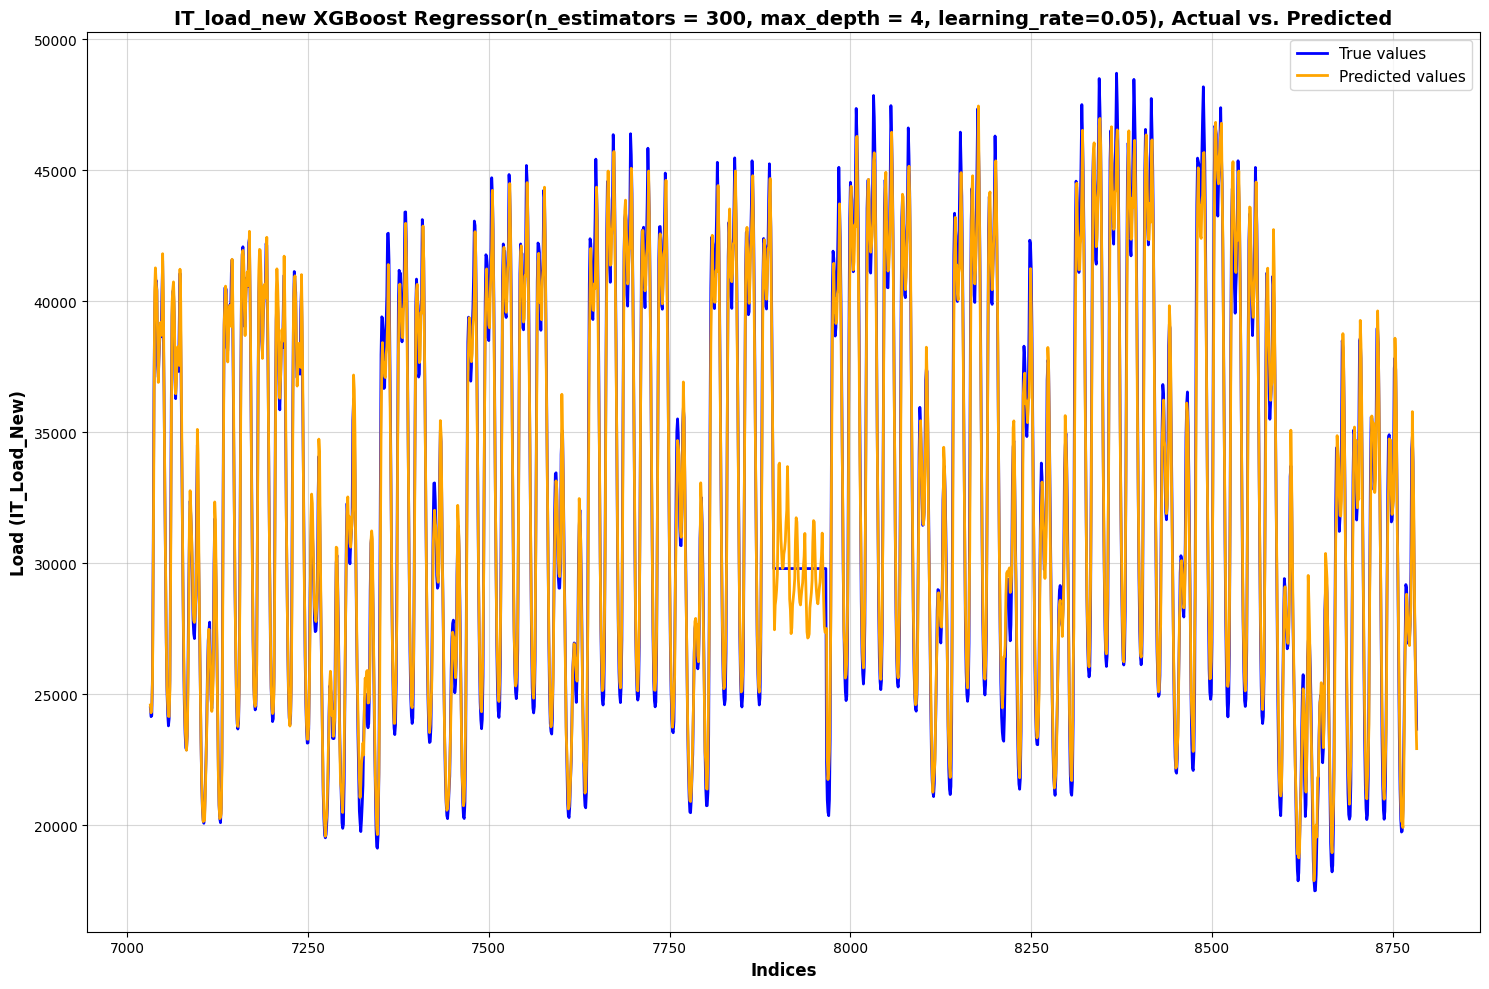

In [173]:
# Plot the predictions against the true values
plt.figure(figsize=(15, 10))
plt.plot(y_load_test.index, y_load_test.values, label='True values', color='b', linewidth=2)
plt.plot(y_load_test.index, load_preds_xgbr_2, label='Predicted values', color='orange', linewidth=2)
plt.xlabel('Indices', fontsize=12, fontweight='bold')
plt.ylabel('Load (IT_Load_New)', fontsize=12, fontweight='bold')
plt.title('IT_load_new XGBoost Regressor(n_estimators = 300, max_depth = 4, learning_rate=0.05), Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

Through grid search, it is evident that the best estimator (`n_estimators`: 300, `max_depth`:4, `learning_rate`: 0.05) has an RMSE of 1067.44 and 1011.16 on `the IT_load_new` training and test sets, respectively. This indicates underfitting and moreover, both values are worse than the test RMSE of the first XGBoost. Therefore, the default choice of hyperparameters are the best (`n_estimators`: 100, `max_depth`:6, `learning_rate`: 0.1). The same process can be followed to fit an XGBoost on `IT_solar_generation`:

In [174]:
# Splitting IT_solar_generation features and target into training and test sets
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_gen, y_gen, test_size=0.2, shuffle=False)

# Fitting a XGBoost Regressor with 100 trees, each with 6 splits max
gen_xgbr_1 = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
gen_xgbr_1.fit(X_gen_train, y_gen_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [175]:
gen_preds_xgbr_1 = gen_xgbr_1.predict(X_gen_test)
gen_rmse_xgbr_1 = np.sqrt(mean_squared_error(y_gen_test, gen_preds_xgbr_1))
print(f"The RMSE of the first XGBRegressor on IT_solar_generation test set is: {gen_rmse_xgbr_1:.2f}")

The RMSE of the first XGBRegressor on IT_solar_generation test set is: 545.15


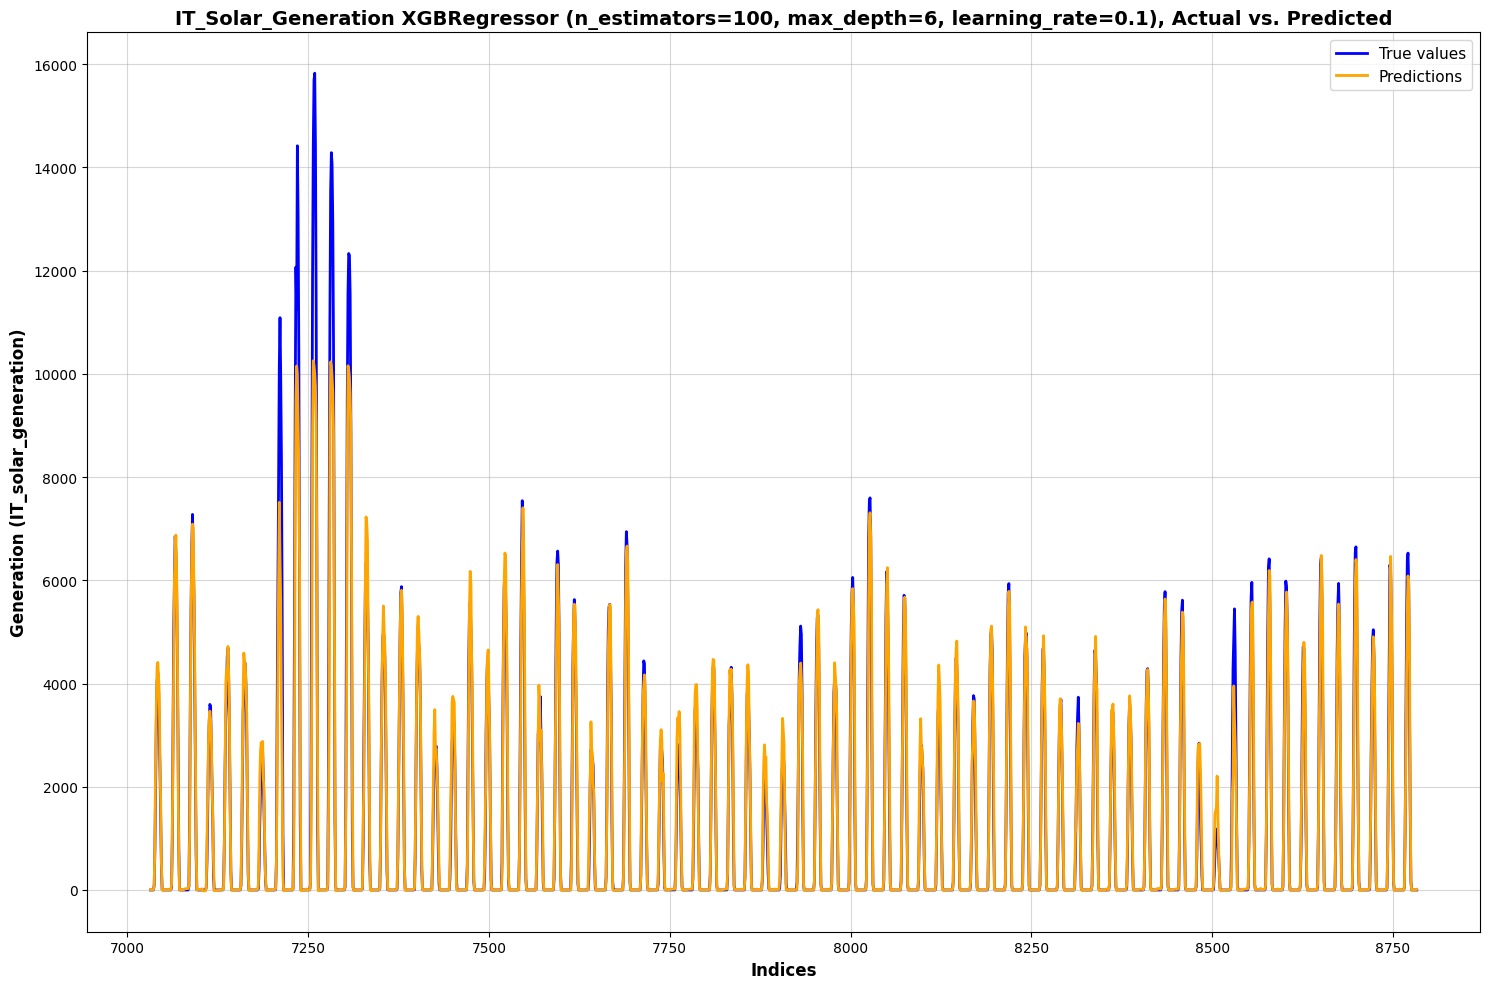

In [176]:
# Plotting predictions against true values
plt.figure(figsize=(15, 10))
plt.plot(y_gen_test.index, y_gen_test.values, label='True values', color='b', linewidth=2)
plt.plot(y_gen_test.index, gen_preds_xgbr_1, label='Predictions', color='orange', linewidth=2)
plt.xlabel('Indices', fontweight='bold', fontsize=12)
plt.ylabel('Generation (IT_solar_generation)', fontweight='bold', fontsize=12)
plt.title('IT_Solar_Generation XGBRegressor (n_estimators=100, max_depth=6, learning_rate=0.1), Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

In [178]:
# Creating another XGBRegressor instance for grid search
gen_xgbr_2 = XGBRegressor(random_state=42)

# Creating and fitting a grid search instance
gen_xgbr_grid_search = GridSearchCV(gen_xgbr_2, xgbr_param_grid_1, scoring=rmse_scorer_1, cv=tscv, n_jobs=-1)
gen_xgbr_grid_search.fit(X_gen_train, y_gen_train)

# Printing the best parameters from grid search
print(f'Best results from grid search with XGBoost for IT_solar_generation:', end="")
print(f'\nBest parameters: {gen_xgbr_grid_search.best_params_}', end="")
print(f'\nBest RMSE with on training set: {-1*gen_xgbr_grid_search.best_score_:.2f}')

Best results from grid search with XGBoost for IT_solar_generation:
Best parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
Best RMSE with on training set: 322.04


In [45]:
gen_preds_xgbr_2 = gen_xgbr_grid_search.best_estimator_.predict(X_gen_test)
gen_rmse_xgbr_2 = np.sqrt(mean_squared_error(y_gen_test, gen_preds_xgbr_2))
print(f"RMSE on IT_solar_generation test set of the best estimator from grid search is: {gen_rmse_xgbr_2:.2f}")

RMSE on IT_solar_generation test set of the best estimator from grid search is: 522.94


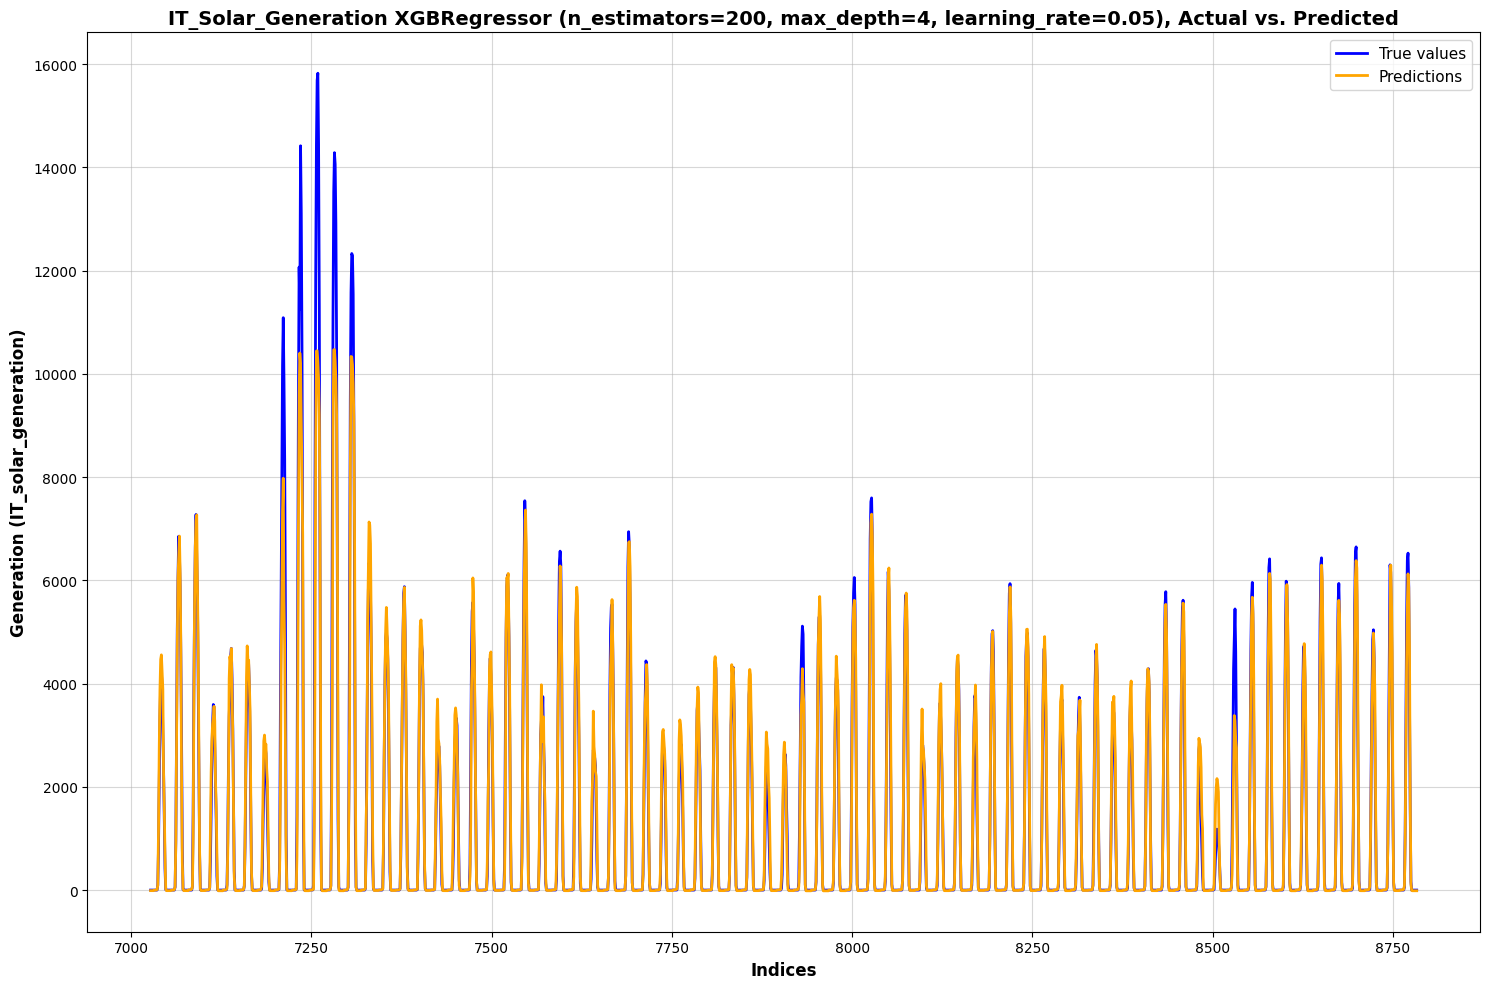

In [46]:
# Plotting predictions against true values
plt.figure(figsize=(15, 10))
plt.plot(y_gen_test.index, y_gen_test.values, label='True values', color='b', linewidth=2)
plt.plot(y_gen_test.index, gen_preds_xgbr_2, label='Predictions', color='orange', linewidth=2)
plt.xlabel('Indices', fontweight='bold', fontsize=12)
plt.ylabel('Generation (IT_solar_generation)', fontweight='bold', fontsize=12)
plt.title('IT_Solar_Generation XGBRegressor (n_estimators=200, max_depth=4, learning_rate=0.05), Actual vs. Predicted', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

---

Unlike the case of `IT_load_new`, the best estimator for `IT_solar_generation` (`n_estimators`: 200, `max_depth`: 4, `learning_rate`: 0.05) from grid search has an RMSE of 309.57 and 522.94 on the training and test sets respectively, which is lower than the RMSE of the first XGBRegressor on the test set (553.14). The best parameters suggest moderate regularization happening from shallower trees (reduced `max_depth`) and slower learning (reduced `learning_rate`) which contributed to lower test set RMSE. Therefore, grid search gave a better set of XGBRegressor hyperparameters for `IT_solar_generation`.

It can be concluded that tests with ensemble ML algorithms like XGBoost for a better fit on `IT_load_new` and `IT_solar_generation` were successful.

---

<table style="margin-left:auto; margin-right:auto; margin-collapse:collapse;">
    <thead>
        <tr>
            <th colspan="4" style="text-align:center; color:orange; font-weight:bold; font-size:20px;">Summary of all XGBoost Regressors</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">n_estimators</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">max_depth</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">learning_rate</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">RMSE on test set</td>
        </tr>
        <tr>
            <td colspan="4" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_load_new</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">100</td>
            <td style="text-align:center; color:green; font-size:14;">6</td>
            <td style="text-align:center; color:green; font-size:14;">0.1</td>
            <td style="text-align:center; color:green; font-size:14;">993.01</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">300</td>
            <td style="text-align:center; color:green; font-size:14;">4</td>
            <td style="text-align:center; color:green; font-size:14;">0.05</td>
            <td style="text-align:center; color:green; font-size:14;">1011.16</td>
        </tr>
        <tr>
            <td colspan="4" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_solar_generation</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">100</td>
            <td style="text-align:center; color:green; font-size:14;">6</td>
            <td style="text-align:center; color:green; font-size:14;">0.1</td>
            <td style="text-align:center; color:green; font-size:14;">553.14</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">200</td>
            <td style="text-align:center; color:green; font-size:14;">4</td>
            <td style="text-align:center; color:green; font-size:14;">0.05</td>
            <td style="text-align:center; color:green; font-size:14;">522.94</td>
        </tr>
    </tbody>
</table>

### __E. Fitting LSTM__

---

Tree-based models are well-suited to our tabular dataset with engineered features. However, sequence models like LSTMs learn temporal relationships automatically from raw or minimally engineered sequences without explicit feature engineering.

To check whether end-to-end learning using LSTMs offer any advantage over manually created features, a single layer LSTM can be fit on sequences of `IT_load_new` and `IT_solar_generation`, each sequence consisting of values from last 24 timesteps.

Now, an LSTM would require careful tuning as our dataset is small and already has explicit temporal features. Nevertheless, it will most likely underperform in comparison to the XGBoost regressor, making it inefficient for this application.

As `IT_solar_generation` is strongly right-skewed, it can bias LSTMs towards the highly concentrated low-value regions unless the distribution is transformed appropriately. Also, scaling of the dataset is necessary for gradient descent optimization.

---

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
import numpy as np

# ---- For IT_load_new ----

# reshaping needed as TensorFlow expects tensors
load_raw = energy_df['IT_load_new'].values.reshape(-1, 1)

# Defining length of input sequences
SEQ_LENGTH = 24

# Splitting the raw values into training and test sets
split_idx = int(len(load_raw) * 0.8)
load_raw_training = load_raw[:split_idx]
load_raw_test = load_raw[split_idx - SEQ_LENGTH:]
# By doing '- SEQ_LENGTH', an overlap is created between the
# 2 sets to generate sequences that preserve some context

# Normalizing load_training_set and load_test_set
# to prevent gradient explosion and unequal feature weighting
load_scaler = MinMaxScaler()
load_scaled_training = load_scaler.fit_transform(load_raw_training)
load_scaled_test = load_scaler.transform(load_raw_test)
# Always fit the scaler on the training data only
# and use it to scale the test set. Never fit the
# scaler on the entire dataset, as it causes leakage.

def create_sequences(data, seq_length):
    """
    Creates pairs of input sequences
    and their respective target values.
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length, 0])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

# Creating sequences from training and test sets
load_X_seq_training, load_y_seq_training = create_sequences(
    load_scaled_training, SEQ_LENGTH
)
load_X_seq_test, load_y_seq_test = create_sequences(
    load_scaled_test, SEQ_LENGTH
)

# Reshape the training and test sequences to 3D tensors
# as TensorFlow expects - (batch_size, time_steps, features)
load_X_seq_training = (
    load_X_seq_training
    .reshape(
        load_X_seq_training.shape[0],
        load_X_seq_training.shape[1],
        1
    )
)

load_X_seq_test = (
    load_X_seq_test
    .reshape(
        load_X_seq_test.shape[0],
        load_X_seq_test.shape[1],
        1
    )
)

2026-08-09 00:15:09.637975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786234509.966574      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786234510.058190      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [48]:
# Building a single layer LSTM network
load_LSTM_1 = Sequential([
    Input((SEQ_LENGTH, 1)),
    LSTM(32),
    Dropout(0.2), # Dropout to reduce variance and overfitting
    Dense(1)
])

# Configuring the training of the LSTM network
load_LSTM_1.compile(
    optimizer=Adam(learning_rate=0.001), loss='mse'
)

# Defining an early stopping callback to prevent overfitting and save time
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Fitting the LSTM newtork on the training data
load_LSTM_1_history = load_LSTM_1.fit(
    load_X_seq_training,
    load_y_seq_training,
    epochs=60, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/60


2026-08-09 00:15:32.528157: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0900 - val_loss: 0.0276
Epoch 2/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0282 - val_loss: 0.0163
Epoch 3/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0171 - val_loss: 0.0117
Epoch 4/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0136 - val_loss: 0.0096
Epoch 5/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0120 - val_loss: 0.0081
Epoch 6/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0106 - val_loss: 0.0070
Epoch 7/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0089 - val_loss: 0.0061
Epoch 8/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0079 - val_loss: 0.0056
Epoch 9/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0071 - val_loss: 0.0036
Epoch 10/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0063 - val_loss: 0.0033
Epoch 11/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - val_loss: 0.0028
Epoch 12/60
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0046 - val_l

In [49]:
# Using the fitted LSTM network to make predictions on the test set
load_y_seq_preds_1 = load_LSTM_1.predict(load_X_seq_test)

# Performing inverse transformation to get predictions in original scale
load_y_seq_preds_original_1 = load_scaler.inverse_transform(load_y_seq_preds_1)

# TensorFlow accepts 1D array if we're forecasting 1 step ahead
# for a single feature, but generates the predictions as a 2D array
# For this reason, the target data used in training has to be reshaped
load_y_seq_test_original = load_scaler.inverse_transform(
    load_y_seq_test.reshape(-1, 1)
)

# Calculating the RMSE in predictions
load_rmse_LSTM_1 = np.sqrt(mean_squared_error(
    load_y_seq_test_original,
    load_y_seq_preds_original_1
))
print(f"\nThe RMSE of the 1st LSTM network for IT_load_new is: {load_rmse_LSTM_1:.2f}.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

The RMSE of the 1st LSTM network for IT_load_new is: 1042.89.


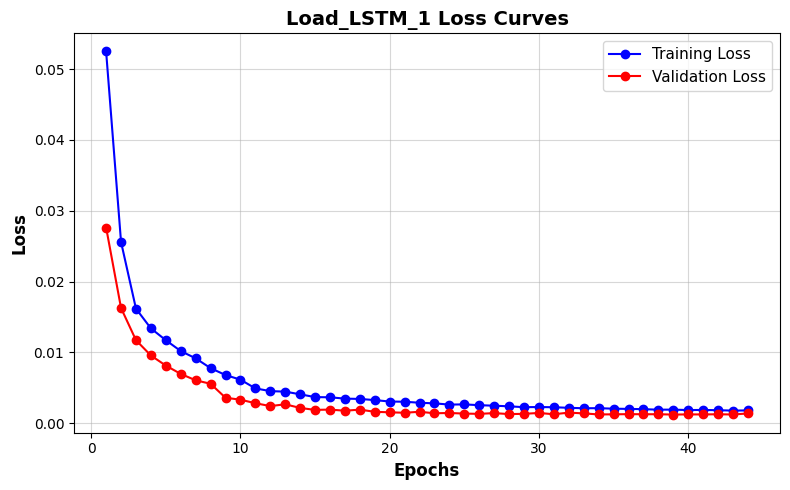

In [50]:
# Extracting loss values
load_LSTM_1_training_loss = load_LSTM_1_history.history['loss']
load_LSTM_1_val_loss = load_LSTM_1_history.history['val_loss']
load_LSTM_1_epochs = range(1, len(load_LSTM_1_training_loss) + 1)

# Creating plots
plt.figure(figsize=(8, 5))
plt.plot(load_LSTM_1_epochs, load_LSTM_1_training_loss, 'bo-', label='Training Loss')
plt.plot(load_LSTM_1_epochs, load_LSTM_1_val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs', fontweight='bold', fontsize=12)
plt.ylabel('Loss', fontweight='bold', fontsize=12)
plt.title('Load_LSTM_1 Loss Curves', fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.show()

In [51]:
# Building a second LSTM network for IT_load_new
load_LSTM_2 = Sequential([
    Input((SEQ_LENGTH, 1)),
    LSTM(
        32, return_sequences=True,
        kernel_regularizer=l2(1e-4),
        recurrent_regularizer=l2(1e-4),
    ),
    Dropout(0.25),
    LSTM(
        16, kernel_regularizer=l2(1e-4),
        recurrent_regularizer=l2(1e-4),
    ),
    Dropout(0.25),
    Dense(1)
])

# Configuring the training
opt = Adam(learning_rate=1e-4, clipnorm=1.0)
load_LSTM_2.compile(optimizer=opt, loss='mse')

In [52]:
# Fitting the LSTM newtork on the training data
load_LSTM_2_history = load_LSTM_2.fit(
    load_X_seq_training,
    load_y_seq_training,
    epochs=100, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=0
)

In [53]:
# Using the fitted LSTM network to make predictions on the test set
load_y_seq_preds_2 = load_LSTM_2.predict(load_X_seq_test)

# Performing inverse transformation to get predictions in original scale
load_y_seq_preds_original_2 = load_scaler.inverse_transform(load_y_seq_preds_2)

# Calculating the RMSE in predictions
load_rmse_LSTM_2 = np.sqrt(mean_squared_error(
    load_y_seq_test_original,
    load_y_seq_preds_original_2
))
print(f"\nThe RMSE of the 2nd LSTM network for IT_load_new is: {load_rmse_LSTM_2:.2f}.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

The RMSE of the 2nd LSTM network for IT_load_new is: 2790.84.


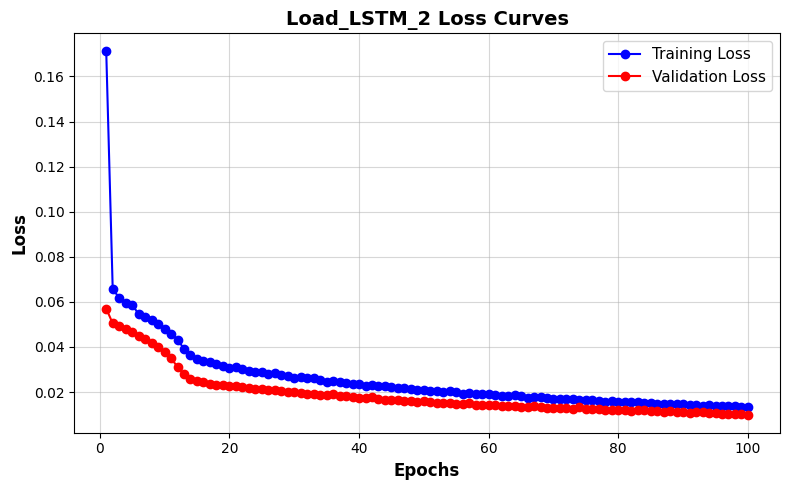

In [54]:
# Extracting loss values
load_LSTM_2_training_loss = load_LSTM_2_history.history['loss']
load_LSTM_2_val_loss = load_LSTM_2_history.history['val_loss']
load_LSTM_2_epochs = range(1, len(load_LSTM_2_training_loss) + 1)

# Creating plots
plt.figure(figsize=(8, 5))
plt.plot(load_LSTM_2_epochs, load_LSTM_2_training_loss, 'bo-', label='Training Loss')
plt.plot(load_LSTM_2_epochs, load_LSTM_2_val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs', fontweight='bold', fontsize=12)
plt.ylabel('Loss', fontweight='bold', fontsize=12)
plt.title('Load_LSTM_2 Loss Curves', fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.show()

---

A single-layer LSTM was evaluated as a baseline RNN for `IT_load_new`, but as assumed, it underperformed XGBoost. Its RMSE on the test set (1043.26) was more than that of the XGBRegressor (993.01)

A 2-layer stacked LSTM performed significantly worse, with an RMSE of 2796.59 on the test set which is around 2.8 times more than that of the best XGBRegressor, implying that extra recurrent depth increased model complexity without capturing additional useful temporal structure.

The loss curves of training and validation have both converged but since the RMSE is still significantly high it means that for the given set of hyperparameters the models have captured everything they could from the dataset but are still underfitting.

This indicates that for this dataset, the existing patterns are better handled by feature-engineered tree-based models than by sequence models.

__Therefore, it can be concluded that for `IT_load_new`, XGBRegressor is the ideal choice of predictor.__

The same procedure can be followed to fit an LSTM on `IT_solar_generation`.

---

In [55]:
# ---- For IT_solar_generation ----

gen_raw = energy_df['IT_solar_generation'].values.reshape(-1, 1)

split_idx = int(len(gen_raw) * 0.8)
gen_raw_training = gen_raw[:split_idx]
gen_raw_test = gen_raw[split_idx - SEQ_LENGTH:]
# Creating an overalap to preserve context

gen_transformer = PowerTransformer(method='yeo-johnson', standardize=False)
gen_trans_training = gen_transformer.fit_transform(gen_raw_training)
gen_trans_test = gen_transformer.transform(gen_raw_test)

gen_scaler = MinMaxScaler()
gen_scaled_training = gen_scaler.fit_transform(gen_trans_training)
gen_scaled_test = gen_scaler.transform(gen_trans_test)

gen_X_training, gen_y_training = create_sequences(
    gen_scaled_training, SEQ_LENGTH
)
gen_X_test, gen_y_test = create_sequences(
    gen_scaled_test, SEQ_LENGTH
)

gen_X_training = (
    gen_X_training.reshape(
        gen_X_training.shape[0],
        gen_X_training.shape[1],
        1
    )
)
gen_X_test = (
    gen_X_test.reshape(
        gen_X_test.shape[0],
        gen_X_test.shape[1],
        1
    )
)

In [56]:
gen_LSTM_1 = Sequential([
    Input((SEQ_LENGTH, 1)),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

gen_LSTM_1.compile(
    optimizer=Adam(learning_rate=0.001), loss='mse'
)

gen_LSTM_1_history = gen_LSTM_1.fit(
    gen_X_training,
    gen_y_training,
    epochs=60, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
)

Epoch 1/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.1797 - val_loss: 0.0480
Epoch 2/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0296 - val_loss: 0.0417
Epoch 3/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0252 - val_loss: 0.0349
Epoch 4/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0214 - val_loss: 0.0280
Epoch 5/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0194 - val_loss: 0.0201
Epoch 6/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0160 - val_loss: 0.0195
Epoch 7/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0159 - val_loss: 0.0127
Epoch 8/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0126 - val_loss: 0.0086
Epoch 9/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0110 - val_loss: 0.0093
Epoch 10/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101 - val_loss: 0.0060
Epoch 11/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0105 - val_loss: 0.0052
Epoch 12/60
110/110 ━━━━━━━━━━━━━━━━━━━━ 

In [57]:
gen_y_preds_1 = gen_LSTM_1.predict(gen_X_test)

gen_y_preds_1_iscaled = gen_scaler.inverse_transform(gen_y_preds_1)
gen_y_test_iscaled = gen_scaler.inverse_transform(
    gen_y_test.reshape(-1, 1)
)

gen_y_preds_1_original = gen_transformer.inverse_transform(
    gen_y_preds_1_iscaled
)
gen_y_test_original = gen_transformer.inverse_transform(
    gen_y_test_iscaled
)

gen_rmse_LSTM_1 = np.sqrt(mean_squared_error(
    gen_y_test_original,
    gen_y_preds_1_original
))
print(f"\nThe RMSE of the 1st LSTM network for IT_solar_generation is: {gen_rmse_LSTM_1:.2f}.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

The RMSE of the 1st LSTM network for IT_solar_generation is: 830.40.


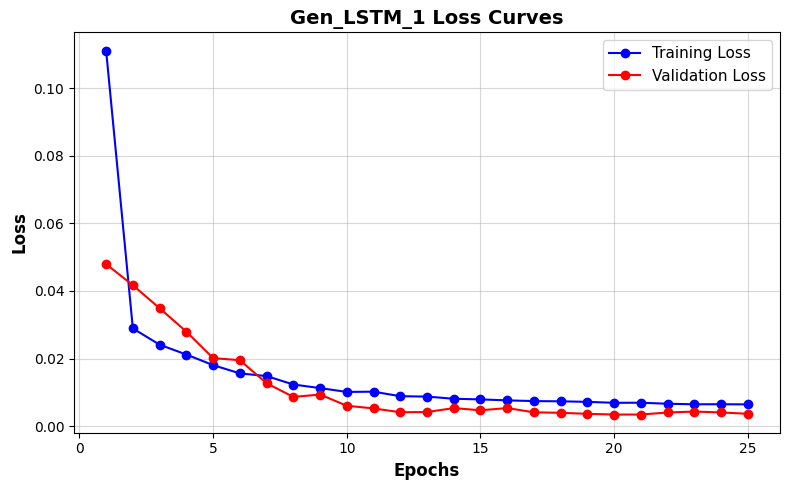

In [58]:
gen_LSTM_1_training_loss = gen_LSTM_1_history.history['loss']
gen_LSTM_1_val_loss = gen_LSTM_1_history.history['val_loss']
gen_LSTM_1_epochs = range(1, len(gen_LSTM_1_training_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(gen_LSTM_1_epochs, gen_LSTM_1_training_loss, 'bo-', label='Training Loss')
plt.plot(gen_LSTM_1_epochs, gen_LSTM_1_val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs', fontweight='bold', fontsize=12)
plt.ylabel('Loss', fontweight='bold', fontsize=12)
plt.title('Gen_LSTM_1 Loss Curves', fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.show()

In [59]:
# Building a second LSTM network for IT_solar_generation
gen_LSTM_2 = Sequential([
    Input((SEQ_LENGTH, 1)),
    LSTM(
        32, return_sequences=True,
        kernel_regularizer=l2(1e-4),
        recurrent_regularizer=l2(1e-4),
    ),
    Dropout(0.25),
    LSTM(
        16, kernel_regularizer=l2(1e-4),
        recurrent_regularizer=l2(1e-4),
    ),
    Dropout(0.25),
    Dense(1)
])

opt = Adam(learning_rate=1e-4, clipnorm=1.0)
gen_LSTM_2.compile(optimizer=opt, loss='mse')

In [60]:
gen_LSTM_2_history = gen_LSTM_2.fit(
    gen_X_training,
    gen_y_training,
    epochs=100, batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=0
)

In [61]:
gen_y_preds_2 = gen_LSTM_2.predict(gen_X_test)

gen_y_preds_iscaled_2 = gen_scaler.inverse_transform(gen_y_preds_2)

gen_y_preds_original_2 = gen_transformer.inverse_transform(
    gen_y_preds_iscaled_2
)

# Calculating the RMSE in predictions
gen_rmse_LSTM_2 = np.sqrt(mean_squared_error(
    gen_y_test_original,
    gen_y_preds_original_2
))
print(f"\nThe RMSE of the 2nd LSTM network for IT_solar_generation is: {load_rmse_LSTM_2:.2f}.")

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

The RMSE of the 2nd LSTM network for IT_solar_generation is: 2790.84.


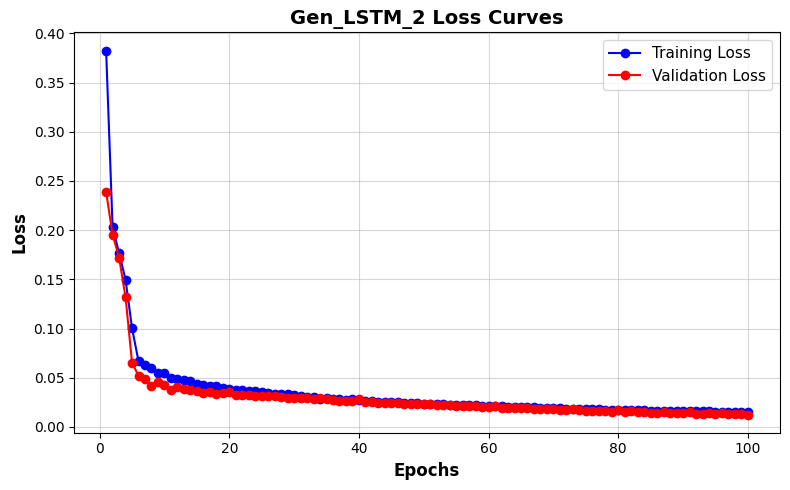

In [62]:
gen_LSTM_2_training_loss = gen_LSTM_2_history.history['loss']
gen_LSTM_2_val_loss = gen_LSTM_2_history.history['val_loss']
gen_LSTM_2_epochs = range(1, len(gen_LSTM_2_training_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(gen_LSTM_2_epochs, gen_LSTM_2_training_loss, 'bo-', label='Training Loss')
plt.plot(gen_LSTM_2_epochs, gen_LSTM_2_val_loss, 'ro-', label='Validation Loss')
plt.xlabel('Epochs', fontweight='bold', fontsize=12)
plt.ylabel('Loss', fontweight='bold', fontsize=12)
plt.title('Gen_LSTM_2 Loss Curves', fontweight='bold', fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.5)
plt.tight_layout()

plt.show()

Like in the case of LSTMs for `IT_load_new` the single-layer, baseline LSTM for `IT_solar_generation` underperformed the best XGBoost Regressor fitted for the same with RMSEs 784.73 and 522.94, respectively.

The second, stacked LSTM fitted for `IT_solar_generation` performed worse than the baseline model with an RMSE of 2743.69. A deeper architecture didn't capture more temporal patterns.

Still, like the LSTMs for `IT_load_new`, the loss curves for `IT_solar_generation` LSTMs converged despite producing a significant RMSE implying that there's underfitting.

**Therefore, XGBoost Regressors are also the best family of predictors for `IT_solar_generation`.**

---

<table style="margin-left:auto; margin-right:auto; margin-collapse:collapse;">
    <thead>
        <tr>
            <th colspan="4" style="text-align:center; color:orange; font-weight:bold; font-size:20px;">Summary of all LSTM Networks</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">Layers</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">Layer Details</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">Regularization / Training</td>
            <td style="text-align:center; color:red; font-style:italic; font-size:14;">RMSE on test set</td>
        </tr>
        <tr>
            <td colspan="4" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_load_new</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">1</td>
            <td style="text-align:center; color:green; font-size:14;">LSTM(32) → Dropout(0.2) → Dense(1)</td>
            <td style="text-align:center; color:green; font-size:14;">activation=relu, optimizer=Adam(0.001), SEQ_LENGTH=24, EarlyStopping(patience=5)</td>
            <td style="text-align:center; color:green; font-size:14;">1204.65</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">2</td>
            <td style="text-align:center; color:green; font-size:14;">LSTM(32, return_sequences=True) → Dropout(0.25) → LSTM(16) → Dropout(0.25) → Dense(1)</td>
            <td style="text-align:center; color:green; font-size:14;">kernel/recurrent L2=1e-4, optimizer=Adam(1e-4, clipnorm=1.0), SEQ_LENGTH=24, EarlyStopping</td>
            <td style="text-align:center; color:green; font-size:14;">2808.54</td>
        </tr>
        <tr>
            <td colspan="4" style="text-align:center; color:yellow; font-weight:bold; font-size:16px;">IT_solar_generation</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">1</td>
            <td style="text-align:center; color:green; font-size:14;">LSTM(32) → Dropout(0.2) → Dense(1)</td>
            <td style="text-align:center; color:green; font-size:14;">activation=relu, optimizer=Adam(0.001), SEQ_LENGTH=24, EarlyStopping(patience=5)</td>
            <td style="text-align:center; color:green; font-size:14;">784.73</td>
        </tr>
        <tr>
            <td style="text-align:center; color:green; font-size:14;">2</td>
            <td style="text-align:center; color:green; font-size:14;">LSTM(32, return_sequences=True) → Dropout(0.25) → LSTM(16) → Dropout(0.25) → Dense(1)</td>
            <td style="text-align:center; color:green; font-size:14;">kernel/recurrent L2=1e-4, optimizer=Adam(1e-4, clipnorm=1.0), SEQ_LENGTH=24, EarlyStopping</td>
            <td style="text-align:center; color:green; font-size:14;">2743.69</td>
        </tr>
    </tbody>
</table>

## __2. Weather Forecasting__

---

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### **A. Exploratory Data Analysis and Data Preprocessing**

---

In [24]:
# Loading the datset
# cities_df = pd.read_csv("/kaggle/input/global-daily-climate-data/cities.csv")
# countries_df = pd.read_csv("/kaggle/input/global-daily-climate-data/countries.csv")
weather_df = pd.read_parquet("/kaggle/input/global-daily-climate-data/daily_weather.parquet")

In [25]:
def get_city_weather_df(city_name: str):
    """
    Returns a subset of weather_df w.r.t.
    the city received.
    """
    city_weather_df = (
        weather_df
        .groupby('city_name', observed=False)
        .get_group(city_name)
        .copy()
    )
    
    return city_weather_df, city_name

In [26]:
city_weather_df, city_name = get_city_weather_df('London')

# Viewing city_weather_df
city_weather_df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,station_id,city_name,date,season,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
0,03772,London,1948-12-01,Winter,3.1,0.8,6.9,NaN,NaN,58.0,6.4,NaN,NaN,NaN
1,03772,London,1948-12-02,Winter,9.2,4.6,11.9,NaN,NaN,167.0,21.2,NaN,NaN,NaN
2,03772,London,1948-12-03,Winter,12.3,10.7,13.5,NaN,NaN,180.0,21.3,NaN,NaN,NaN
3,03772,London,1948-12-04,Winter,8.2,1.9,10.7,NaN,NaN,296.0,11.9,NaN,NaN,NaN
4,03772,London,1948-12-05,Winter,6.1,0.8,9.1,NaN,NaN,125.0,19.5,NaN,NaN,NaN


In [27]:
# Printing statistical summary of city_weather_df
city_weather_df.describe()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,date,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,snow_depth_mm,avg_wind_dir_deg,avg_wind_speed_kmh,peak_wind_gust_kmh,avg_sea_level_pres_hpa,sunshine_total_min
count,22189,22189.000000,21649.000000,21806.000000,15302.000000,275.000000,18491.000000,20713.000000,1786.000000,17669.000000,0.0
mean,1990-12-22 01:28:46.747487,11.108558,7.194457,15.070692,1.907489,37.458182,195.232870,14.315459,36.651904,1015.455504,NaN
min,1948-12-01 00:00:00,-7.400000,-12.000000,-6.100000,0.000000,0.000000,0.000000,0.000000,13.000000,959.600000,NaN
25%,1978-02-09 00:00:00,6.900000,3.000000,10.100000,0.000000,10.000000,119.000000,9.600000,25.900000,1009.100000,NaN
50%,1993-04-19 00:00:00,11.100000,7.300000,14.800000,0.000000,10.000000,218.000000,13.400000,33.300000,1016.400000,NaN
75%,2008-06-27 00:00:00,15.500000,11.500000,20.000000,1.800000,30.000000,263.000000,18.100000,46.000000,1022.600000,NaN
max,2023-09-04 00:00:00,29.800000,22.100000,40.200000,258.100000,2850.000000,360.000000,46.800000,113.000000,1047.700000,NaN
std,NaN,5.605479,5.352327,6.567507,5.763892,177.075990,96.945648,6.465473,14.785468,10.513820,NaN


In [28]:
# Getting dataset shape
number_of_records, number_of_features = city_weather_df.shape

print(f'\nDetails of weather dataset for {city_name}:')
print('-'*50)
print(f'Total number of data points: {number_of_records}')
print(f'Total number of features: {number_of_features}')
print('-'*50)

# Counting missing values
print('\nNull value count for each dataset column:')
print('-'*50)
for column in city_weather_df.columns:
    print(f"Total null values in '{column}': {city_weather_df[column].isnull().sum()}")
print('-'*50)


Details of weather dataset for London:
--------------------------------------------------
Total number of data points: 22189
Total number of features: 14
--------------------------------------------------

Null value count for each dataset column:
--------------------------------------------------
Total null values in 'station_id': 0
Total null values in 'city_name': 0
Total null values in 'date': 0
Total null values in 'season': 0
Total null values in 'avg_temp_c': 0
Total null values in 'min_temp_c': 540
Total null values in 'max_temp_c': 383
Total null values in 'precipitation_mm': 6887
Total null values in 'snow_depth_mm': 21914
Total null values in 'avg_wind_dir_deg': 3698
Total null values in 'avg_wind_speed_kmh': 1476
Total null values in 'peak_wind_gust_kmh': 20403
Total null values in 'avg_sea_level_pres_hpa': 4520
Total null values in 'sunshine_total_min': 22189
--------------------------------------------------


---

Initial inspection via `head()` and `describe()` revealed that while `city_weather_df` contains **22,189 daily observations** for London, the raw data presents three primary challenges:

1. _Extreme Column Sparsity:_ Features like `sunshine_total_min` (100% missing), `snow_depth_mm` (98.7% missing), and `peak_wind_gust_kmh` (92% missing) lack sufficient observations to be useful.
2. _Missing Sensor Measurements:_ Core physical variables (`precipitation_mm`, `avg_sea_level_pres_hpa`, `avg_wind_speed_kmh`) contain periodic gaps most likely due to sensor inavailability and missing logs.
3. _Temporal Ordering:_ Time-series models require strict chronological order and continuous time tracking to generate valid lag features and rolling window targets.

---

The following cleaning steps systematically resolve these issues to produce a continuous, fully populated dataset ready for sequence creation.

#### **Step 1: Chronological Sorting and datetime Indexing**

- _Functionality:_ Converts the `date` column into a Pandas `datetime64` object, sorts the DataFrame sequentially from the earliest (1948) to the latest (2023) record, and sets the `date` column as the index.

- _Necessity:_ Time-series models rely strictly on temporal order. If the records are out of order, time-based operations like lag feature generation, rolling averages, and sequence windowing will fail or produce data leakage. Setting an index on timestamps enables Pandas to perform time-aware operations (such as `.interpolate(method='time')`), which respect real calendar durations rather than simple row indices.

---

In [29]:
# Convert date column to datetime object, sort chronologically, and set as index
city_weather_df['date'] = pd.to_datetime(city_weather_df['date'])
city_weather_df = city_weather_df.sort_values('date').set_index('date')

---

#### **Step 2: Dropping Uninformative and Excessively Sparse Features**

- _Functionality:_ Removes non-predictive categorical identifiers (`station_id`, `city_name`, `season`) and columns with excessive sparsity (>90% missing values): `sunshine_total_min` (100% missing), `snow_depth_mm` (98.7% missing), and `peak_wind_gust_kmh` (92% missing).

- _Necessity:_ `station_id` and `city_name` are constants across a particular city subset and provide no predictive input whereas `season` can be derived dynamically from the calendar date. Also, filling columns where over 90% of the data is missing introduces artificial noise and bias, as the model would end up training mostly on calculated values rather than real-life observations.

---

In [30]:
# Dropping identifiers and columns with excessive sparsity
cols_to_drop = [
    'station_id', 'city_name', 'season',
    'sunshine_total_min', 'snow_depth_mm', 'peak_wind_gust_kmh'
]
city_weather_df = city_weather_df.drop(columns=cols_to_drop)

---

#### **Step 3: Time-Based Linear Interpolation for Continuous Variables**

- _Functionality_: Applies time-aware linear interpolation (`method='time'`) across continuous weather attributes (`avg_temp_c`, `min_temp_c`, `max_temp_c`, `precipitation_mm`, `avg_wind_speed_kmh`, and `avg_sea_level_pres_hpa`).

- _Necessity_: Short gaps (1–3 days) are best estimated by drawing a linear trajectory between adjacent recorded days, as weather is a **continuous** physical system. Using standard mean or median to fill in null values would create unphysical spikes or flatlines in the time series. Time-aware interpolation ensures that the gap calculation accounts for the actual time elapsed between valid entries.

---

In [31]:
# Interpolate short temporal gaps for continuous physical measurements
interpolated_cols = [
    'avg_temp_c', 'min_temp_c', 'max_temp_c', 
    'precipitation_mm', 'avg_wind_speed_kmh', 'avg_sea_level_pres_hpa'
]
city_weather_df[interpolated_cols] = city_weather_df[interpolated_cols].interpolate(
    method='time', limit_direction='both'
)

---

#### **Step 4: Directional Wind Degree Imputation (Forward/Backward Fill)**

- _Functionality:_ Fills missing entries in `avg_wind_dir_deg` using forward-fill (`ffill()`) followed by backward-fill (`bfill()`).

- _Necessity:_ Wind direction is an angle measured from 0° to 360°. For example, standard numeric interpolation between 350° (NNW) and 10° (NNE) yields 180° (South), which is physically incorrect as angle are cyclic quantities. `ffill()` looks backward in time to find the last valid reading to copy forward, thus filling gaps in the middle/bottom of the dataset. `bfill()` looks forward in time to find the next available valid reading and copies it backward to fill that initial missing day at the very beginning of the dataset. Combining `.ffill().bfill()` guarantees that every missing value gets filled, whether the gap is in the top/middle/bottom of the timeline.

---

In [32]:
# Forward fill followed by backward fill for cyclic wind direction degrees
city_weather_df['avg_wind_dir_deg'] = city_weather_df['avg_wind_dir_deg'].ffill().bfill()

---

#### **Step 5: Seasonal Historical Day-of-Year Backfilling for Early Gaps**

- _Functionality:_ Identifies any remaining missing values (such as leading missing values in early decades before specific sensors were installed) and fills them using the historical daily mean for that specific calendar day (e.g., the average value across all available years for January 15th).

- _Necessity:_ Linear interpolation cannot estimate values before the very first recorded sensor measurement in historical records (e.g., back in 1948). Filling these early missing blocks with the multi-year historical average for that specific day of the year preserves natural seasonal climate cycles (winter cold vs. summer heat) without leaving `NaN` values that would break downstream model training.

---

In [33]:
# Fill long leading historical NaNs using the multi-year historical mean for each specific day of the year
for col in city_weather_df.columns:
    if city_weather_df[col].isnull().sum() > 0:
        day_of_year_means = city_weather_df.groupby([city_weather_df.index.month, city_weather_df.index.day])[col].transform('mean')
        city_weather_df[col] = city_weather_df[col].fillna(day_of_year_means)

In [34]:
# Verify zero missing values remain across the entire dataset
print("\nRemaining null values per column:")
print('-'*50)
for column in city_weather_df.columns:
    print(f"{column}: {city_weather_df[column].isnull().sum()}")


Remaining null values per column:
--------------------------------------------------
avg_temp_c: 0
min_temp_c: 0
max_temp_c: 0
precipitation_mm: 0
avg_wind_dir_deg: 0
avg_wind_speed_kmh: 0
avg_sea_level_pres_hpa: 0


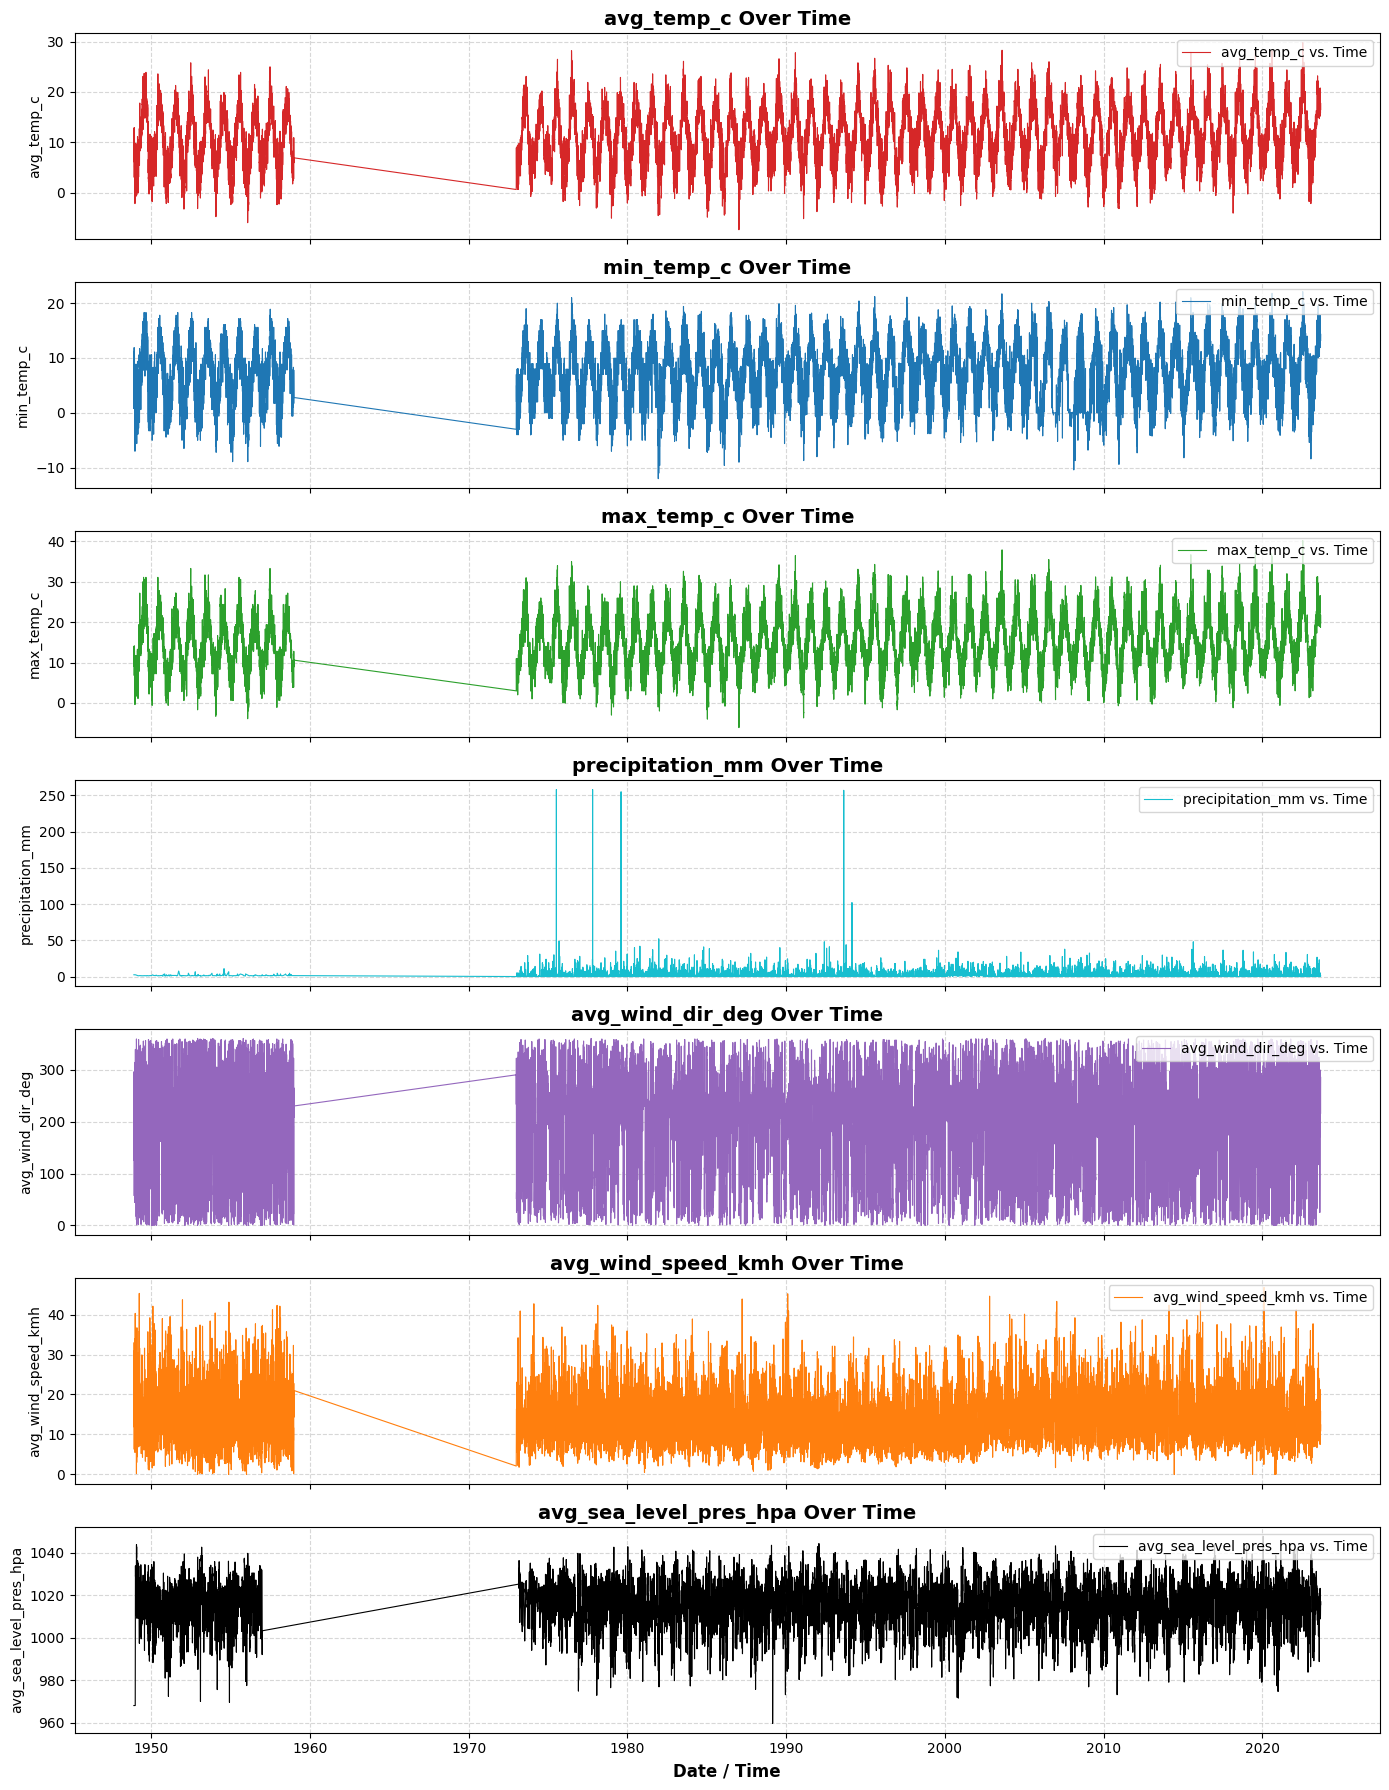

In [35]:
# Plotting the weather attributes across the timeline
fig, ax = plt.subplots(nrows=7, ncols=1, figsize=(14, 18), sharex=True)
weather_plot_colors = dict(
    zip(
        city_weather_df.columns,
        (
            'tab:red', 'tab:blue',
            'tab:green', 'tab:cyan',
            'tab:purple', 'tab:orange',
            'black'
        )
    )
)

for index, column in enumerate(city_weather_df.columns):
    ax[index].plot(
        city_weather_df.index,
        city_weather_df[column],
        label=f"{column} vs. Time",
        color=weather_plot_colors[column],
        linewidth=0.8
    )
    ax[index].set_ylabel(column, fontsize=10)
    ax[index].set_title(f'{column} Over Time', fontsize=14, fontweight='bold', loc='center')
    ax[index].grid(True, linestyle='--', alpha=0.5)
    ax[index].legend(loc='upper right')

plt.xlabel('Date / Time', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

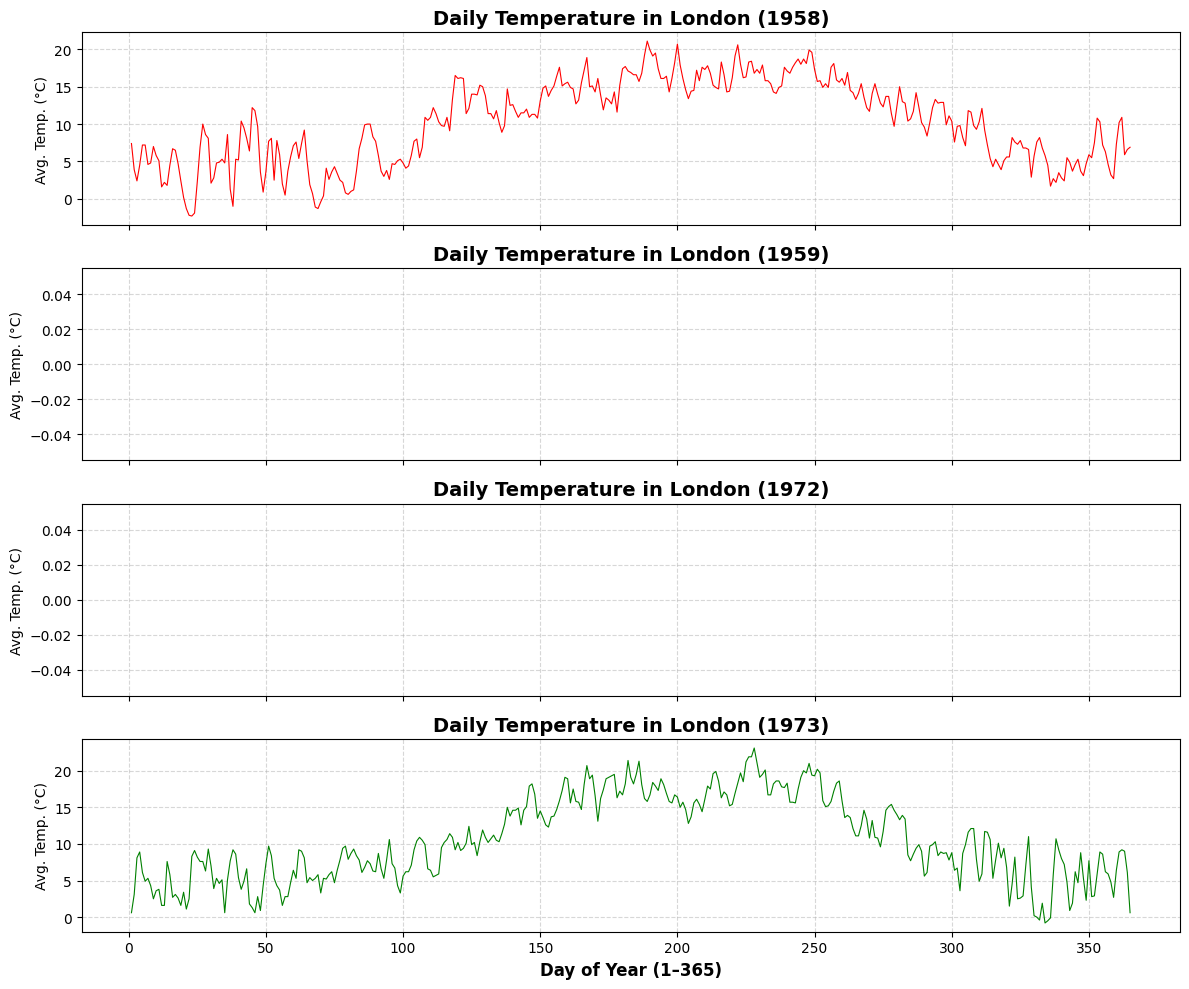

In [36]:
# Plotting specific years to inspect the data gap boundaries
fig, ax = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

years_to_plot = {
    '1958': 'r',
    '1959': 'r',
    '1972': 'g',
    '1973': 'g'
}

for index, year in enumerate(years_to_plot.keys()):
    data = city_weather_df.loc[year, 'avg_temp_c']
    ax[index].plot(
        data.index.dayofyear,
        data.values,
        color=years_to_plot[year],
        linewidth=0.8
    )
    ax[index].set_ylabel('Avg. Temp. (°C)', fontsize=10)
    ax[index].set_title(
        f'Daily Temperature in {city_name} ({year})',
        fontsize=14, fontweight='bold', loc='center'
    )
    ax[index].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('Day of Year (1–365)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

#### **Step 6: Dataset Truncation (Filtering Post-1973 Continuous Data)**

- _Functionality:_ Filters `city_weather_df` to keep only observations from **January 1, 1973 onwards**, dropping the early 1948–1959 segment and the ~14-year data gap that occurred between 1959 and 1973.

- _Necessity:_ Visual inspection of the time-series plots revealed a massive 14-year gap (1959–1973) where linear interpolation done previously created uncharacteristic flatlines across all features. Rather than feeding 5,000+ days of synthetic linear noise to the models, filtering post-1973 provides an unbroken and organic 50-year dataset (~18,000+ daily observations).

---

In [37]:
# Slice dataset to maintain continuous post-1973 sequence
city_weather_df = city_weather_df.loc['1973-01-01':].copy()

# Re-run interpolation to clean any minor day-to-day gaps in the modern era
city_weather_df[interpolated_cols] = city_weather_df[interpolated_cols].interpolate(
    method='time', limit_direction='both'
)

print(f"Cleaned dataset shape from 1973 onwards: {city_weather_df.shape}")

Cleaned dataset shape from 1973 onwards: (18506, 7)


Interquartile range, outlier count, and boxplot for avg_temp_c:
First quartile: 7.1
Third quartile: 15.6
Interquartile range: 8.5
Lower bound: -5.65
Upper bound: 28.35
Outlier count: 4



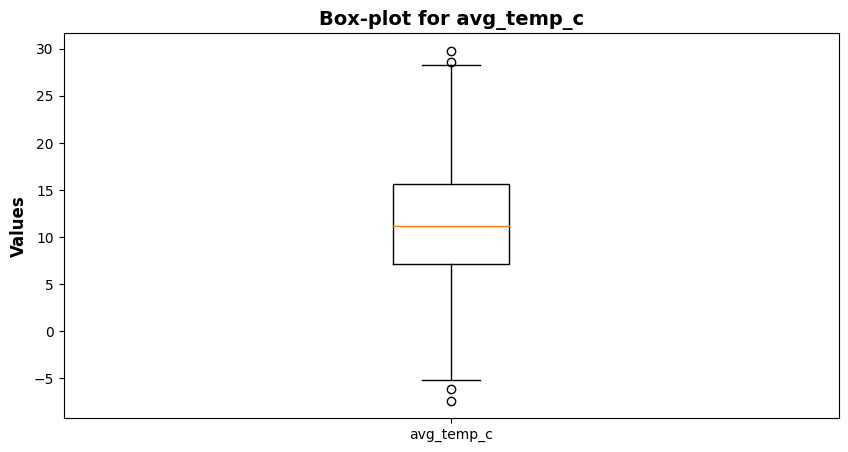


Interquartile range, outlier count, and boxplot for min_temp_c:
First quartile: 3.0
Third quartile: 11.6
Interquartile range: 8.6
Lower bound: -9.899999999999999
Upper bound: 24.5
Outlier count: 4



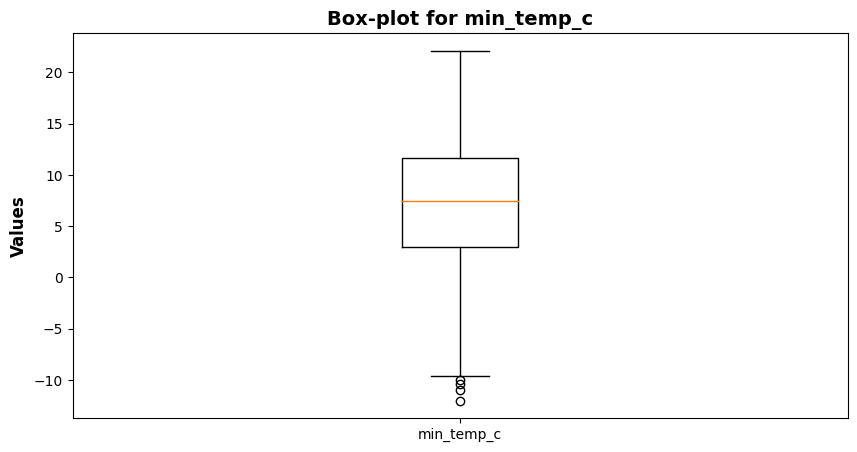


Interquartile range, outlier count, and boxplot for max_temp_c:
First quartile: 10.3
Third quartile: 20.1
Interquartile range: 9.8
Lower bound: -4.4
Upper bound: 34.800000000000004
Outlier count: 16



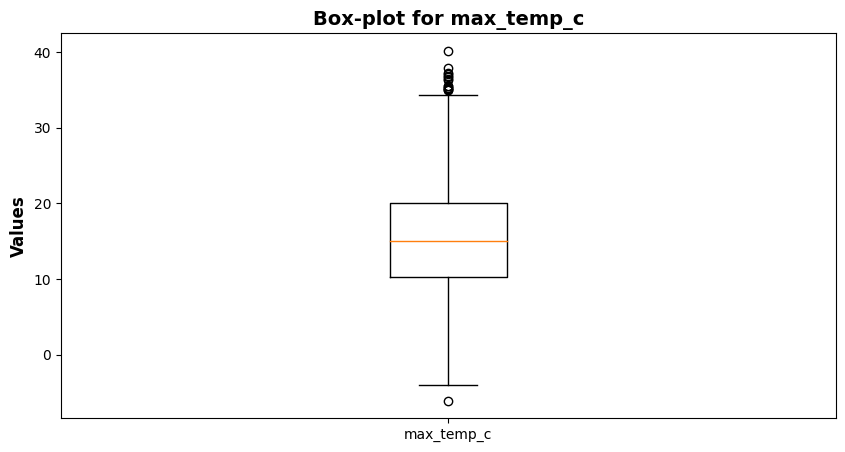


Interquartile range, outlier count, and boxplot for precipitation_mm:
First quartile: 0.0
Third quartile: 2.0
Interquartile range: 2.0
Lower bound: -3.0
Upper bound: 5.0
Outlier count: 2473



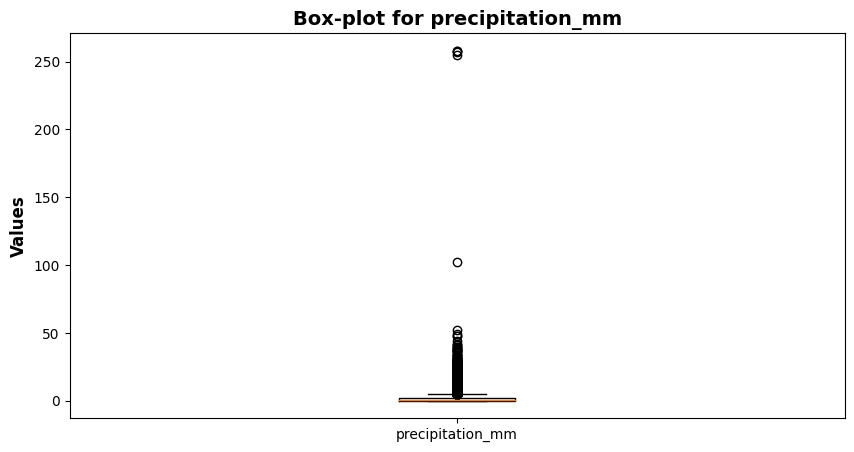


Interquartile range, outlier count, and boxplot for avg_wind_dir_deg:
First quartile: 121.25
Third quartile: 261.0
Interquartile range: 139.75
Lower bound: -88.375
Upper bound: 470.625
Outlier count: 0



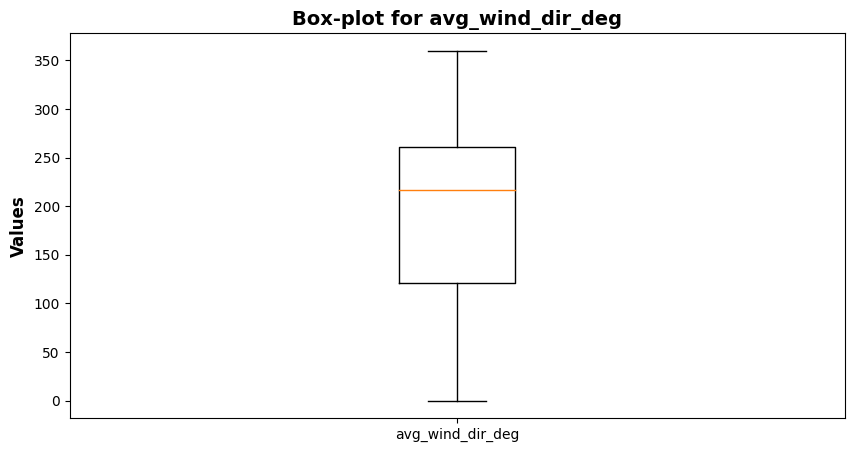


Interquartile range, outlier count, and boxplot for avg_wind_speed_kmh:
First quartile: 9.7
Third quartile: 17.6
Interquartile range: 7.900000000000002
Lower bound: -2.150000000000004
Upper bound: 29.450000000000003
Outlier count: 353



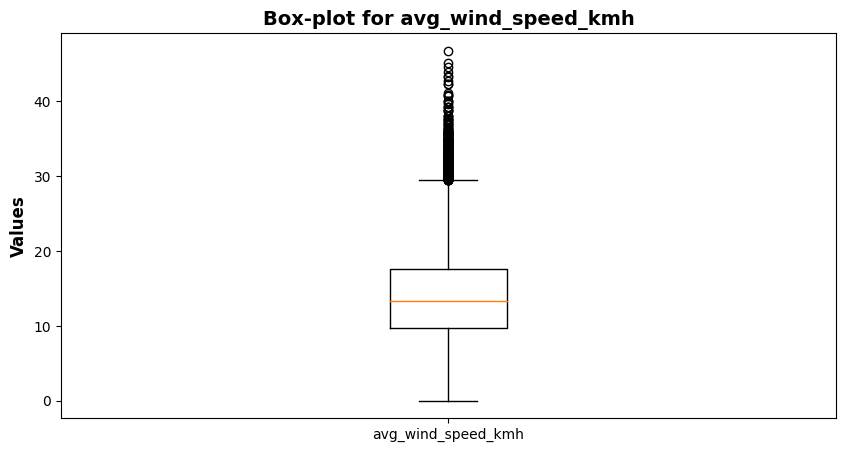


Interquartile range, outlier count, and boxplot for avg_sea_level_pres_hpa:
First quartile: 1009.5
Third quartile: 1022.4
Interquartile range: 12.899999999999977
Lower bound: 990.1500000000001
Upper bound: 1041.75
Outlier count: 310



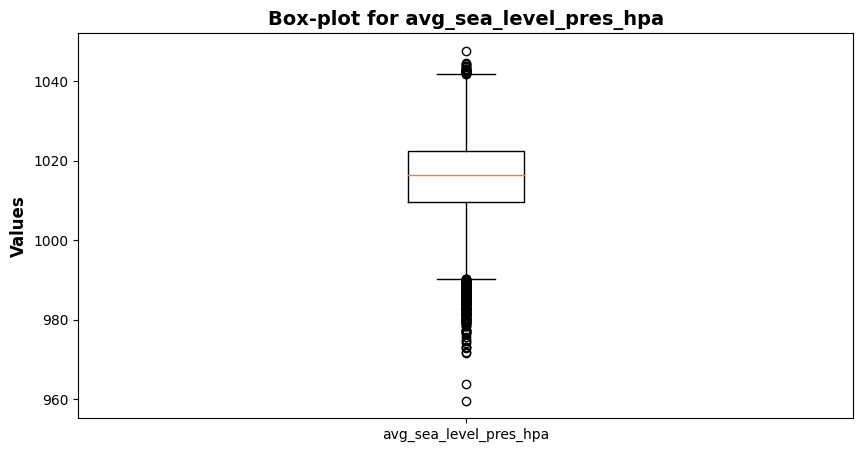

In [38]:
for column in city_weather_df.columns:
    print(f'Interquartile range, outlier count, and boxplot for {column}:')
    iqr_outliers(city_weather_df[column])
    generate_boxplot(city_weather_df[column], column)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


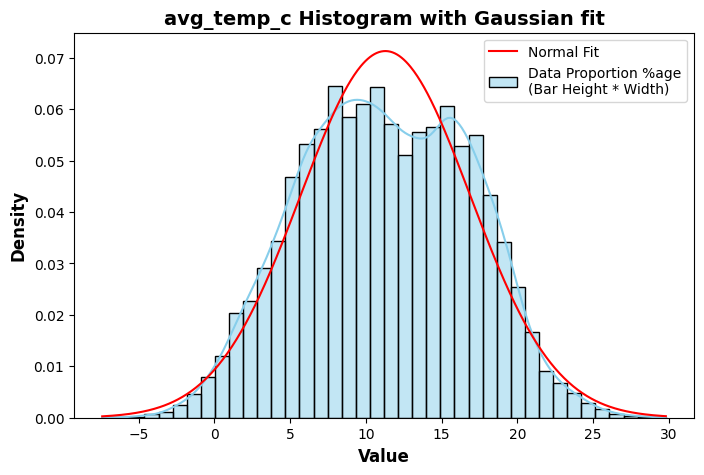

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


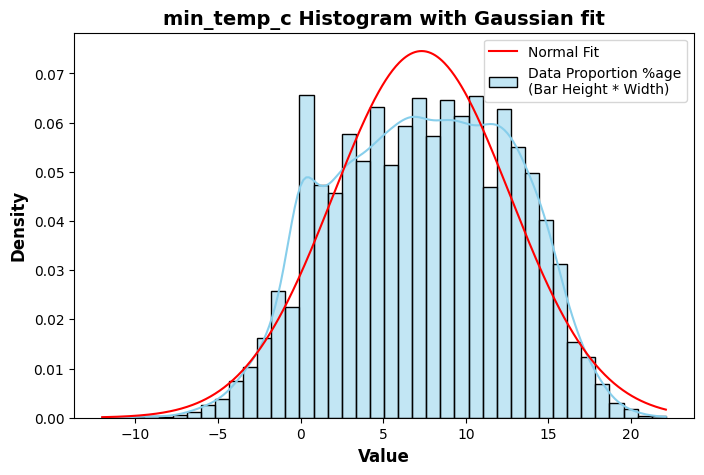

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


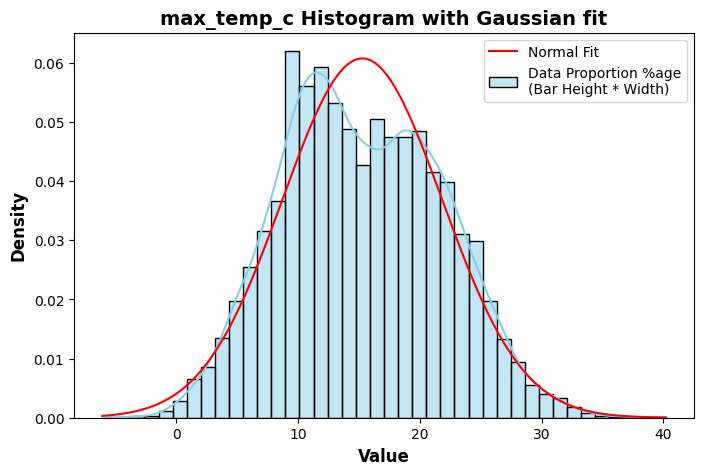

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


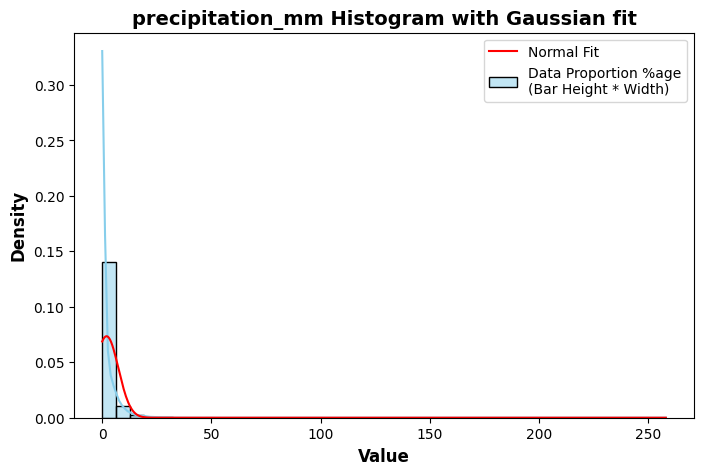

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


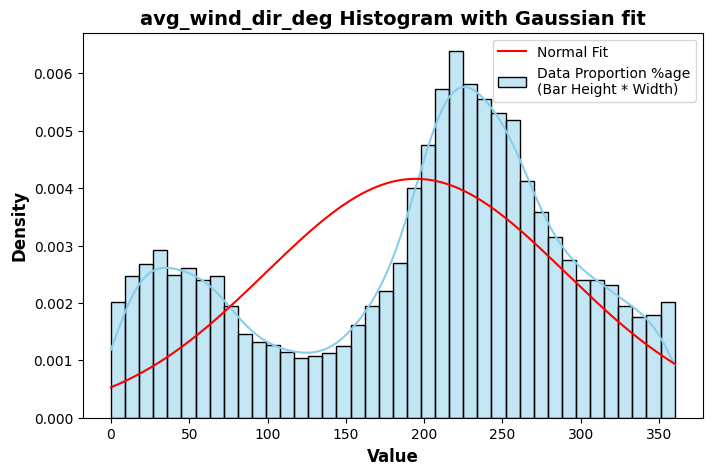

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


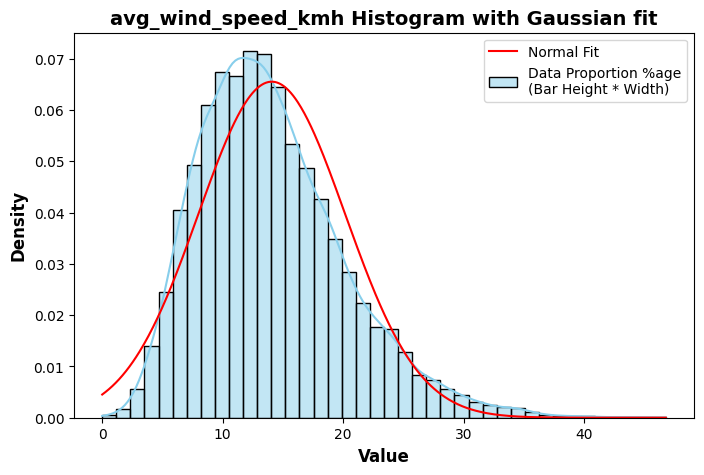

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


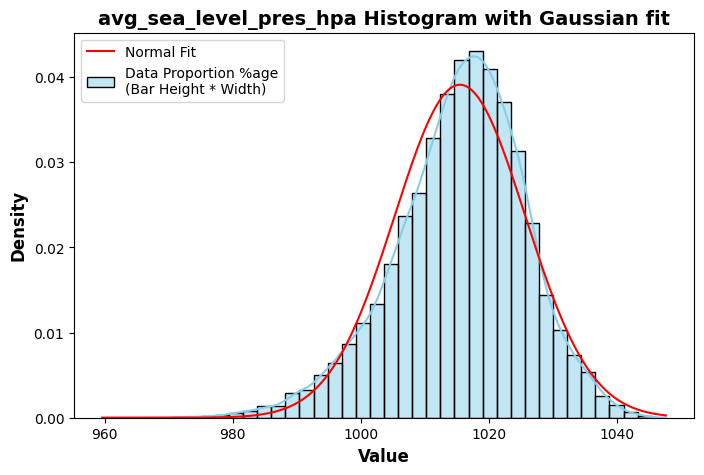

In [39]:
# Plotting histograms and Gaussian overlays for each column in city_weather_df
for column in city_weather_df.columns:
    plot_with_normal_fit(city_weather_df[column], column)

### **B. Feature Engineering**

---

As XGBRegressor was identified as the best family of predictors for energy forecasting, it will be selected as the baseline for weather forecasting to set performance benchmarks and for performing and evaluating experiments. SARIMA (or its vector equivalent VARMAX) isn't pursued here due to its inferiority and inherently higher complexity than XGBRegressor.

The dataset needs to be enhanced to support both gradient boosted trees (**XGBoost**) and sequence models (**LSTM**) for time-series forecasting. For that, we generate three new feature classes:
1. _Calendar Features:_ Integer values representing date components that capture temporal positions.
2. _Cyclical Encodings:_ Trigonometric transformations (sin / cos) that map repeating cycles (day of year, wind direction) into a continuous circular space.
3. _Temporal Dynamics (Lags & Rolling Statistics):_ Historical memory features constructed exclusively for tree-based models.

> Note: Scalers and sequence formatting for LSTMs will be applied later after training/test split to prevent data leakage.

> Note: Wind direction is given in angles because standard compass points (like N, NW, etc.) can't provide the required accuracy for direction.

---

#### **Step 1: Calendar Feature Extraction**

- _Functionality:_ Extracts calendar components (`month`, `day_of_year`, `day_of_week`, `quarter`) from the datetime index.

- _Necessity:_ Provides tree-based algorithms (XGBoost) with explicit decision boundaries to partition seasonal trends and day-of-week behaviors.

---

In [40]:
# Extracting calendar components from datetime index
city_weather_df['month'] = city_weather_df.index.month
city_weather_df['day_of_year'] = city_weather_df.index.dayofyear
city_weather_df['day_of_week'] = city_weather_df.index.dayofweek
city_weather_df['quarter'] = city_weather_df.index.quarter
city_weather_df['is_weekend'] = city_weather_df['day_of_week'].isin([5, 6]).astype(int)

# Binary flag for precipitation (addressing zero-inflation of rainfall from the histogram)
city_weather_df['is_raining'] = (city_weather_df['precipitation_mm'] > 0).astype(int)

---

#### **Step 2: Sine/Cosine Cyclical Encoding**

- _Functionality:_ Applies sine and cosine transformations to periodic variables (`day_of_year` and `avg_wind_dir_deg`).

- _Necessity:_ Calendar and angular features wrap around continuously (e.g., Dec 31 / Day 365 is adjacent to Jan 1 / Day 1). Simple integer values create logically inconsistent jumps at boundaries. Transforming these into 2D continuous space with trigonometric transformations allows models to perceive periodicity accurately.

---

In [41]:
# Day of year encoding (365.25 days accounting for leap years)
days_in_year = 365.25
city_weather_df['sin_day_of_year'] = np.sin(2 * np.pi * city_weather_df['day_of_year'] / days_in_year)
city_weather_df['cos_day_of_year'] = np.cos(2 * np.pi * city_weather_df['day_of_year'] / days_in_year)

# Month encoding (12 months)
city_weather_df['sin_month'] = np.sin(2 * np.pi * city_weather_df['month'] / 12)
city_weather_df['cos_month'] = np.cos(2 * np.pi * city_weather_df['month'] / 12)

# Wind direction angular encoding (0–360 degrees)
wind_rad = np.radians(city_weather_df['avg_wind_dir_deg'])
city_weather_df['sin_wind_dir'] = np.sin(wind_rad)
city_weather_df['cos_wind_dir'] = np.cos(wind_rad)

---

#### **Step 3: Lagged Features and Rolling Window Statistics (For Tree Models)**

- _Functionality:_ Generates time-shifted values (`t-1`, `t-2`, `t-7`) and moving averages (7-day rolling mean and standard deviation) for primary weather metrics (`avg_temp_c`, `avg_sea_level_pres_hpa`, `avg_wind_speed_kmh`).

- _Necessity:_ Gradient boosted trees (XGBoost) lack built-in temporal memory and treat rows as independent samples. Lagged values provide immediate momentum signals (like, if avg. temp was high yesterday, it'll be probably high today as well), while rolling statistics capture local trends and volatility of the current moving window.

> Note: NaNs created by shifting will be dropped prior to XGBoost training.*

---

In [42]:
target_cols = ['avg_temp_c', 'avg_sea_level_pres_hpa', 'avg_wind_speed_kmh']
lags = [1, 2, 7]

# Generating lagged features
for col in target_cols:
    for lag in lags:
        city_weather_df[f'{col}_lag_{lag}'] = city_weather_df[col].shift(lag)

# Generating 7-Day rolling statistics
# Shifting the data by 1 position removes the current day's value
# from the calculation by moving all rows down one timestep, ensuring
# the model only uses past information to predict future events.
# When predicting a target value for "Today" (Day T), a model must only
# see data from "Yesterday" (Day T-1) and further back.

# If rolling average is computed without shifting to predict the target for Day T,
# the feature already contains the exact answer the model is trying to predict.
# This is target leakage and the model will perform perfectly during training but
# will fail in production because the future target value will not be available.
for col in target_cols:
    city_weather_df[f'{col}_roll_mean_7d'] = city_weather_df[col].shift(1).rolling(window=7).mean()
    city_weather_df[f'{col}_roll_std_7d'] = city_weather_df[col].shift(1).rolling(window=7).std()

print(f"Dataset shape after feature engineering: {city_weather_df.shape}")

Dataset shape after feature engineering: (18506, 34)


In [43]:
# Inspecting the last few entries of the dataset to ensure
# all lagged and rolling features were computed properly
city_weather_df.tail()

,avg_temp_c,min_temp_c,max_temp_c,precipitation_mm,avg_wind_dir_deg,avg_wind_speed_kmh,avg_sea_level_pres_hpa,month,day_of_year,day_of_week,...,avg_sea_level_pres_hpa_lag_7,avg_wind_speed_kmh_lag_1,avg_wind_speed_kmh_lag_2,avg_wind_speed_kmh_lag_7,avg_temp_c_roll_mean_7d,avg_temp_c_roll_std_7d,avg_sea_level_pres_hpa_roll_mean_7d,avg_sea_level_pres_hpa_roll_std_7d,avg_wind_speed_kmh_roll_mean_7d,avg_wind_speed_kmh_roll_std_7d
date,,,,,,,,,,,,,,,,,,,,,
2023-08-31,15.8,13.0,18.7,1.0,224.0,13.2,1010.6,8,243,3,...,1012.3,12.3,11.2,8.3,16.742857,1.725164,1011.428571,2.212626,11.157143,1.731913
2023-09-01,17.2,14.3,20.1,1.0,215.0,15.9,1012.4,9,244,4,...,1009.9,13.2,12.3,12.1,16.100000,0.730297,1011.185714,2.194257,11.857143,1.327726
2023-09-02,17.8,14.4,21.8,1.0,242.0,10.8,1017.1,9,245,5,...,1008.8,15.9,13.2,13.1,16.085714,0.703393,1011.542857,2.153181,12.400000,2.033060
2023-09-03,17.2,14.2,20.5,1.0,282.0,11.4,1017.1,9,246,6,...,1011.5,10.8,15.9,11.8,16.457143,0.832380,1012.728571,2.624700,12.071429,2.086236
2023-09-04,16.5,13.2,19.8,1.0,285.0,12.4,1015.5,9,247,0,...,1015.5,11.4,10.8,9.3,16.700000,0.750555,1013.528571,3.012593,12.014286,2.100340


In [44]:
# Checking total NaNs present - should be upto 7 due to the
# NaNs at the top caused by the 7-day rolling window
columns_with_nan = []
print('-'*50)
print('Total NaN values in updated city_weather_df:')
print('-'*50)
for column in city_weather_df.columns:
    column_nan_count = city_weather_df[column].isna().sum()
    if column_nan_count > 0:
        columns_with_nan.append(column)
    print(f'In {column}: {column_nan_count}')
print('-'*50)

--------------------------------------------------
Total NaN values in updated city_weather_df:
--------------------------------------------------
In avg_temp_c: 0
In min_temp_c: 0
In max_temp_c: 0
In precipitation_mm: 0
In avg_wind_dir_deg: 0
In avg_wind_speed_kmh: 0
In avg_sea_level_pres_hpa: 0
In month: 0
In day_of_year: 0
In day_of_week: 0
In quarter: 0
In is_weekend: 0
In is_raining: 0
In sin_day_of_year: 0
In cos_day_of_year: 0
In sin_month: 0
In cos_month: 0
In sin_wind_dir: 0
In cos_wind_dir: 0
In avg_temp_c_lag_1: 1
In avg_temp_c_lag_2: 2
In avg_temp_c_lag_7: 7
In avg_sea_level_pres_hpa_lag_1: 1
In avg_sea_level_pres_hpa_lag_2: 2
In avg_sea_level_pres_hpa_lag_7: 7
In avg_wind_speed_kmh_lag_1: 1
In avg_wind_speed_kmh_lag_2: 2
In avg_wind_speed_kmh_lag_7: 7
In avg_temp_c_roll_mean_7d: 7
In avg_temp_c_roll_std_7d: 7
In avg_sea_level_pres_hpa_roll_mean_7d: 7
In avg_sea_level_pres_hpa_roll_std_7d: 7
In avg_wind_speed_kmh_roll_mean_7d: 7
In avg_wind_speed_kmh_roll_std_7d: 7
--------

In [45]:
# Dropping rows with NaNs
city_weather_df.dropna(subset=columns_with_nan, inplace=True)

print(f"Dataset shape after dropping rows with NaNs: {city_weather_df.shape}")

Dataset shape after dropping rows with NaNs: (18499, 34)


In [46]:
# print('-'*50)
# print('Total NaN values in city_weather_df after dropping rows with NaN:')
# print('-'*50)
# for column in city_weather_df.columns:
#     column_nan_count = city_weather_df[column].isna().sum()
#     print(f'In {column}: {column_nan_count}')
# print('-'*50)

### **C. Chronological Dataset Splits**

---

Now we split the dataset into training, validation, and test sets using temporal cutoffs. Like in the case of energy forecasting, shuffling (`shuffle=True`) causes data leakage so it should be avoided. Preserving chronological ordering ensures that models are evaluated on unseen future data. As a better approach this time, a manual temporal split will be done instead of doing a percentage split as it guarantees complete calendar years in test evaluations.

---

In [47]:
# ~95% for training split (1973–2020), ~5% for test split (2021–2023)
city_weather_train_df = city_weather_df.loc[:'2020-12-31']
city_weather_test_df  = city_weather_df.loc['2021-01-01':]

print(f"Training split: {city_weather_train_df.index.min().strftime('%Y-%m-%d')} to {city_weather_train_df.index.max().strftime('%Y-%m-%d')} | Rows: {len(city_weather_train_df)}")
print(f"Test split:   {city_weather_test_df.index.min().strftime('%Y-%m-%d')} to {city_weather_test_df.index.max().strftime('%Y-%m-%d')} | Rows: {len(city_weather_test_df)}")

Training split: 1973-01-08 to 2020-12-31 | Rows: 17522
Test split:   2021-01-01 to 2023-09-04 | Rows: 977


In [48]:
# Defining feature and target columns for training and test sets
target_cols = ['avg_temp_c', 'min_temp_c', 'max_temp_c', 'avg_sea_level_pres_hpa', 'avg_wind_speed_kmh']
city_weather_X_train = city_weather_train_df.drop(columns=target_cols)
city_weather_y_train = city_weather_train_df[target_cols]

city_weather_X_test = city_weather_test_df.drop(columns=target_cols)
city_weather_y_test = city_weather_test_df[target_cols]

# Checking dataset splits' shapes
print(f"city_weather_X_train shape: {city_weather_X_train.shape} | city_weather_y_train shape: {city_weather_y_train.shape}")
print(f"city_weather_X_test shape:  {city_weather_X_test.shape}  | city_weather_y_test shape:  {city_weather_y_test.shape}")

city_weather_X_train shape: (17522, 29) | city_weather_y_train shape: (17522, 5)
city_weather_X_test shape:  (977, 29)  | city_weather_y_test shape:  (977, 5)


### **D. Fitting XGBoost**

---

In [49]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

city_weather_xgbr_1 = XGBRegressor(
    n_estimators=100, # Sufficient estimators for baseline
    max_depth=5, # Moderate depth for baseline
    learning_rate=0.05, # Low learning rate for baseline
    random_state=42, # For reproducibility
    tree_method='hist'
)
# Setting tree_method='hist' in XGBRegressor tells XGBoost
# to use a fast histogram-optimized algorithm. It groups
# continuous feature values into discrete bins before training.
# This speeds up training time significantly and reduces
# memory usage, especially for large datasets.

city_weather_xgbr_1.fit(city_weather_X_train, city_weather_y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=5, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [50]:
def get_city_weather_xgbr_metrics(xgbr_preds: np.ndarray):
    """
    Computes and returns the performance
    metrics of an XGBRegressor fitted on
    city_weather_df.
    """    
    # Evaluate performance per target
    xgbr_metrics = []
    for index, column in enumerate(target_cols):
        rmse = np.sqrt(
            mean_squared_error(
                city_weather_y_test[column],
                xgbr_preds[:, index]
            )
        )
        mae = mean_absolute_error(
            city_weather_y_test[column],
            xgbr_preds[:, index]
        )
        r2 = r2_score(
            city_weather_y_test[column],
            xgbr_preds[:, index]
        )
        xgbr_metrics.append(
            {
                'Target': column,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            }
        )

    return xgbr_metrics

In [51]:
# Making predictions on test set
city_weather_preds_xgbr_1 = city_weather_xgbr_1.predict(city_weather_X_test)

# Getting model performance metrics
city_weather_xgbr_1_metrics = get_city_weather_xgbr_metrics(city_weather_preds_xgbr_1)
city_weather_xgbr_1_metrics_df = pd.DataFrame(city_weather_xgbr_1_metrics)
print(city_weather_xgbr_1_metrics_df)

                   Target      RMSE       MAE        R2
0              avg_temp_c  1.884559  1.506983  0.891953
1              min_temp_c  2.136699  1.720765  0.846916
2              max_temp_c  2.236713  1.778926  0.890724
3  avg_sea_level_pres_hpa  6.987286  5.824265  0.532971
4      avg_wind_speed_kmh  4.437043  3.507666  0.462386


In [52]:
def plot_city_weather_xgbr_preds(xgbr_preds: np.ndarray, preds_name: str):
    """
    Plots the values predicted by a
    XGBRegressor on city_weather_y_test.
    """
    fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(15, 10))
    plot_colors = dict(
        zip(
            target_cols,
            ('r', 'y', 'g', 'c', 'm')
        )
    )

    for index, column in enumerate(target_cols):
        ax[index].plot(
            city_weather_y_test.index,
            city_weather_y_test[column],
            label='True values',
            color='k',
            linewidth=0.8
        )
        ax[index].plot(
            city_weather_y_test.index,
            xgbr_preds[:, index],
            label='Predictions',
            color=plot_colors[column],
            linewidth=0.8
        )
        ax[index].set_xlabel('Timestamps', fontweight='bold', fontsize=12)
        ax[index].set_title(f'{column} vs. Time', fontsize=14, fontweight='bold', loc='center')
        ax[index].grid(True, linestyle='--', alpha=0.5)
        ax[index].legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(f'{preds_name}_true_vs_preds.png', dpi=500, bbox_inches='tight')
    plt.show()

Plotting the predictions of city_weather_XGBR_1 against city_weather_y_test:



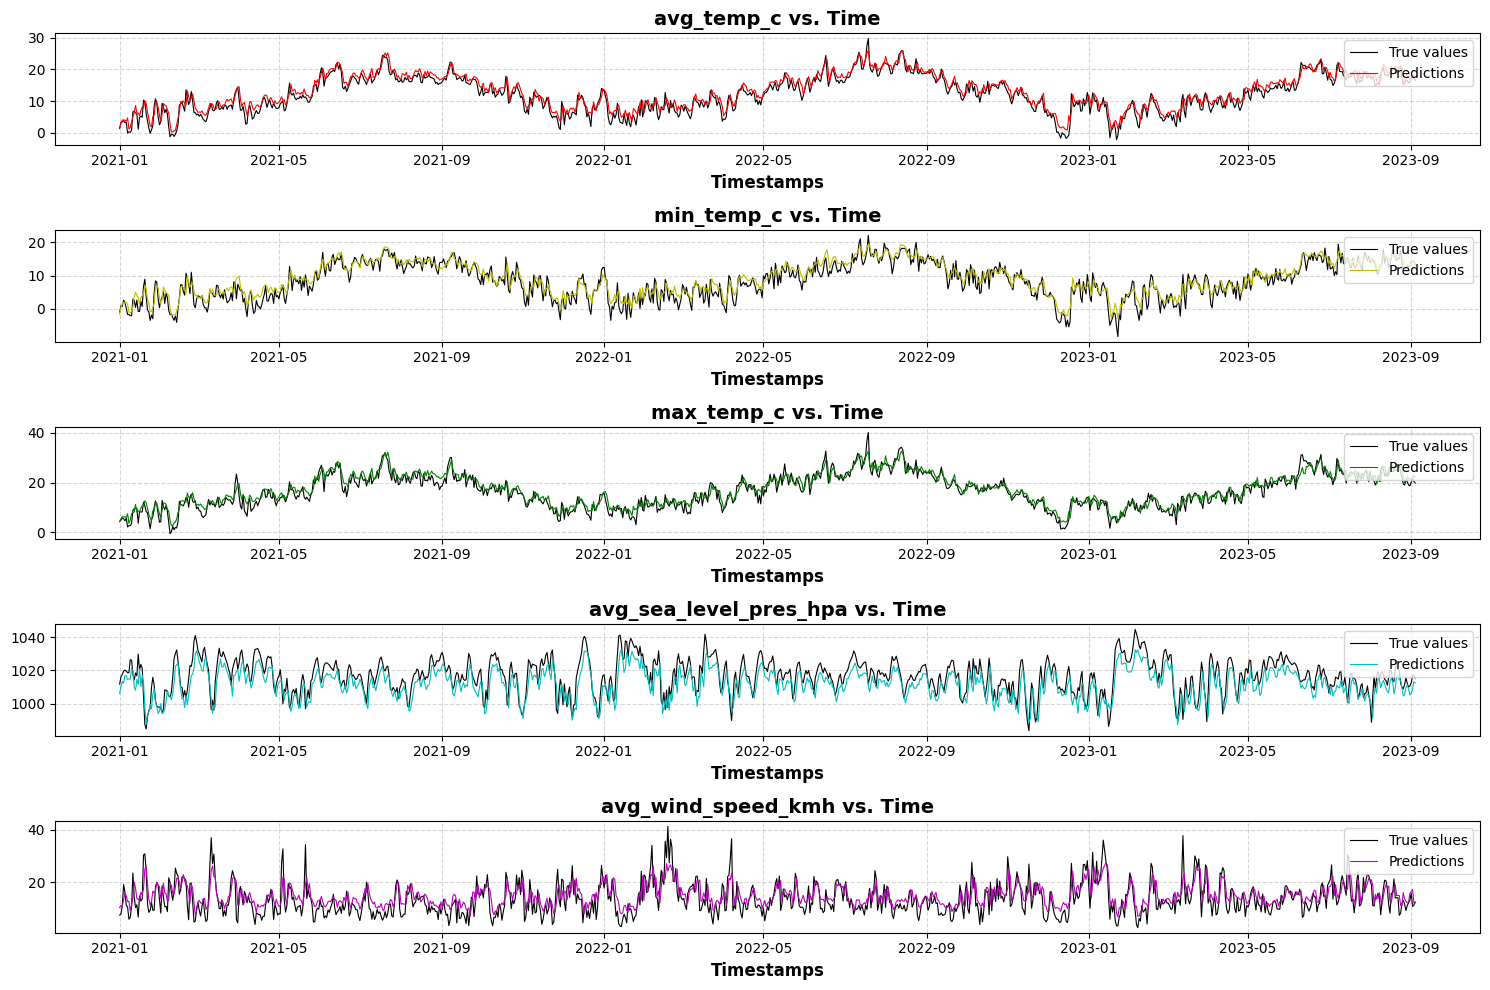

In [53]:
print("="*50)
print("Plotting the predictions of city_weather_XGBR_1 against city_weather_y_test:\n")
plot_city_weather_xgbr_preds(
    city_weather_preds_xgbr_1, 'city_weather_preds_xgbr_1'
)
print("="*50)

In [54]:
def plot_city_weather_model_metrics(metrics_df: pd.DataFrame, model_name: str):
    """
    Plots a bar chart of RMSE and MAE for
    each target variable in city_weather_df.
    """
    # Local copy to avoid mutating
    metrics_df_copy = metrics_df.copy()
    
    # Setting target column as index to use column names as x-labels
    metrics_df_copy.set_index('Target', inplace=True)

    # It's good practice to directly use the axes objects
    # as they are the actual 'canvas' where plotting is
    # done, fig is the window
    fig, ax = plt.subplots(figsize=(10, 6))
    
    metrics_df_copy[['RMSE', 'MAE', 'R2']].plot(
        kind='bar', ax=ax, width=0.5, color=['r', 'g', 'b'], linewidth=0.6
    )
    
    # Annotate bar heights
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=8, fontweight='bold')
    
    ax.set_title(f'RMSE, MAE, and R2 score for {model_name} on test set', fontsize=14, fontweight='bold')
    ax.set_xlabel('Target Variables', fontsize=12, fontweight='bold')
    ax.set_ylabel('Error Value', fontsize=12, fontweight='bold')
    
    plt.xticks(rotation=0, fontsize=10, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig(f'{model_name}_metrics_bargraph', dpi=500, bbox_inches='tight')
    plt.show()

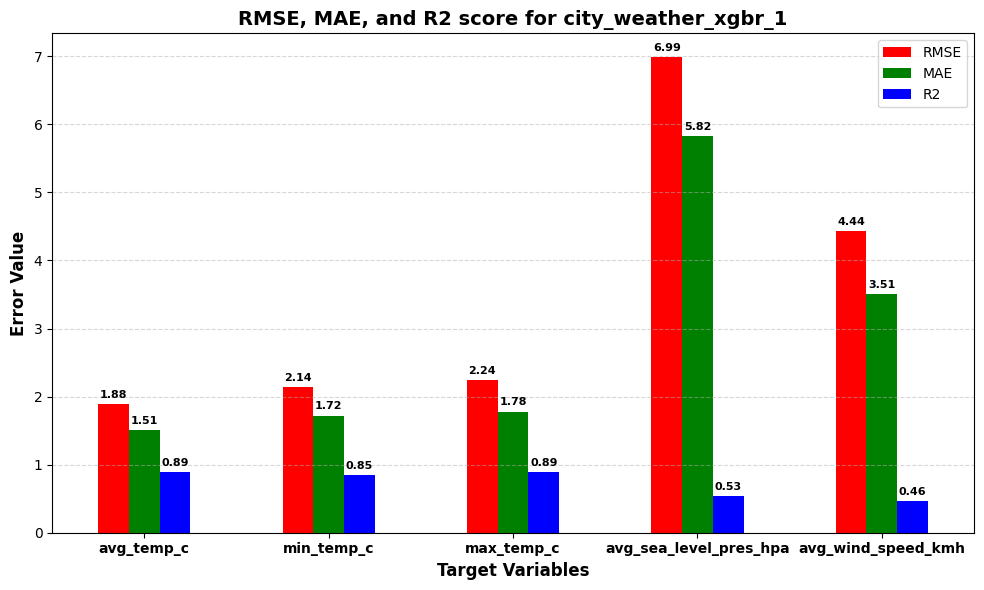

In [55]:
plot_city_weather_model_metrics(city_weather_xgbr_1_metrics_df, 'city_weather_xgbr_1')

In [56]:
# Attempting grid search to check for
# a better fit than city_weather_xgbr_1
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer

xgbr_param_grid_2 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1]
}

# Used a regular function instead of
# lambda to prevent pickling error
def multioutput_rmse(y_true, y_pred):
    return np.mean(
        np.sqrt(
            mean_squared_error(
                y_true, y_pred, 
                multioutput='raw_values'
            )
        )
    )
# Extra mean is needed to average all the
# RMSEs of individual columns to get a
# unified RMSE metric to optimize on

rmse_scorer_2 = make_scorer(
    multioutput_rmse,
    greater_is_better=False
)

tscv = TimeSeriesSplit(n_splits=3)

city_weather_xgbr_2 = XGBRegressor(
    tree_method='hist',
    random_state=42
)

city_weather_xgbr_grid_search = GridSearchCV(
    city_weather_xgbr_2,
    xgbr_param_grid_2,
    scoring={
        'rmse': rmse_scorer_2,
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2',
    },
    refit='rmse',
    cv=tscv,
    n_jobs=-1
)
city_weather_xgbr_grid_search.fit(city_weather_X_train, city_weather_y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, imp...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=42, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [4, 6, 8],
                         'n_estimators': [100, 200, 300]},
             refit='rmse',
             scoring={'mae': 'neg_mean_absolute_error', 'r2': 'r2',
                      'rmse': make_scorer(multioutput_rmse, greater_is_better=False)})

In [57]:
print('-'*50)
print(f'Best results from grid search with XGBoost for city_weather_df:')
print(f'Best parameters: {city_weather_xgbr_grid_search.best_params_}')
print('-'*50)

--------------------------------------------------
Best results from grid search with XGBoost for city_weather_df:
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
--------------------------------------------------


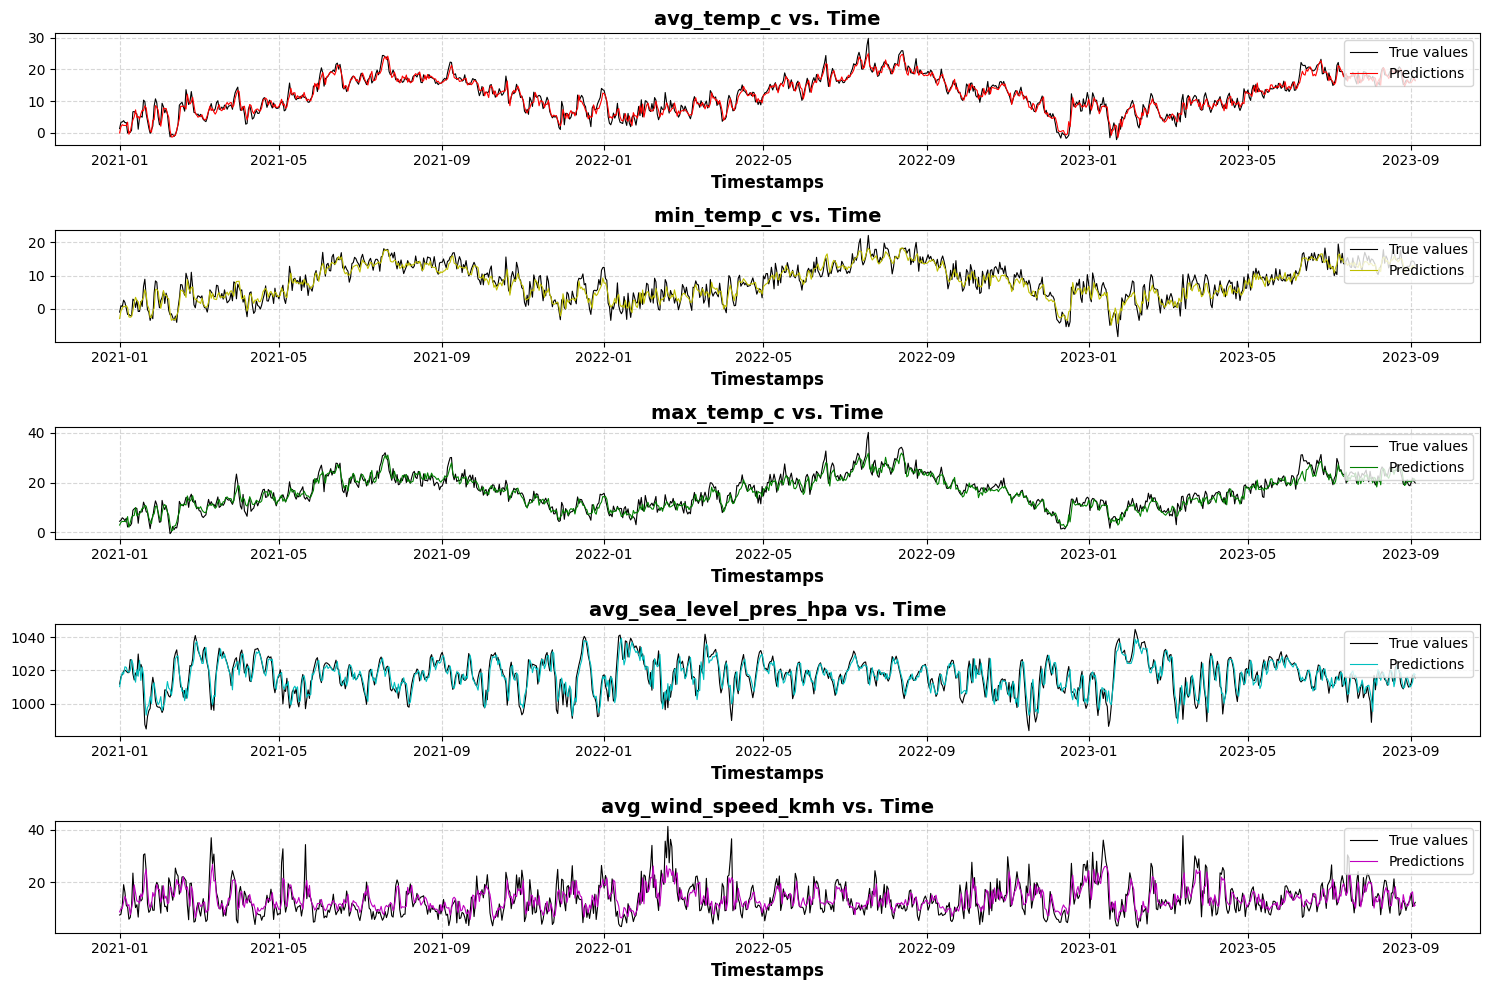

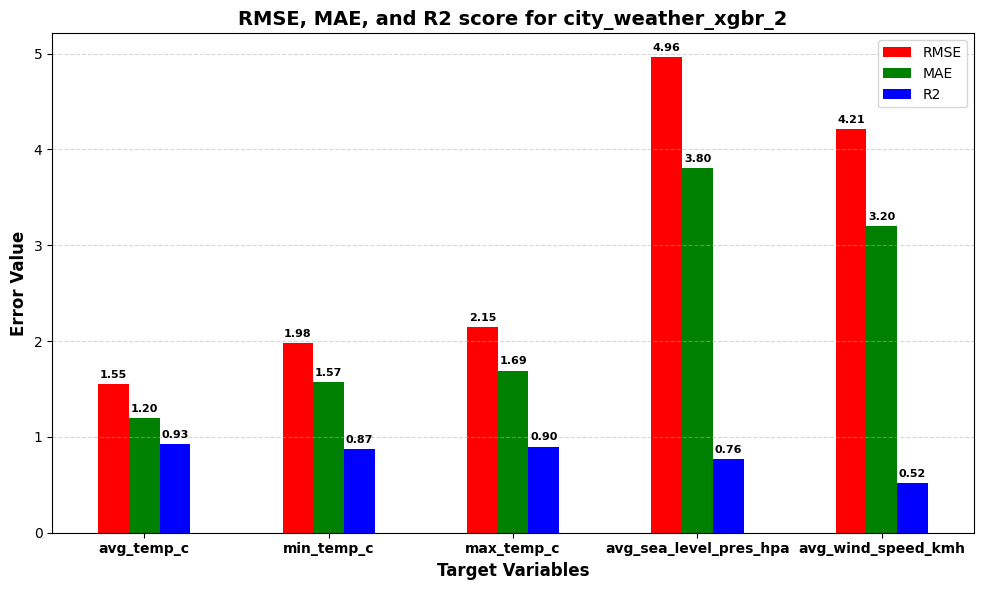

In [58]:
# Using the best predictor from grid search
# to make predictions and calculate metrics
city_weather_preds_xgbr_2 = (
    city_weather_xgbr_grid_search
    .best_estimator_
    .predict(city_weather_X_test)
)

city_weather_xgbr_2_metrics = get_city_weather_xgbr_metrics(
    city_weather_preds_xgbr_2
)
city_weather_xgbr_2_metrics_df = pd.DataFrame(
    city_weather_xgbr_2_metrics
)

print("="*50)
plot_city_weather_xgbr_preds(
    city_weather_preds_xgbr_2,
    'city_weather_preds_xgbr_2'
)
print('\n', '='*50, '\n')
plot_city_weather_model_metrics(
    city_weather_xgbr_2_metrics_df,
    'city_weather_xgbr_2'
)
print("="*50)

---

Grid search yielded identical results to the baseline model, confirming that XGBoost has reached its performance ceiling on this dataset. While the model reliably predicts daily temperatures, it struggles to capture shifts in barometric pressure and wind speed. This highlights the structural limitations of standard tree-based models and justifies transitioning to LSTMs.

---

### **E. Fitting LSTMs**

---

In [59]:
# ---- For city_weather_X_train and city_weather_y_train ----
weather_lstm_X_train = city_weather_X_train.copy()
weather_lstm_X_test = city_weather_X_test.copy() # Copies to prevent mutation

# Defining feature columns for LSTMs
weather_lstm_features = [
    'precipitation_mm', 'is_weekend',
    'is_raining', 'sin_day_of_year',
    'cos_day_of_year', 'sin_month',
    'cos_month', 'sin_wind_dir',
    'cos_wind_dir'
]

# Filter feature sets
weather_lstm_X_train = weather_lstm_X_train[weather_lstm_features]
weather_lstm_X_test = weather_lstm_X_test[weather_lstm_features]

print('-'*50)
print(f'Original X_train features: {city_weather_X_train.shape[1]}')
print(f'Filtered LSTM features:   {weather_lstm_X_train.shape[1]}')
print('-'*50)

--------------------------------------------------
Original X_train features: 29
Filtered LSTM features:   9
--------------------------------------------------


In [60]:
# Concatenate targets + exogenous features for complete LSTM input
weather_lstm_X_train = pd.concat([city_weather_y_train, weather_lstm_X_train], axis=1)
weather_lstm_X_test = pd.concat([city_weather_y_test, weather_lstm_X_test], axis=1)

print('-'*50)
print(f'Total features entering LSTM sequence generator: {weather_lstm_X_train.shape[1]}')
print('-'*50)

--------------------------------------------------
Total features entering LSTM sequence generator: 14
--------------------------------------------------


In [61]:
from sklearn.preprocessing import MinMaxScaler

weather_X_scaler = MinMaxScaler()
weather_y_scaler = MinMaxScaler()

# Fitting and transforming on training split only
weather_lstm_X_train_scaled = weather_X_scaler.fit_transform(weather_lstm_X_train)
weather_lstm_X_test_scaled = weather_X_scaler.transform(weather_lstm_X_test)

weather_lstm_y_train_scaled = weather_y_scaler.fit_transform(city_weather_y_train)
weather_lstm_y_test_scaled = weather_y_scaler.transform(city_weather_y_test)

# Sliding window sequence generation (lookback - 10, horizon - 4)
def create_sequences_2(data_X, data_y, lookback=10, horizon=4):
    """
    Creates input/output sequences
    for weather forecasting.
    """
    X_seq, y_seq = [], []
    for i in range(len(data_X) - lookback - horizon + 1):
        X_seq.append(data_X[i : i + lookback, :])
        y_seq.append(data_y[i + lookback : i + lookback + horizon, :])
    return np.array(X_seq), np.array(y_seq)

LOOKBACK = 10
HORIZON = 4

# Generate 3D sequence tensors
weather_X_train_seq, weather_y_train_seq = create_sequences_2(
    weather_lstm_X_train_scaled,
    weather_lstm_y_train_scaled,
    LOOKBACK, HORIZON
)
weather_X_test_seq, weather_y_test_seq = create_sequences_2(
    weather_lstm_X_test_scaled,
    weather_lstm_y_test_scaled,
    LOOKBACK, HORIZON
)

print('-'*50)
print(f'weather_X_train_seq shape: {weather_X_train_seq.shape}')
# (number_of_samples, 10 - length, 14 - features)

print(f'weather_y_train_seq shape: {weather_y_train_seq.shape}')
# (number_of_samples, 4 - length, 5 - targets)
print('-'*50)

--------------------------------------------------
weather_X_train_seq shape: (17509, 10, 14)
weather_y_train_seq shape: (17509, 4, 5)
--------------------------------------------------


In [104]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout,
    RepeatVector, TimeDistributed
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import RootMeanSquaredError, R2Score


# Building a baseline LSTM for weather forecasting
weather_lstm_1 = Sequential([
    # Encoder: Processes the 10-day, 14-feature input sequence
    Input(shape=(LOOKBACK, weather_X_train_seq.shape[2])),
    LSTM(64, return_sequences=False),
    # return_sequences had to be set to False due to length
    # mismatch of input/output sequences, else the mismatch
    # will raise an error. Setting it false creates a
    # (batch_size, 64) "summary" vector at the end of the
    # encoder.
    Dropout(0.2),
    
    # Bridge: Again, due to difference in lengths of input
    # and output sequence length, the "summary" from the
    # encoder is taken by RepeatVector and repeated as many
    # times as is the length of the output sequence, else
    # an error will raise. It's safe to pass the same encoder
    # output to all the decoder time steps, but it's a
    # quick fix only.
    RepeatVector(HORIZON),
    
    # Decoder: Generates sequence across the 4 future days
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    
    # Output Layer: TimeDistributed with Dense layer applies
    # the same dense layer to all decoder time steps to
    # ensure that each time step gets an independent
    # prediction. Without it, the dense layer flattens
    # predictions of all features over all time steps into
    # one massive vector, losing the temporal structure.
    TimeDistributed(Dense(weather_y_train_seq.shape[2]))
    
])

weather_lstm_1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=[
        'mae',
        RootMeanSquaredError(name='rmse')
    ]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

weather_lstm_1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 4, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 4, 5)           │           165 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,805 (128.14 KB)

 Trainable params: 32,805 (128.14 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Fit weather_lstm_1
weather_lstm_1_history = weather_lstm_1.fit(
    weather_X_train_seq,
    weather_y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0428 - mae: 0.1525 - rmse: 0.1972 - val_loss: 0.0102 - val_mae: 0.0771 - val_rmse: 0.1011
Epoch 2/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0127 - mae: 0.0883 - rmse: 0.1127 - val_loss: 0.0097 - val_mae: 0.0753 - val_rmse: 0.0984
Epoch 3/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0112 - mae: 0.0827 - rmse: 0.1059 - val_loss: 0.0091 - val_mae: 0.0724 - val_rmse: 0.0953
Epoch 4/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0103 - mae: 0.0790 - rmse: 0.1016 - val_loss: 0.0091 - val_mae: 0.0728 - val_rmse: 0.0955
Epoch 5/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0096 - mae: 0.0760 - rmse: 0.0981 - val_loss: 0.0087 - val_mae: 0.0712 - val_rmse: 0.0934
Epoch 6/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0091 - mae: 0.0737 - rmse: 0.0954 - val_loss: 0.0085 - val_mae: 0.0701 - val_rmse: 0.0923
Epoch 7/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0087 - mae: 0.0719 - rmse:

In [106]:
# Make predictions on test set
weather_lstm_preds_1_scaled = weather_lstm_1.predict(weather_X_test_seq)

# Reshaping to 2D to apply inverse_transform
n_samples, horizon, n_targets = weather_lstm_preds_1_scaled.shape
weather_lstm_preds_1_reshaped = weather_lstm_preds_1_scaled.reshape(-1, n_targets)
weather_y_test_seq_reshaped = weather_y_test_seq.reshape(-1, n_targets)

# Transform back to original scale
weather_lstm_preds_1_original = weather_y_scaler.inverse_transform(weather_lstm_preds_1_reshaped)
weather_y_test_seq_original = weather_y_scaler.inverse_transform(weather_y_test_seq_reshaped)

# Reshape back to 3D (n_samples, 4, 5)
weather_lstm_preds_1_final = weather_lstm_preds_1_original.reshape(n_samples, horizon, n_targets)
weather_y_test_seq_final = weather_y_test_seq_original.reshape(n_samples, horizon, n_targets)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [128]:
def get_city_weather_lstm_metrics(preds_2d_original: np.ndarray, y_2d_original: np.ndarray):
    """
    Computes and returns performance metrics (RMSE, MAE, R2)
    for an LSTM evaluated on the test set in original scale.
    """    
    lstm_metrics = []
    target_cols = tuple(city_weather_y_train.columns)
    
    for index, column in enumerate(target_cols):
        rmse = np.sqrt(
            mean_squared_error(
                y_2d_original[:, index],
                preds_2d_original[:, index]
            )
        )
        mae = mean_absolute_error(
            y_2d_original[:, index],
            preds_2d_original[:, index]
        )
        r2 = r2_score(
            y_2d_original[:, index],
            preds_2d_original[:, index]
        )
        
        lstm_metrics.append(
            {
                'Target': column,
                'RMSE': rmse,
                'MAE': mae,
                'R2': r2
            }
        )

    return lstm_metrics

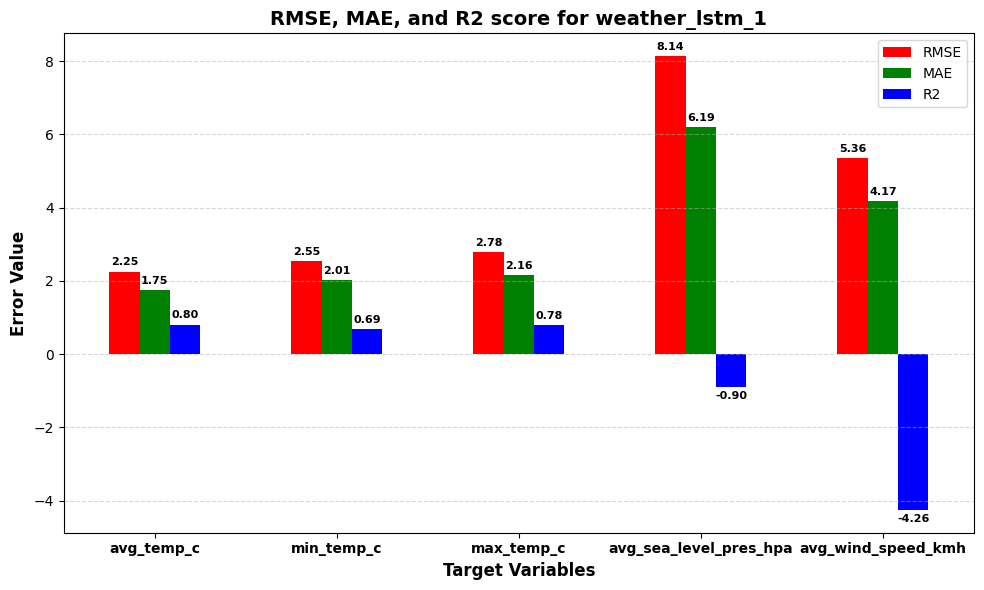

In [131]:
# Getting the metrics on predictions
# made by weather_lstm_2
city_weather_lstm_1_metrics = get_city_weather_lstm_metrics(
    weather_y_test_seq_original,
    weather_lstm_preds_1_original
)

city_weather_lstm_1_metrics_df = pd.DataFrame(city_weather_lstm_1_metrics)
plot_city_weather_model_metrics(
    city_weather_lstm_1_metrics_df,
    'weather_lstm_1'
)

In [108]:
def plot_lstm_loss_curves(lstm_history, model_name):
    """
    Plots the training and
    validation loss curves.
    """
    epochs = range(1, len(lstm_history.history['loss']) + 1)
    history = lstm_history.history
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history['loss'], 'r-', label='Training MSE')
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation MSE')
    plt.plot(epochs, history['mae'], 'g-', label='Training MAE')
    plt.plot(epochs, history['val_mae'], 'g--', label='Validation MAE')
    plt.plot(epochs, history['rmse'], 'b-',label='Training RMSE')
    plt.plot(epochs, history['val_rmse'], 'b--',label='Training RMSE')
    plt.xlabel('Epochs', fontweight='bold', fontsize=12)
    plt.ylabel('Metrics', fontweight='bold', fontsize=12)
    plt.title(f'{model_name} Loss Curves', fontweight='bold', fontsize=14)
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.savefig(f'{model_name}_loss_curves.png', dpi=500, bbox_inches='tight')
    plt.show()

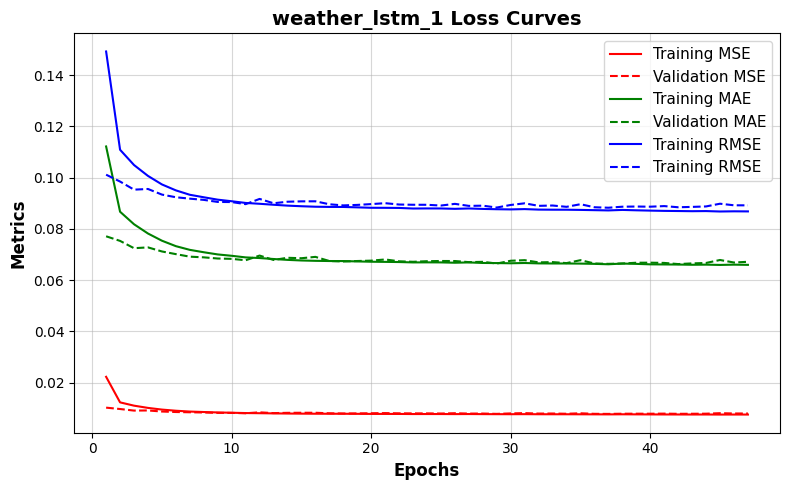

In [109]:
plot_lstm_loss_curves(weather_lstm_1_history, 'weather_lstm_1')

In [123]:
# Building a second LSTM for weather forecasting
weather_lstm_2 = Sequential([
    # Encoder
    Input((LOOKBACK, weather_X_train_seq.shape[2])),
    LSTM(
        64, return_sequences=True,
    ),
    Dropout(0.1),
    LSTM(
        32, return_sequences=False,
    ),
    Dropout(0.1),

    # Bridge
    RepeatVector(HORIZON),
    
    # Decoder
    LSTM(
        64, return_sequences=True,
    ),
    Dropout(0.2),
    LSTM(
        32, return_sequences=True,
    ),
    Dropout(0.2),
    
    TimeDistributed(Dense(
        weather_y_train_seq.shape[2]
    ))
])

weather_lstm_2.compile(
    optimizer=Adam(
        learning_rate=0.001,
        clipnorm=1.0
    ),
    loss='mean_squared_error',
    metrics=[
        'mae',
        RootMeanSquaredError(name='rmse')
    ]
)

weather_lstm_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 10, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 4, 64)          │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 4, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 4, 5)           │           165 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,053 (273.64 KB)

 Trainable params: 70,053 (273.64 KB)

 Non-trainable params: 0 (0.00 B)

In [124]:
# Fit weather_lstm_2
weather_lstm_2_history = weather_lstm_2.fit(
    weather_X_train_seq,
    weather_y_train_seq,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0577 - mae: 0.1797 - rmse: 0.2296 - val_loss: 0.0104 - val_mae: 0.0780 - val_rmse: 0.1022
Epoch 2/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0137 - mae: 0.0917 - rmse: 0.1171 - val_loss: 0.0104 - val_mae: 0.0777 - val_rmse: 0.1018
Epoch 3/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0121 - mae: 0.0859 - rmse: 0.1100 - val_loss: 0.0101 - val_mae: 0.0762 - val_rmse: 0.1005
Epoch 4/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0112 - mae: 0.0820 - rmse: 0.1056 - val_loss: 0.0104 - val_mae: 0.0776 - val_rmse: 0.1021
Epoch 5/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0105 - mae: 0.0792 - rmse: 0.1024 - val_loss: 0.0092 - val_mae: 0.0726 - val_rmse: 0.0958
Epoch 6/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0096 - mae: 0.0758 - rmse: 0.0982 - val_loss: 0.0086 - val_mae: 0.0700 - val_rmse: 0.0927
Epoch 7/50
493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0092 - mae: 0.0739

In [125]:
weather_lstm_preds_2_scaled = weather_lstm_2.predict(weather_X_test_seq)

n_samples, horizon, n_targets = weather_lstm_preds_2_scaled.shape
weather_lstm_preds_2_reshaped = weather_lstm_preds_2_scaled.reshape(-1, n_targets)

weather_lstm_preds_2_original = weather_y_scaler.inverse_transform(weather_lstm_preds_2_reshaped)

weather_lstm_preds_2_final = weather_lstm_preds_2_original.reshape(n_samples, horizon, n_targets)

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


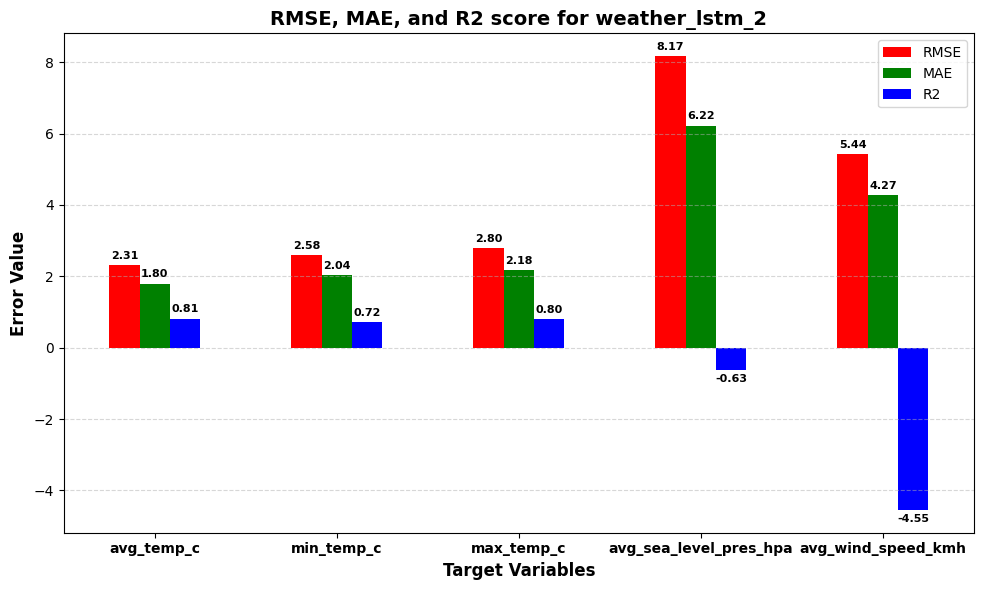

In [132]:
# Getting the metrics on predictions
# made by weather_lstm_2
city_weather_lstm_2_metrics = get_city_weather_lstm_metrics(
    weather_y_test_seq_original,
    weather_lstm_preds_2_original
)

city_weather_lstm_2_metrics_df = pd.DataFrame(city_weather_lstm_2_metrics)
plot_city_weather_model_metrics(
    city_weather_lstm_2_metrics_df,
    'weather_lstm_2'
)

---

Across all evaluation metrics (RMSE, MAE, and R2 score), XGBoost has the best performance for forecasting 1 timestep (1 day) ahead (R2 score = **0.52**, average RMSE = **2.97**), whereas the LSTMs gave mixed results across their 4-day forecast horizon. For temperature variables (`avg_temp_c`, `min_temp_c`, `max_temp_c`), both LSTMs maintained good forecasting capabilities (R2 score = **0.69-0.81**, MAE = **1.75-2.18**). However, for targets like pressure and wind speed, severe performance drops (negative R2 scores). Between LSTMs, `weather_lstm_1` yielded lower absolute errors (MAE = **3.25**) than `weather_lstm_2` (MAE = **3.30**) alongside being a lighter model.

**Therefore, LSTMs are selected as the primary family of predictors for 4-day weather forecasting, with strong reliability on temperature predictions and significant limitations on wind and pressure predictions.**

---

In [179]:
# Exporting datasets, preprocessors, and models
import os
import joblib

os.makedirs('time_series_forecasting_artifacts', exist_ok=True)

# ======== For energy forecasting ========

# XGBRegressors
joblib.dump(
    load_xgbr_1,
    'time_series_forecasting_artifacts/load_xgbr_1.pkl'
)
joblib.dump(
    gen_xgbr_grid_search.best_estimator_,
    'time_series_forecasting_artifacts/gen_xgbr_2.pkl'
)

# DataFrames
X_load_train.to_csv(
    'time_series_forecasting_artifacts/X_load_train.csv',
    index=False
)
y_load_train.to_csv(
    'time_series_forecasting_artifacts/y_load_train.csv',
    index=False
)
X_load_test.to_csv(
    'time_series_forecasting_artifacts/X_load_test.csv',
    index=False
)
y_load_test.to_csv(
    'time_series_forecasting_artifacts/y_load_test.csv',
    index=False
)

X_gen_train.to_csv(
    'time_series_forecasting_artifacts/X_gen_train.csv',
    index=False
)
y_gen_train.to_csv(
    'time_series_forecasting_artifacts/y_gen_train.csv',
    index=False
)
X_gen_test.to_csv(
    'time_series_forecasting_artifacts/X_gen_test.csv',
    index=False
)
y_gen_test.to_csv(
    'time_series_forecasting_artifacts/y_gen_test.csv',
    index=False
)

In [181]:
# ======== For energy forecasting ========

# LSTMs
weather_lstm_1.save(
    'time_series_forecasting_artifacts/london_weather_lstm_1.keras'
)
weather_lstm_2.save(
    'time_series_forecasting_artifacts/london_weather_lstm_2.keras'
)

# Scalers
joblib.dump(
    weather_X_scaler,
    'time_series_forecasting_artifacts/london_weather_X_scaler.pkl'
)
joblib.dump(
    weather_y_scaler,
    'time_series_forecasting_artifacts/london_weather_y_scaler.pkl'
)

# NumPy arrays
np.save(
    'time_series_forecasting_artifacts/london_weather_X_train_seq',
    weather_X_train_seq
)
np.save(
    'time_series_forecasting_artifacts/london_weather_y_train_seq',
    weather_y_train_seq
)
np.save(
    'time_series_forecasting_artifacts/london_weather_X_test_seq',
    weather_X_test_seq
)
np.save(
    'time_series_forecasting_artifacts/london_weather_y_test_seq',
    weather_y_test_seq
)